In [1]:
import numpy as np
import math
import json
import time
from IPython.display import HTML
from line_profiler import LineProfiler

from ipynb.fs.full.forcemodel import IForceModel, GravityForce
from ipynb.fs.full.integrator import IIntegrator, SymplecticEuler, VelocityVerlet
from ipynb.fs.full.env import SolarSystemEnv, run_simulation, run_script_simulation, adjust_barycentric
from ipynb.fs.full.vis import visualize_trajectories, plot_static_trajectories
from ipynb.fs.full.helpers import save_states, load_states
from ipynb.fs.full.ship import SimpleImpulseShip, Maneuver, simple_action_space
from ipynb.fs.full.rlmontecarlo import train_mc, MonteCarloAgent, PolicyNet, compute_returns

In [2]:
#%load_ext line_profiler

Cool but unstable with really massive suns
bodies = [
    # Masses (kg)
    np.array([
        1.0e31,
        1.0e31,
        1.0e31,
    ]),
    # Positions (x, y) in meters
    np.array([
        [0.97e11, -0.243e11],   
        [-0.97e11, 0.243e11],
        [0.0, 0.0], 
    ]),
    # Velocities (vx, vy) in m/s
    np.array([
        [0.466e5, 0.432e5],    
        [0.466e5, 0.432e5],
        [-0.932e5, -0.864e5], 
    ]),
    # Names
    np.array([
        "One",
        "Two",
        "Three",
    ]),
    # Colors (reasonable defaults for visualization)
    np.array([
        "red",        
        "blue",
        "green",
    ]),
]

In [3]:
# This precompiles simulation for njit
bodies = [
    # Masses (kg)
    np.array([
        1.5e10,
        1.5e10
    ]),
    # Positions (x, y) in meters (approx semi-major axes on x-axis)
    np.array([
        [0.97, -0.243],
        [-0.97, 0.243]
    ]),
    # Velocities (vx, vy) in m/s (circular orbit approximation)
    np.array([
        [0.466, 0.432],
        [0.466, 0.432]
    ]),
    # Names
    np.array([
        "One",
        "Two"
    ]),
    # Colors (reasonable defaults for visualization)
    np.array([
        "red",
        "blue"
    ]),
]
dt=0.0001
n_steps=1000
states = run_simulation(GravityForce, VelocityVerlet, bodies, dt=dt, n_steps=n_steps, records_len=500)

# Monte Carlo RL with NN-Q Table #

In [4]:
bodies = [
    # Masses
    np.array([
        5.972e24,       # Earth
        7.342e22,       # Luna
        1.0e5,          # Ship
    ]),
    # Positions (x, y) in meters
    np.array([
        [0.0, 0.0],                # Earth
        [3.844e8, 0.0],      # Luna
        [3.6e7, 0.0],        # Ship
    ]),
    # Velocities (vx, vy) in m/s
    np.array([
        [0.0, 0.0],                   # Earth
        [0.0, 1022.0],          # Luna
        [0.0, 3055.0],         # Ship
    ]),
    # Names of celestial bodies
    np.array([
        "Earth",
        "Moon",
        "Ship"
    ]),
    # Colors for visuals
    np.array([
        "blue",       # Earth
        "gray",       # Moon (Luna)
        "lightblue",  # Ship
    ]),
]

In [5]:
bodies = [
    # Masses
    np.array([
        5.972e24,       # Earth
        1.0e5,          # Ship
    ]),
    # Positions (x, y) in meters
    np.array([
        [0.0, 0.0],                # Earth
        [2e6, 0.0],        # Ship
    ]),
    # Velocities (vx, vy) in m/s
    np.array([
        [0.0, 0.0],                   # Earth
        [0.0, 14000.0],         # Ship
    ]),
    # Names of celestial bodies
    np.array([
        "Earth",
        "Ship"
    ]),
    # Colors for visuals
    np.array([
        "blue",       # Earth
        "lightblue",  # Ship
    ]),
]

ship_index = len(bodies[0])-1
mass = bodies[0][-1]

actions = simple_action_space 
safety_radius = 1e4 # on a space scale 10 km is defenitely an atmo entry
escape_dist = 1e8
#escape_dist = 6e8   
escape_vel = 4e5 
#target_dist = 1e5 # for a low lunar orbit
#target_vel = 1700 # for a low lunar orbit
target_dist = 4e6 
#target_dist = 3.6e7 # for a Far Earth orbit
target_vel = 3055.0 # for a Far Earth orbit
reference_point_index = 0

n_actions = actions.n
n_episodes=1000

dt=0.1
simulation_time = 3600 * 1 * 1
max_steps= int(simulation_time/dt)

reward_coef = 1.0 / max_steps

thrust = 1e6/dt # thrust changes with dt so keep that in mind

Failure: Ship crashed
Episode   10 | Return:  1.738e+00 | Loss:  4.001e+01


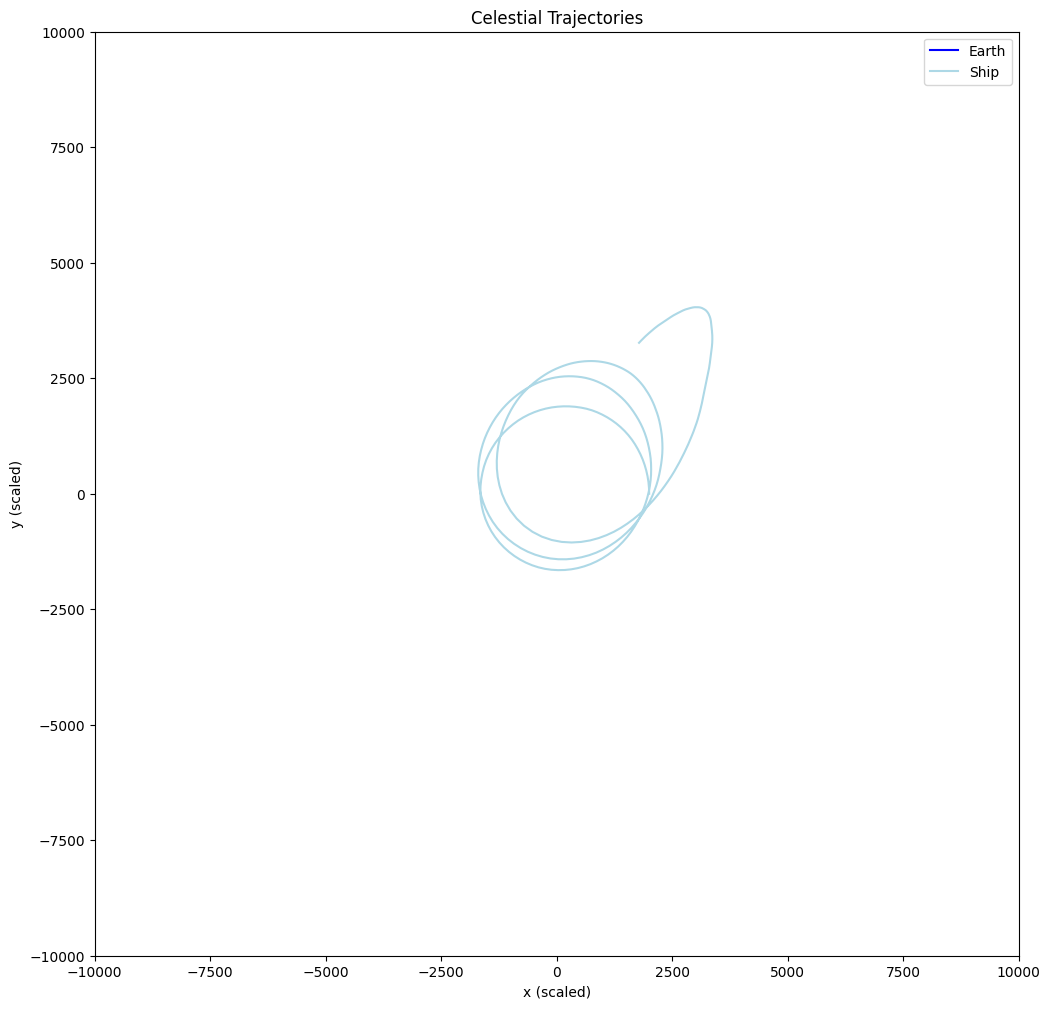

Failure: Ship escaped the system or exceeded system escape velocity
Episode   20 | Return: -1.686e+00 | Loss:  3.916e+01


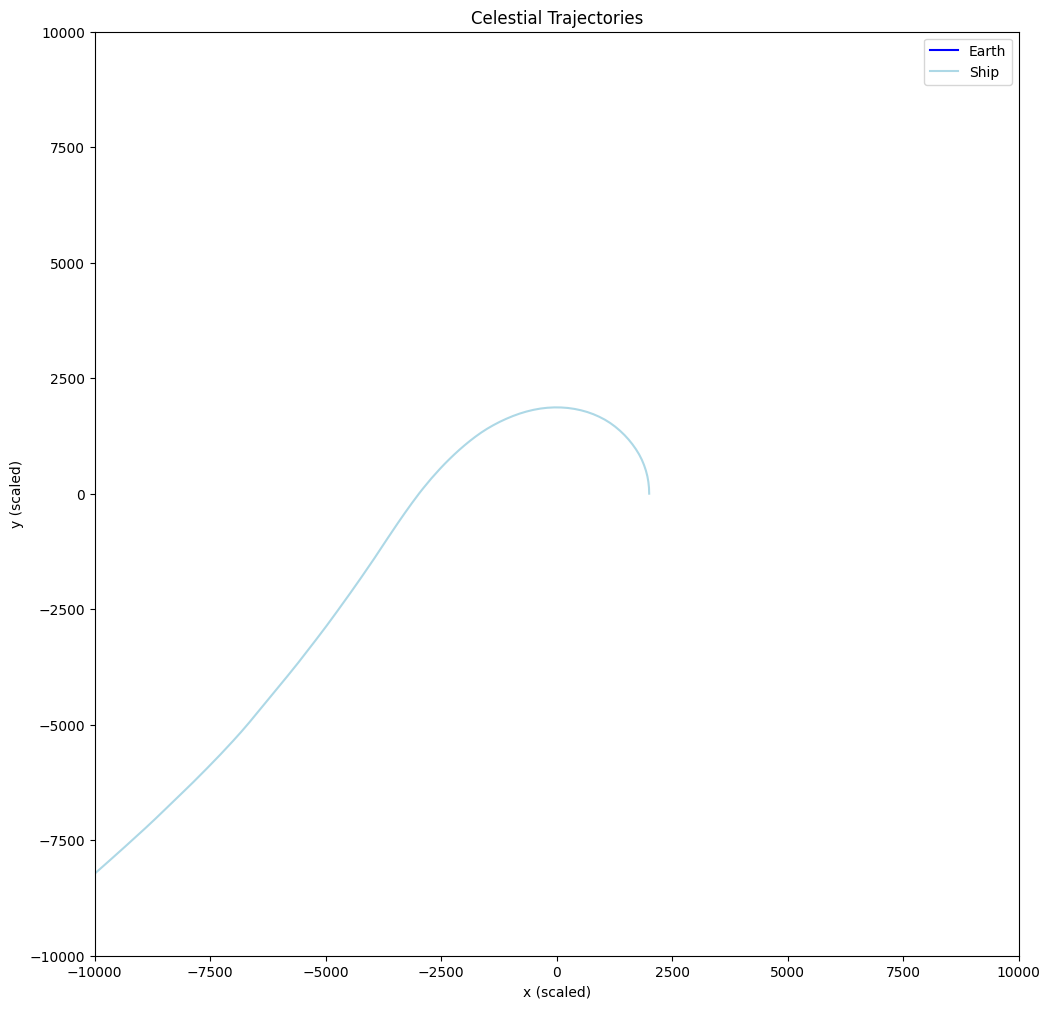

Failure: Ship escaped the system or exceeded system escape velocity
Failure: Ship escaped the system or exceeded system escape velocity
Failure: Ship escaped the system or exceeded system escape velocity
Failure: Ship escaped the system or exceeded system escape velocity
Failure: Ship escaped the system or exceeded system escape velocity
Failure: Ship escaped the system or exceeded system escape velocity
Failure: Ship escaped the system or exceeded system escape velocity
Failure: Ship escaped the system or exceeded system escape velocity
Failure: Ship escaped the system or exceeded system escape velocity
Failure: Ship escaped the system or exceeded system escape velocity
Episode   30 | Return: -1.691e+00 | Loss:  1.029e+01


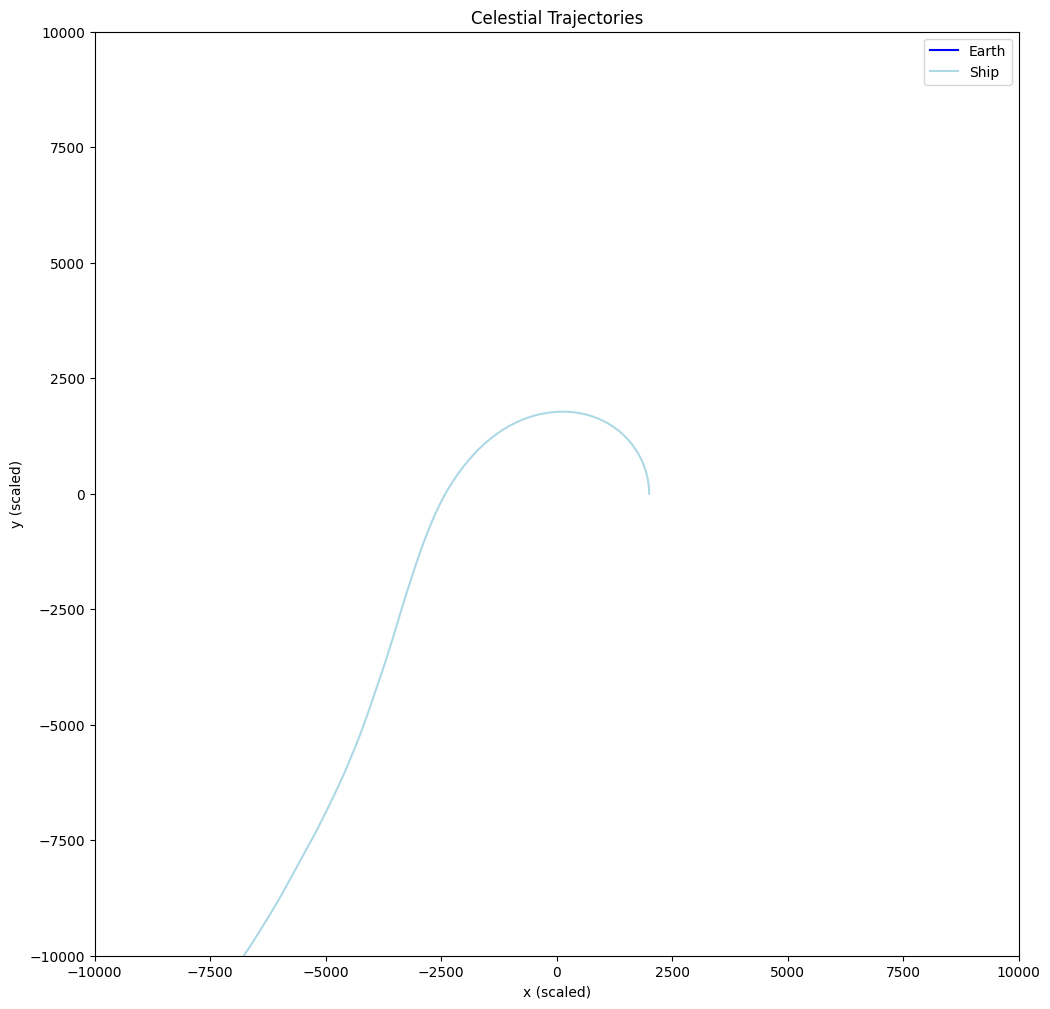

Failure: Ship escaped the system or exceeded system escape velocity
Episode   40 | Return:  3.708e-01 | Loss: -1.101e+02


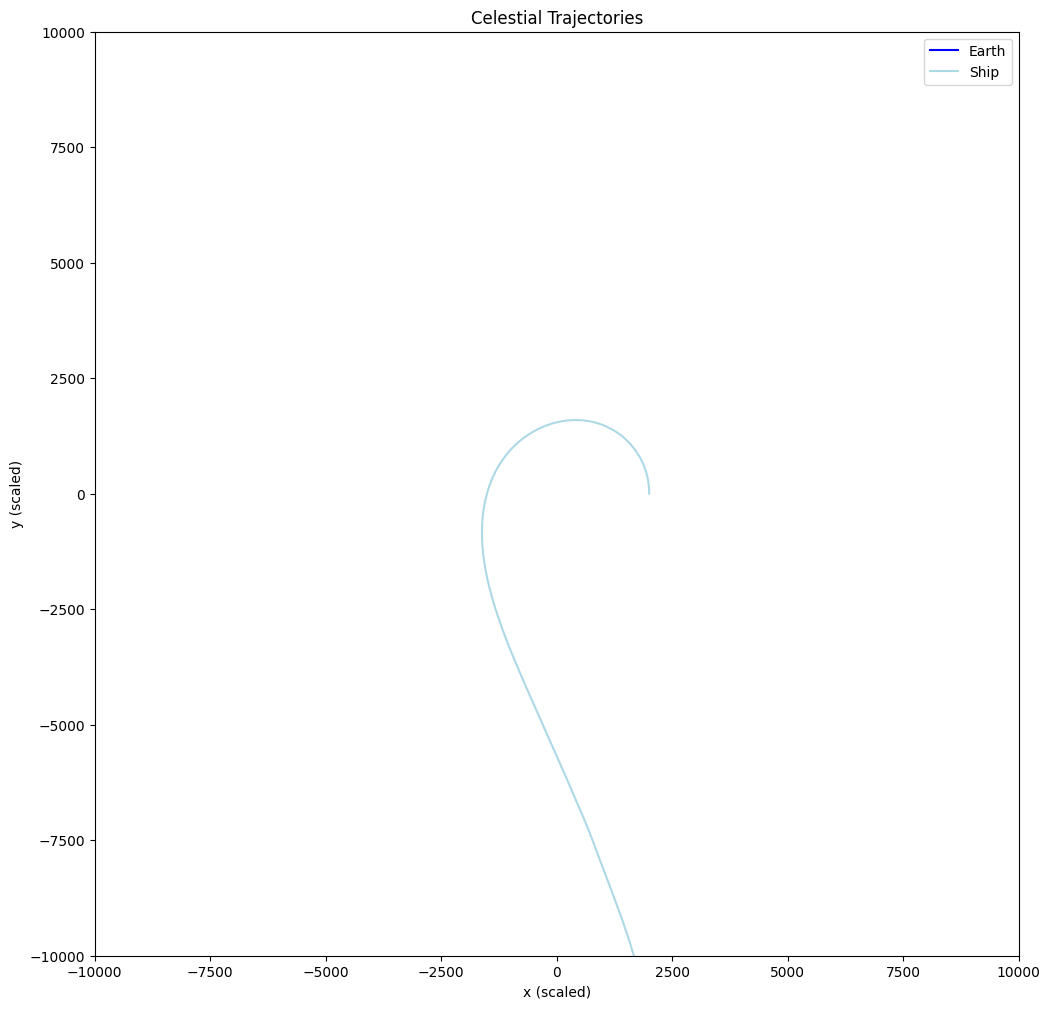

Failure: Ship escaped the system or exceeded system escape velocity
Episode   50 | Return:  3.846e-01 | Loss:  5.701e-01


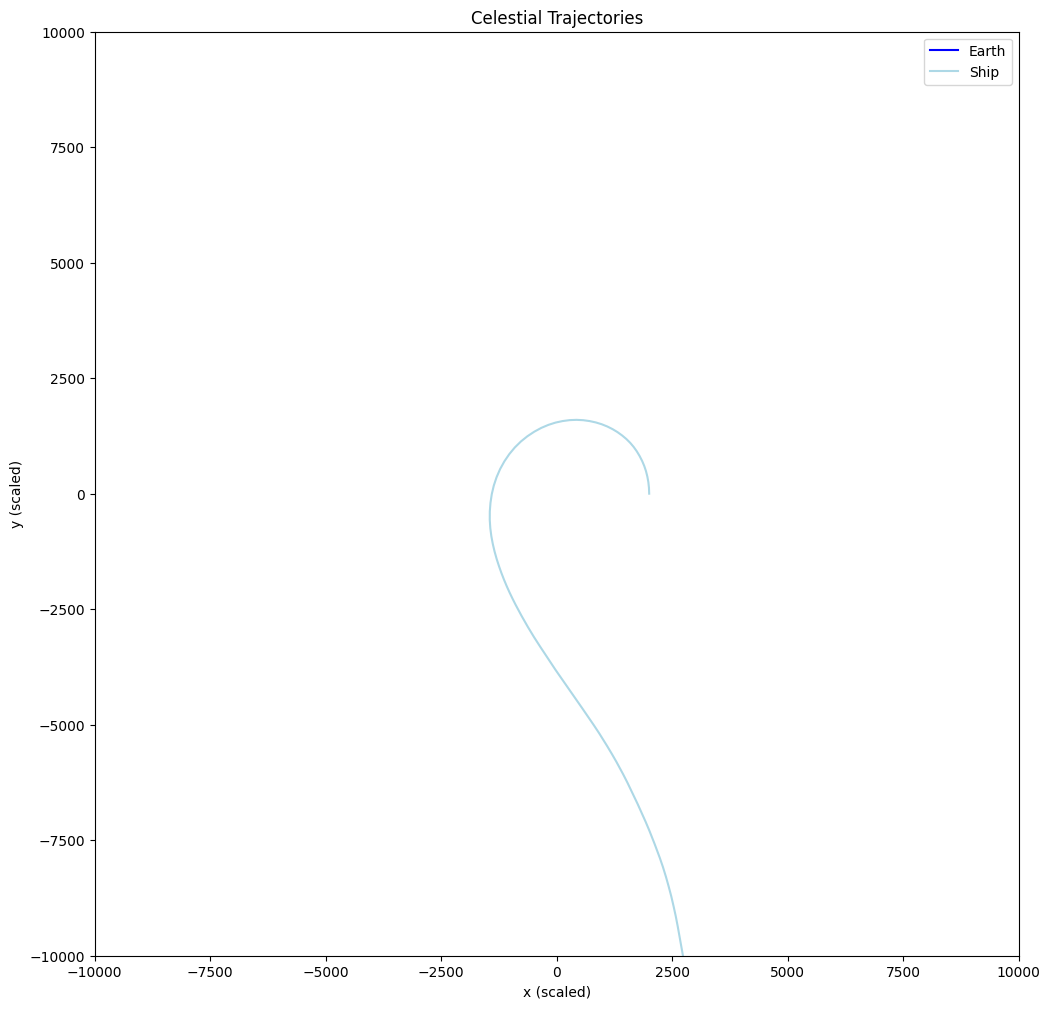

Failure: Ship escaped the system or exceeded system escape velocity
Episode   60 | Return:  4.154e-01 | Loss: -2.919e+01


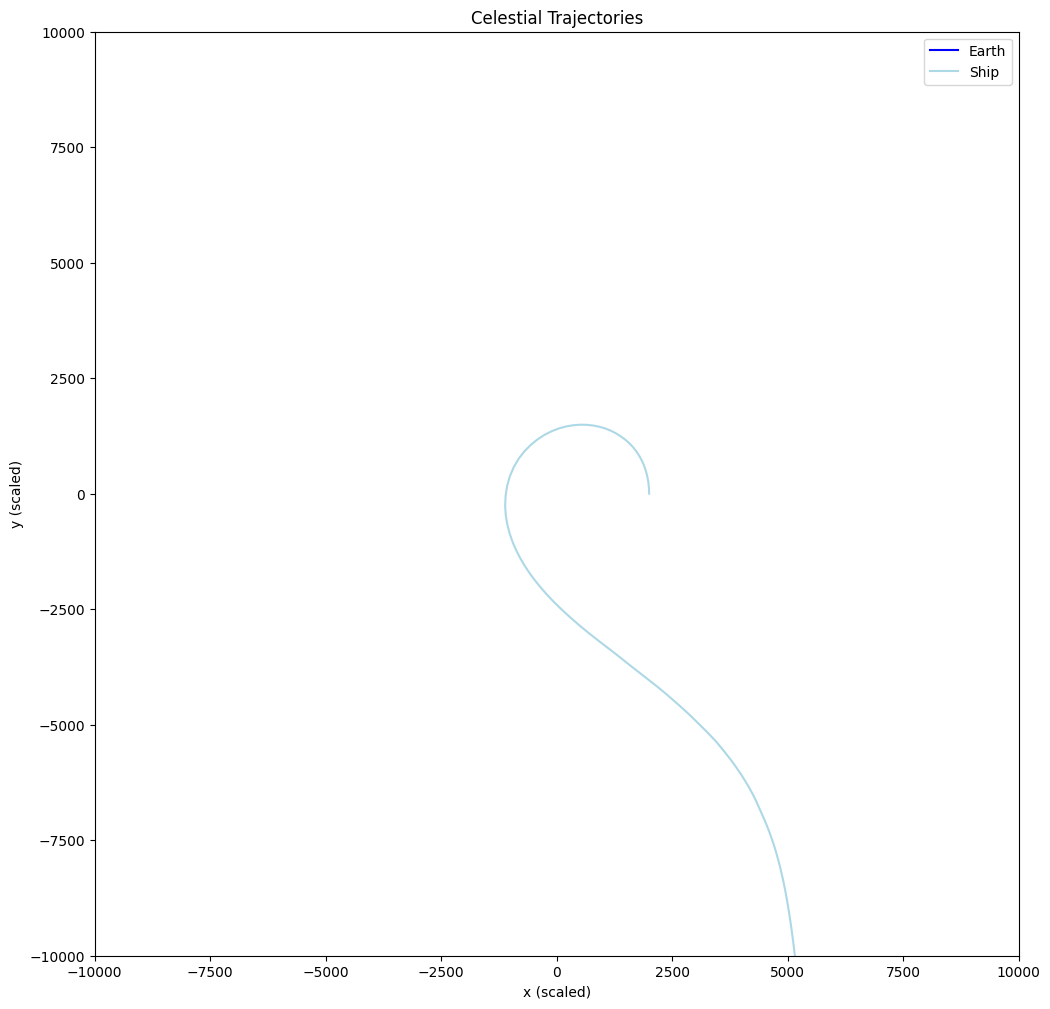

Episode   70 | Return:  7.301e-01 | Loss: -1.022e+02


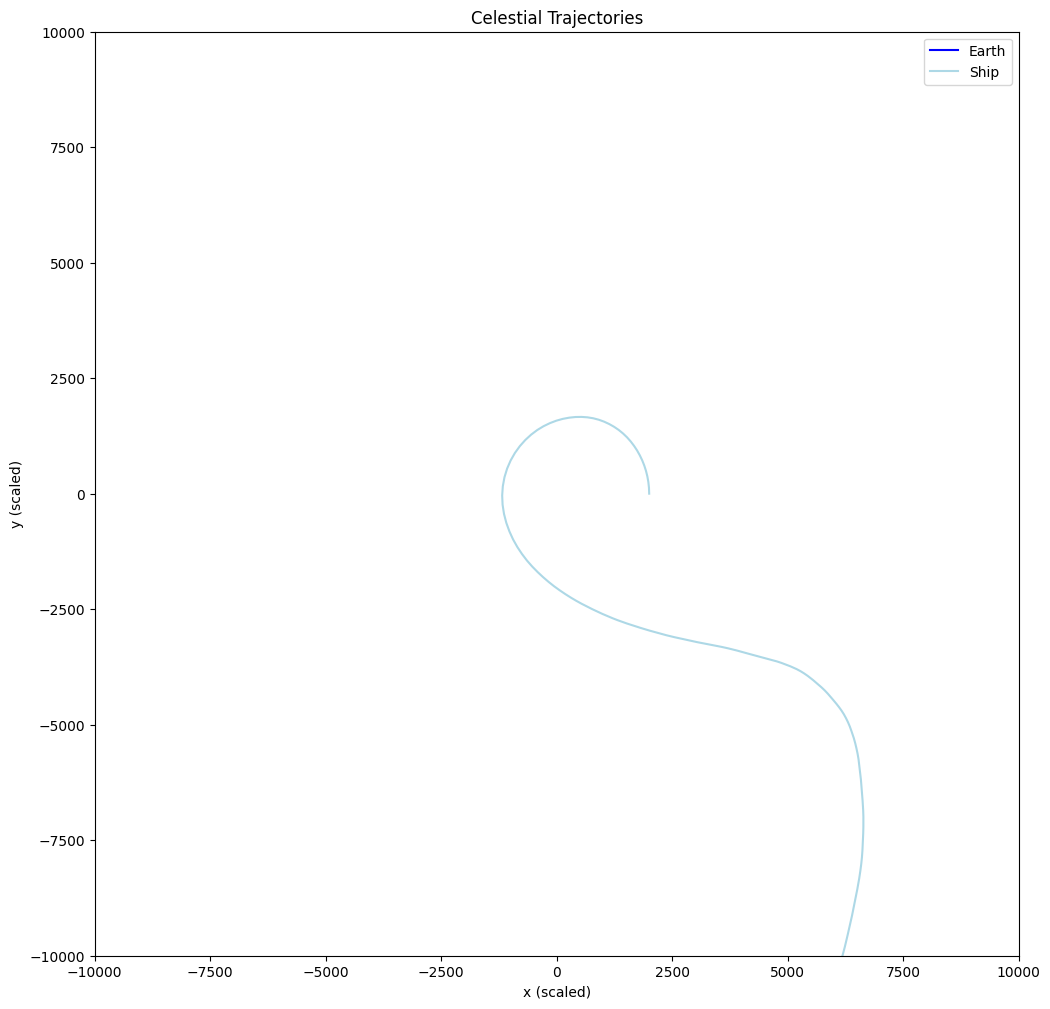

Failure: Ship crashed
Failure: Ship crashed
Episode   80 | Return:  9.574e-01 | Loss: -6.254e+00


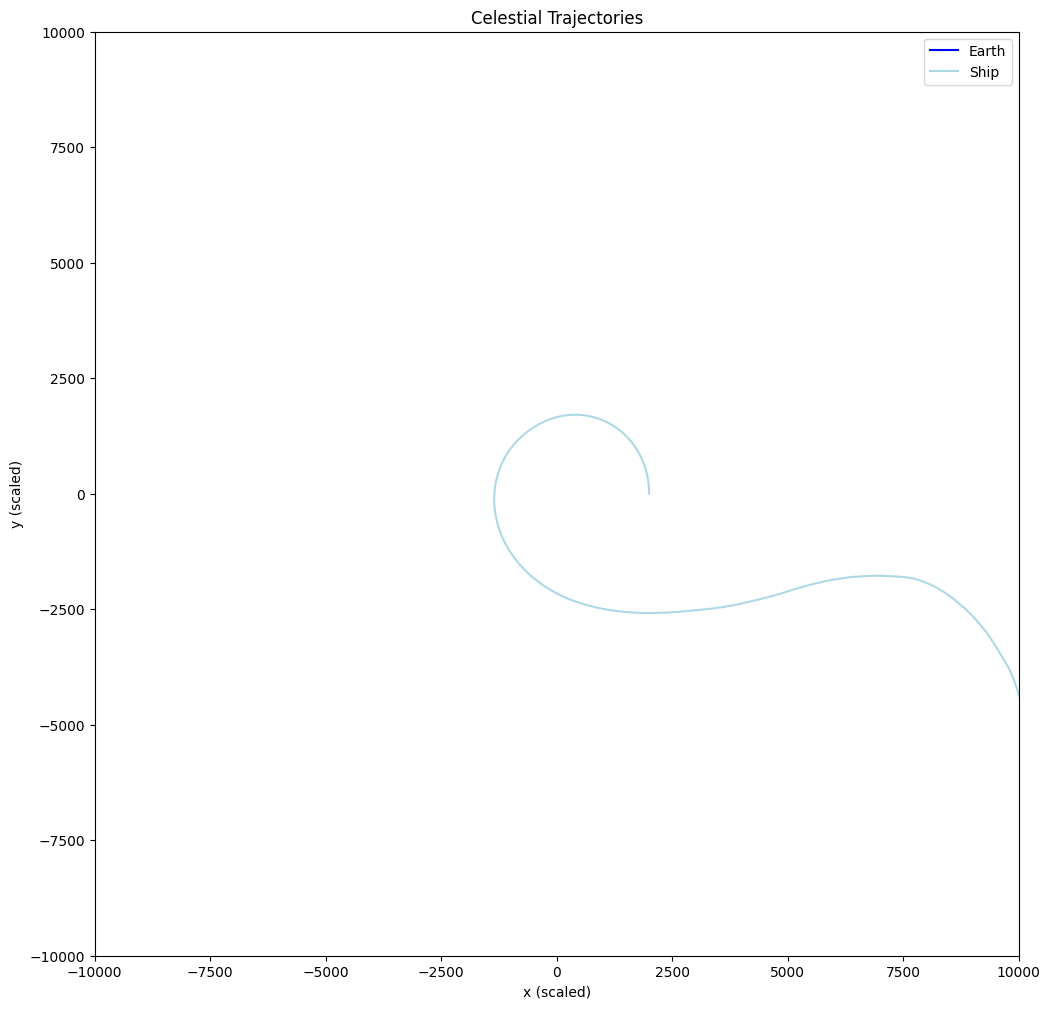

Success: Ship reached the target
Episode   90 | Return:  1.057e+01 | Loss:  2.965e+01


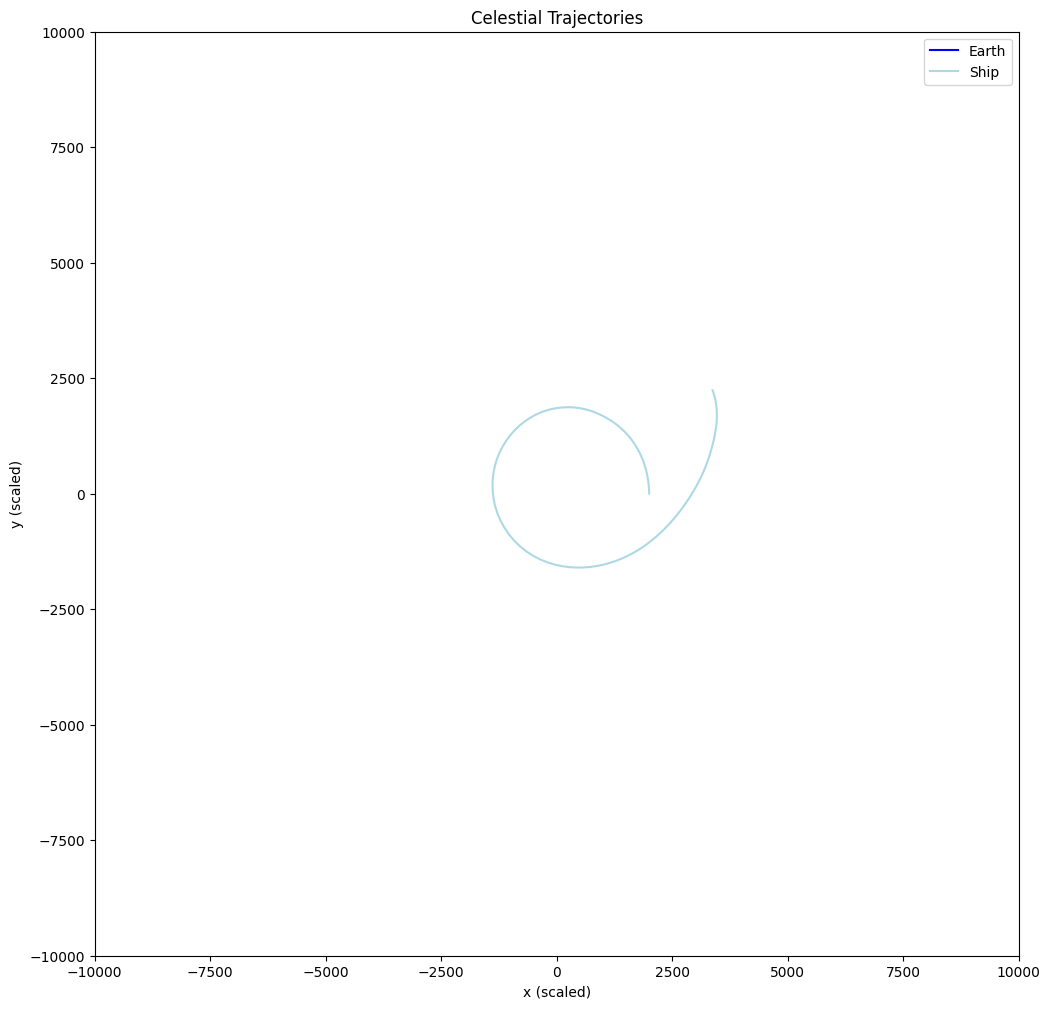

Episode  100 | Return:  1.302e+00 | Loss:  3.558e+01


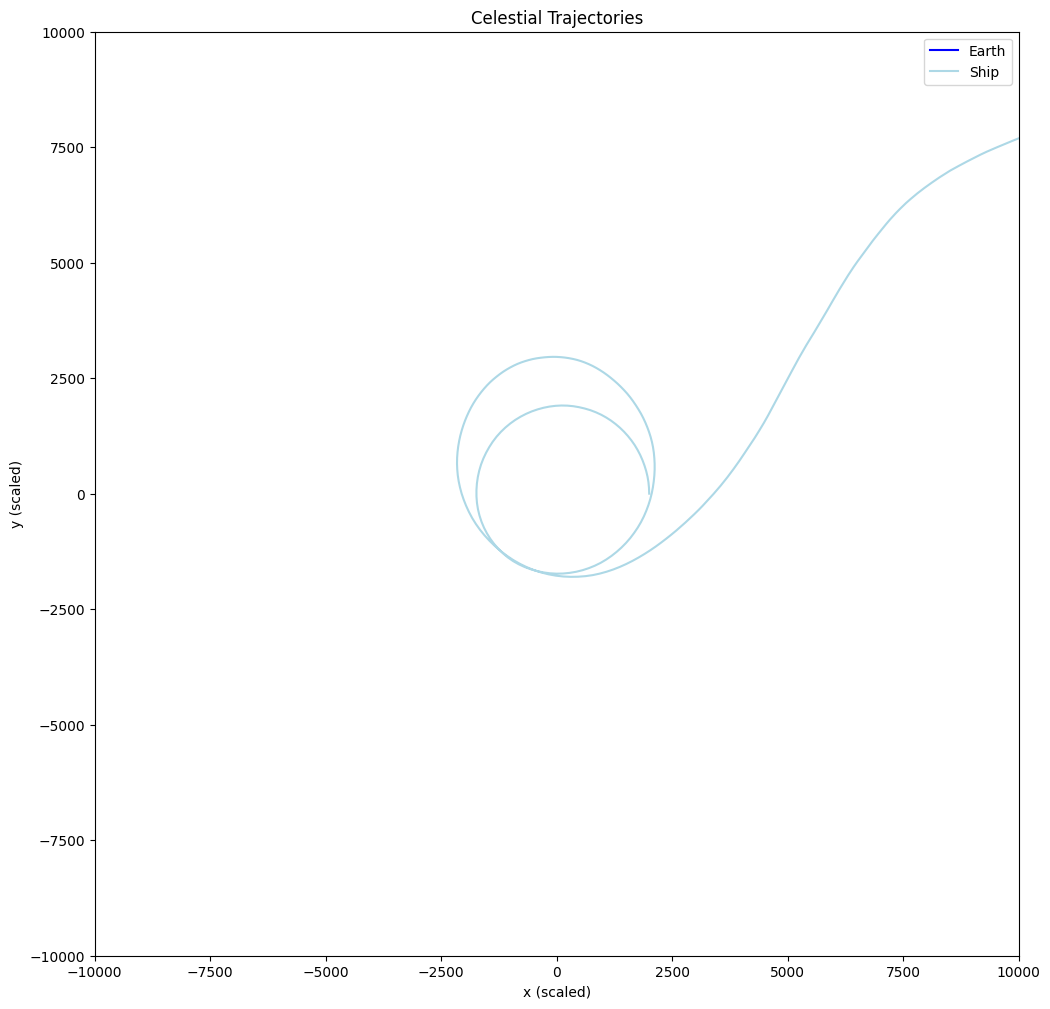

Episode  110 | Return:  1.251e+00 | Loss: -5.607e+00


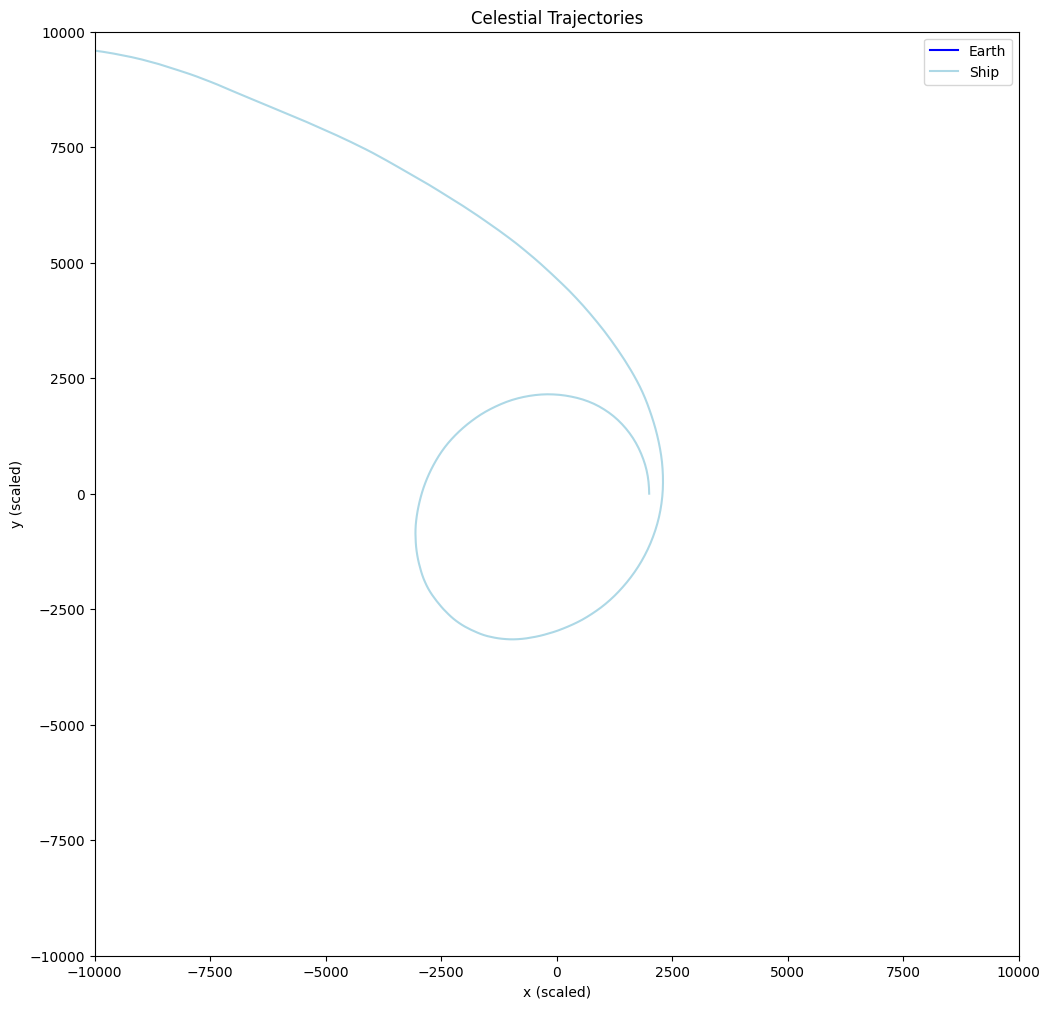

Episode  120 | Return:  1.224e+00 | Loss: -4.377e+01


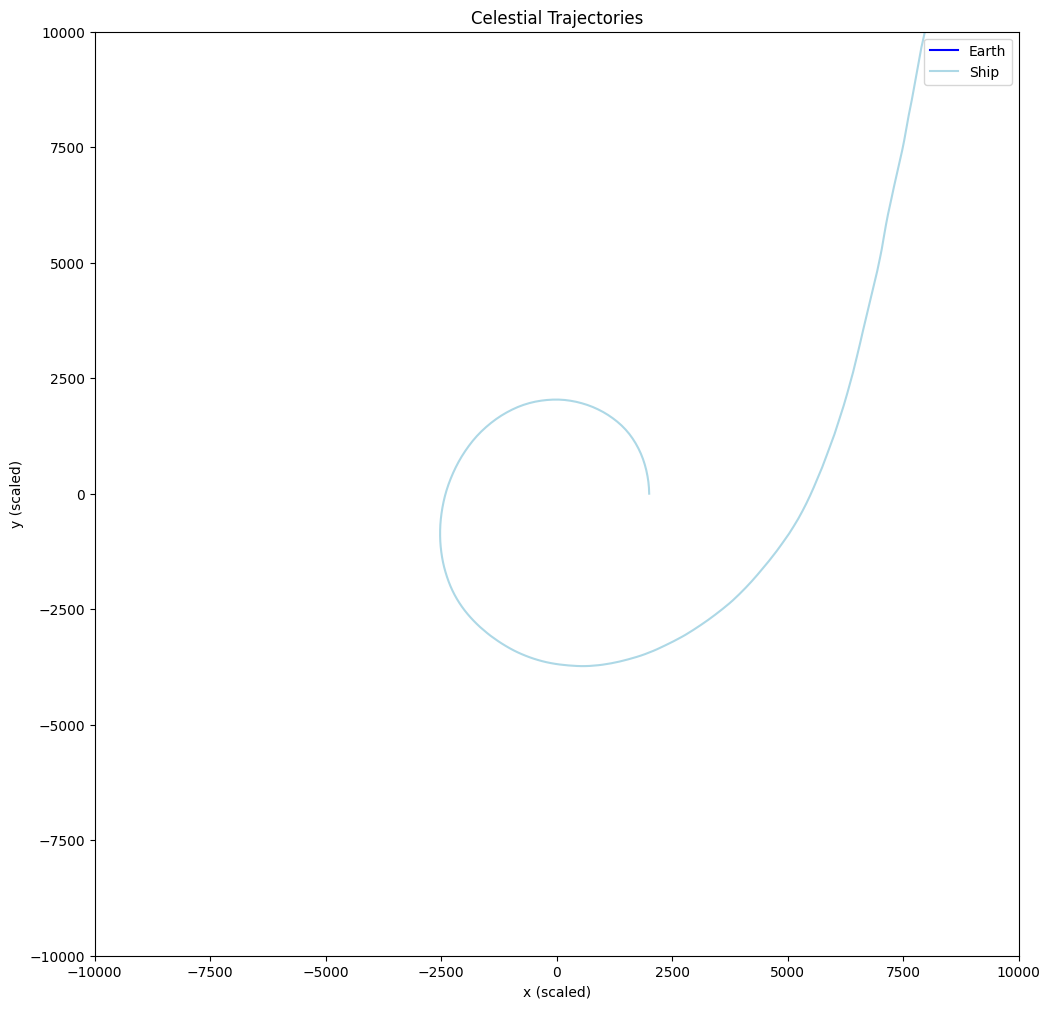

Episode  130 | Return:  5.542e-01 | Loss:  3.824e+00


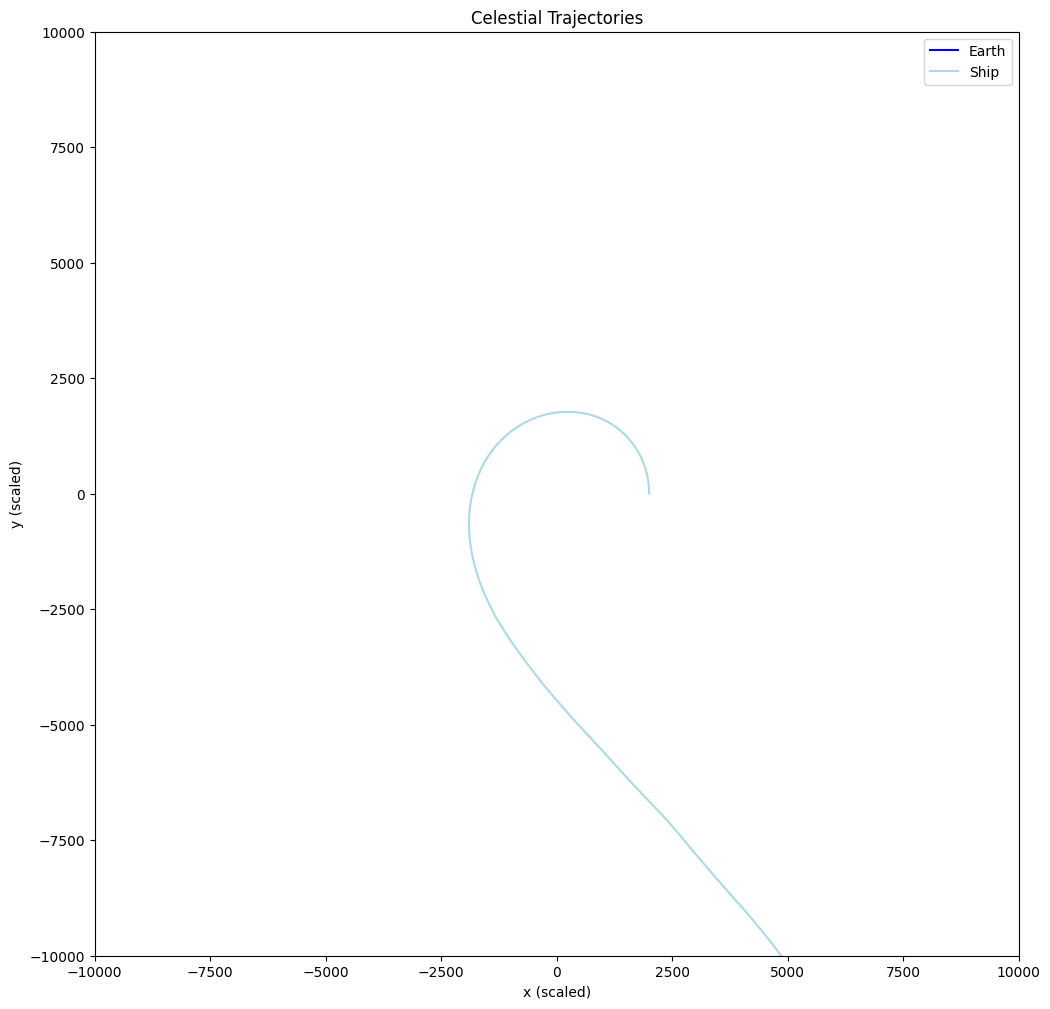

Episode  140 | Return:  6.314e-01 | Loss:  1.291e+01


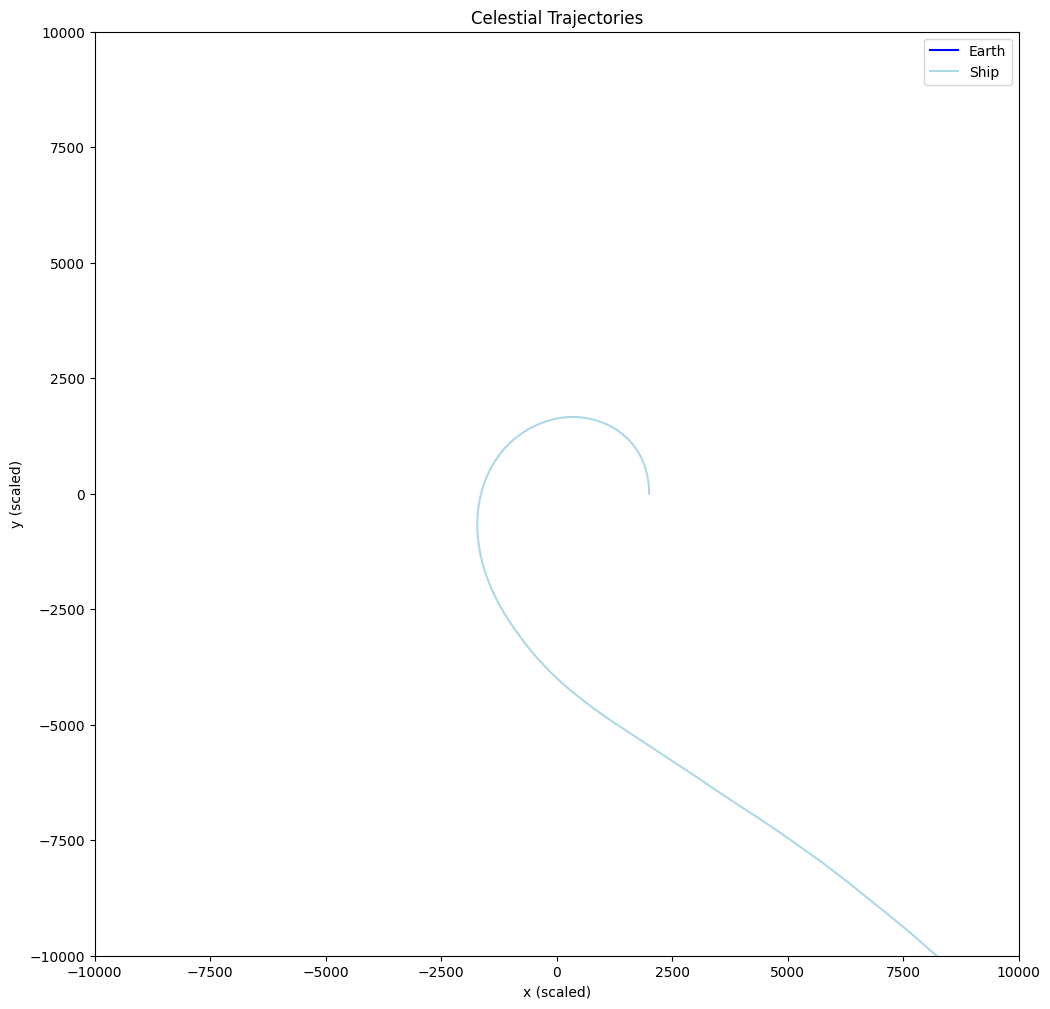

Episode  150 | Return:  5.891e-01 | Loss:  5.925e+01


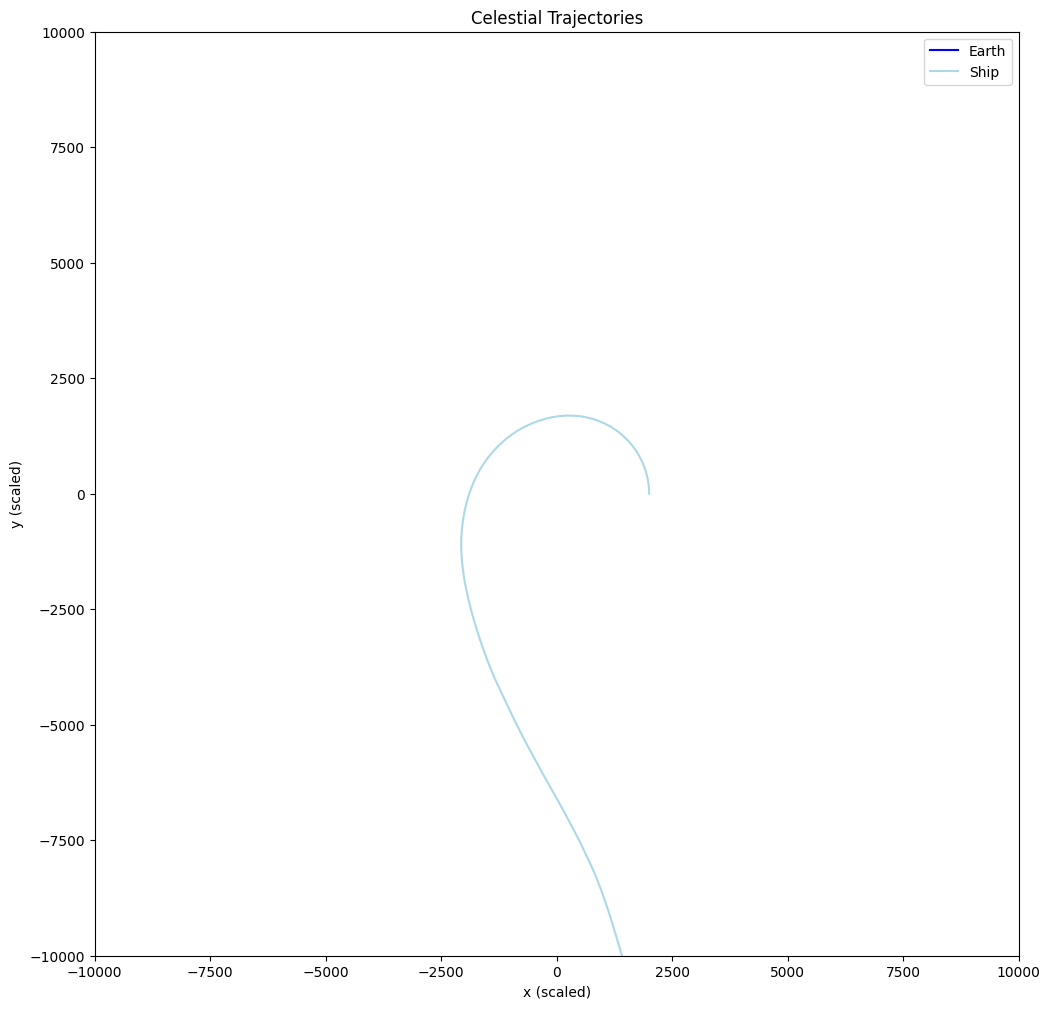

Episode  160 | Return:  4.494e-01 | Loss:  9.638e+01


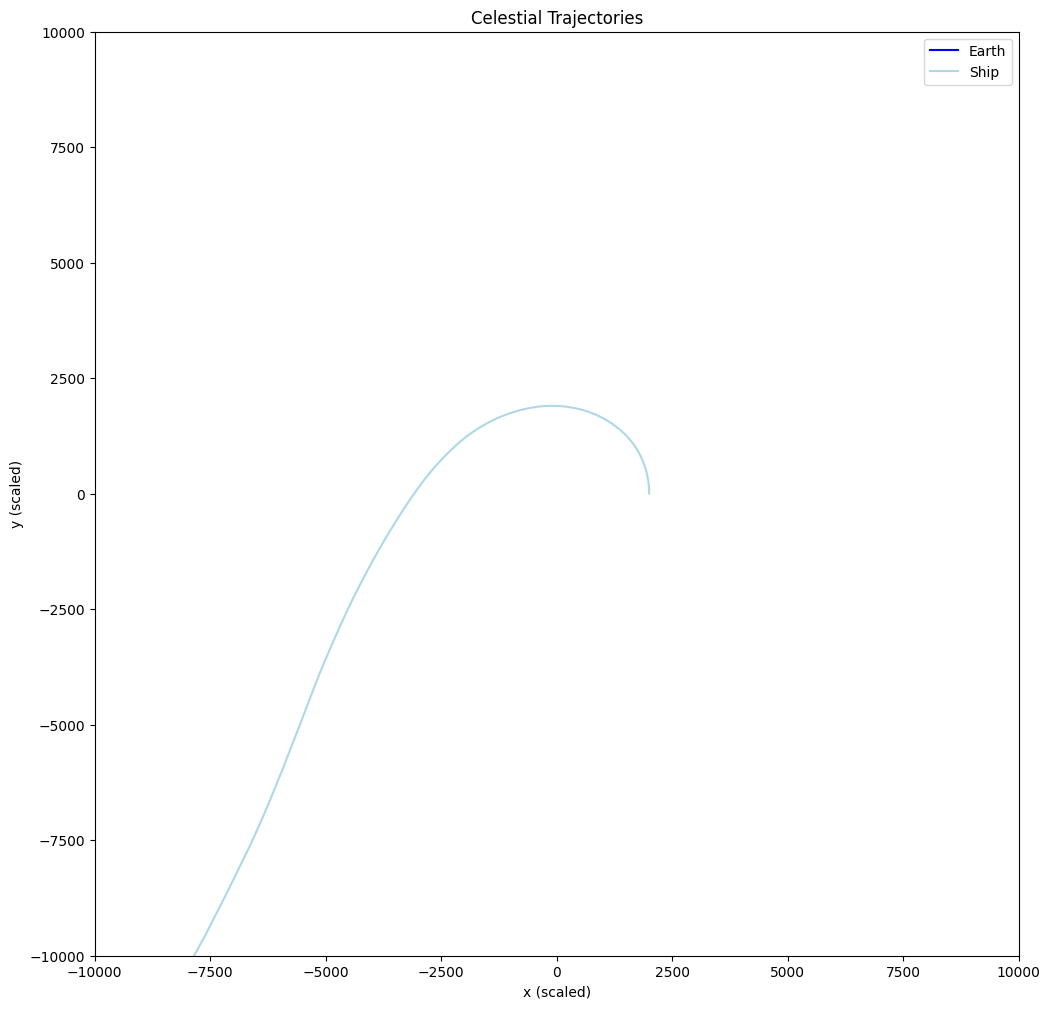

Failure: Ship crashed
Episode  170 | Return:  5.629e-01 | Loss:  1.214e+02


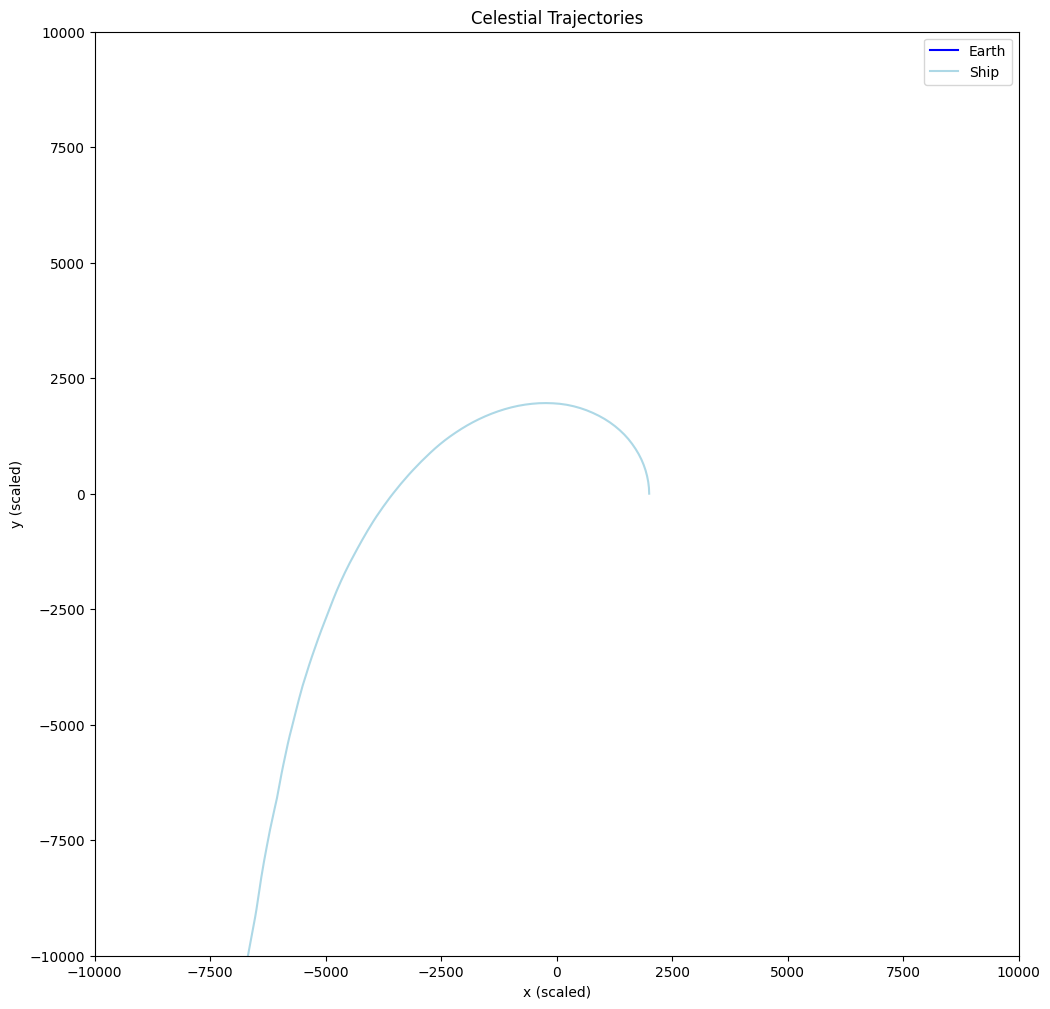

Episode  180 | Return:  1.810e+00 | Loss:  3.896e+02


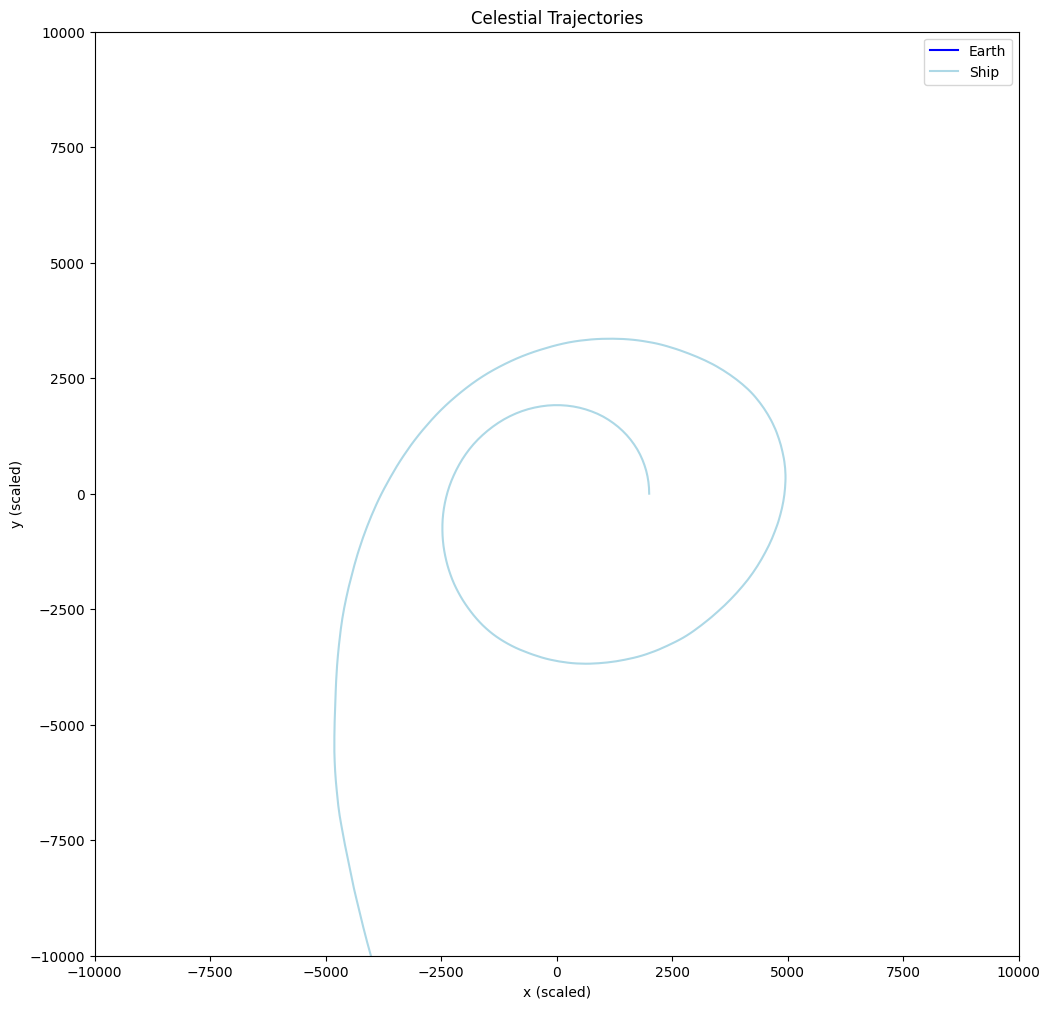

Episode  190 | Return:  1.549e+00 | Loss: -7.300e+01


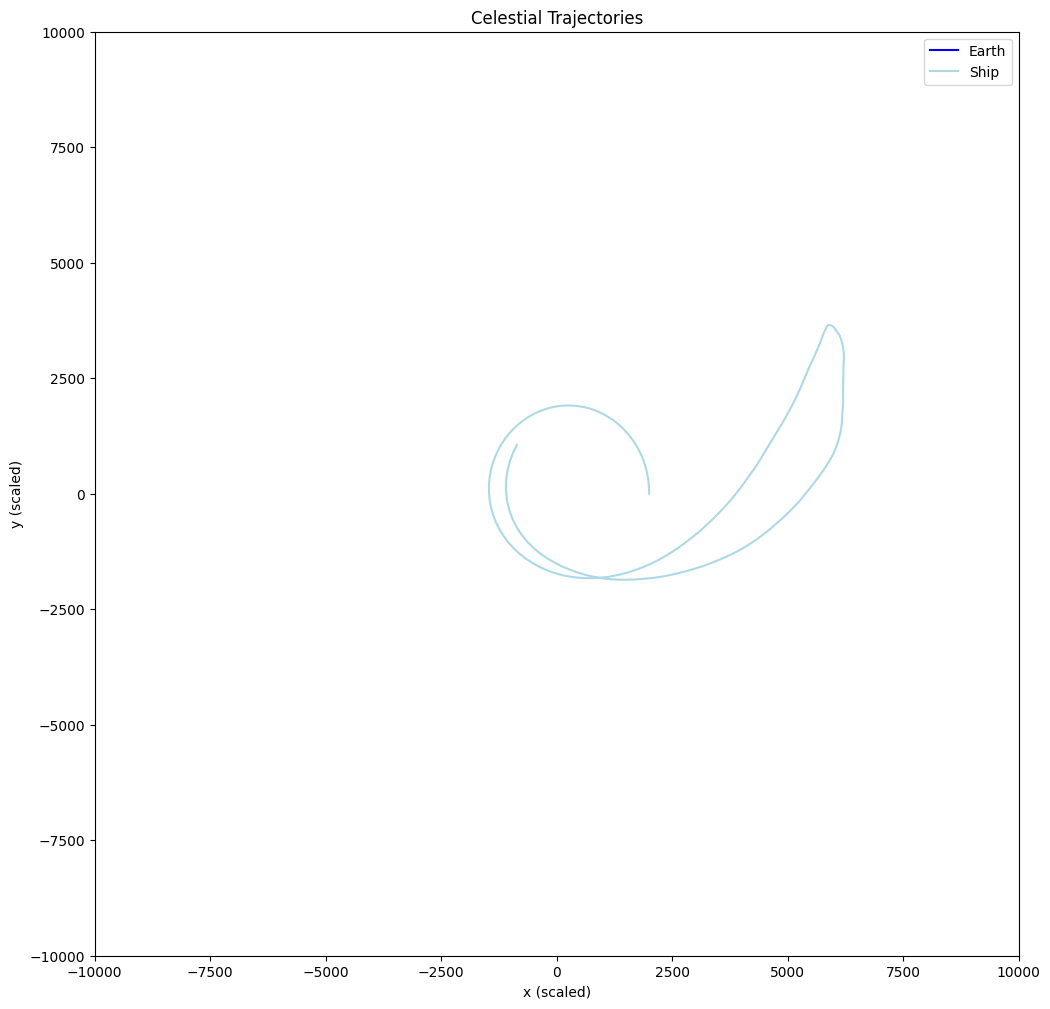

Failure: Ship escaped the system or exceeded system escape velocity
Episode  200 | Return:  1.528e+00 | Loss:  4.677e+01


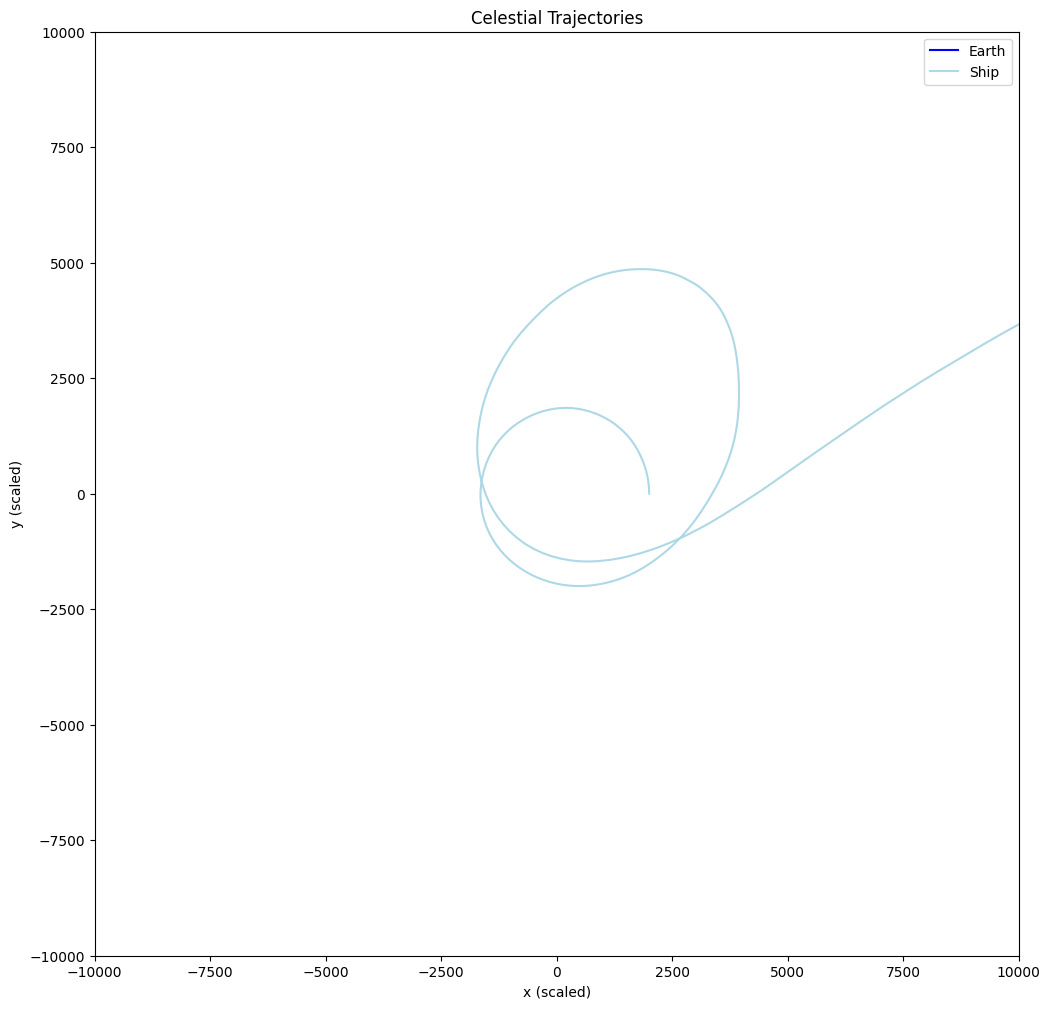

Episode  210 | Return:  1.260e+00 | Loss:  2.189e+01


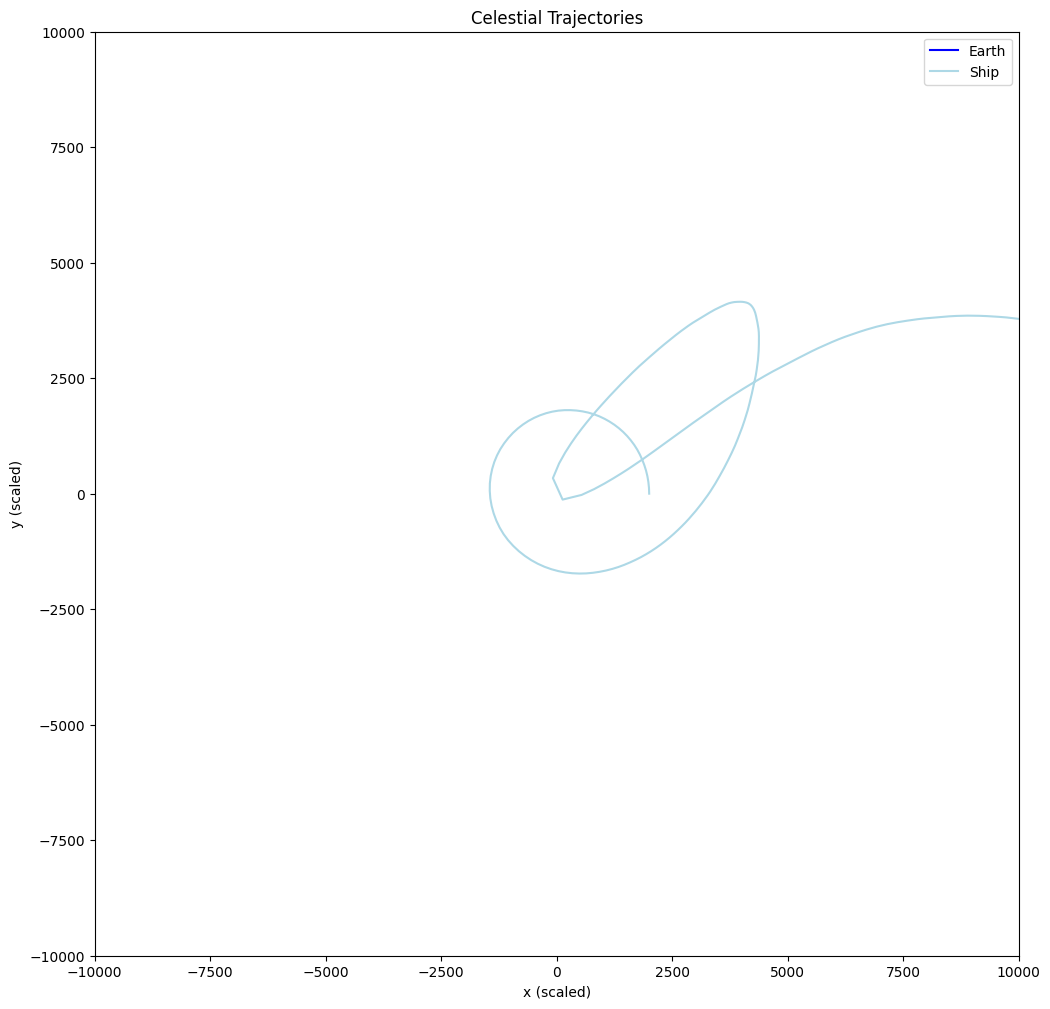

Episode  220 | Return:  1.114e+00 | Loss:  8.541e+01


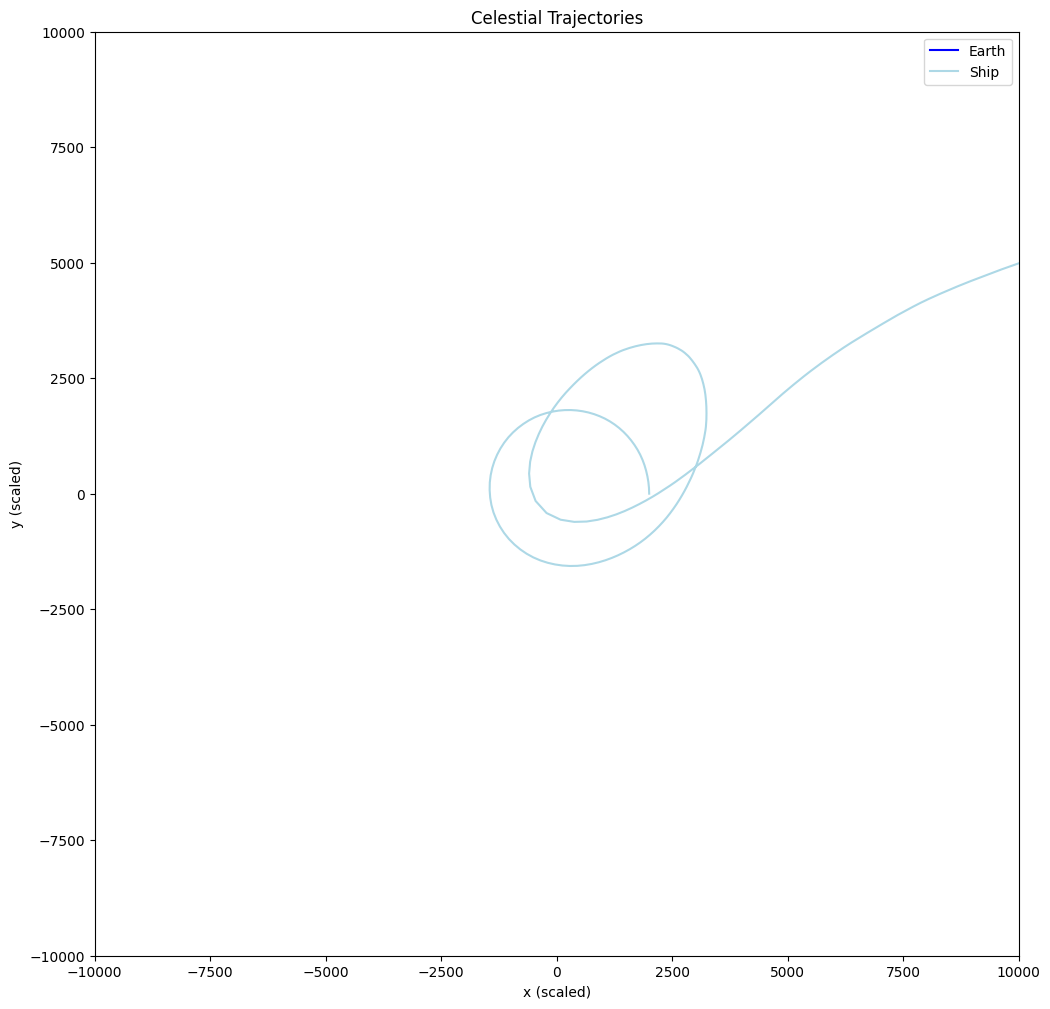

Episode  230 | Return:  6.476e-01 | Loss:  6.929e+01


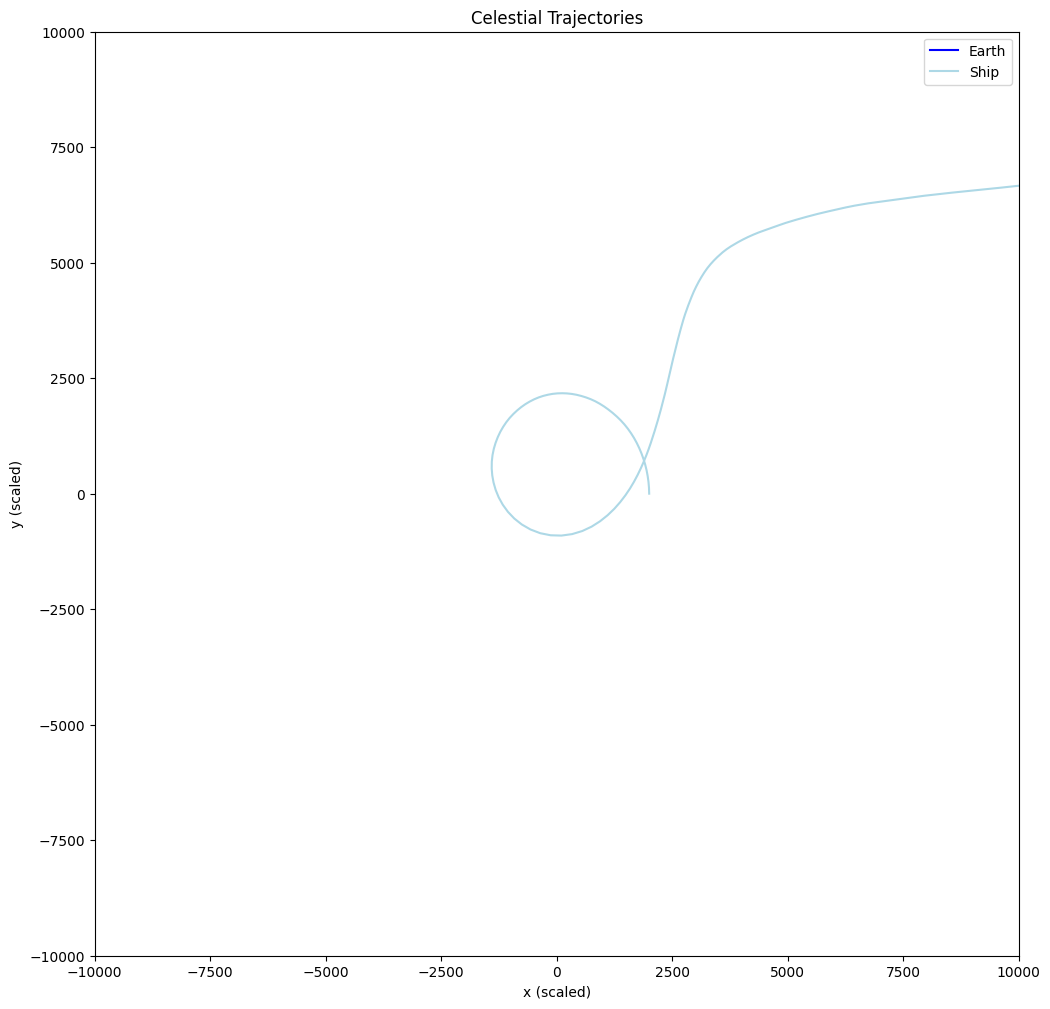

Success: Ship reached the target
Episode  240 | Return:  4.982e-01 | Loss:  3.447e+02


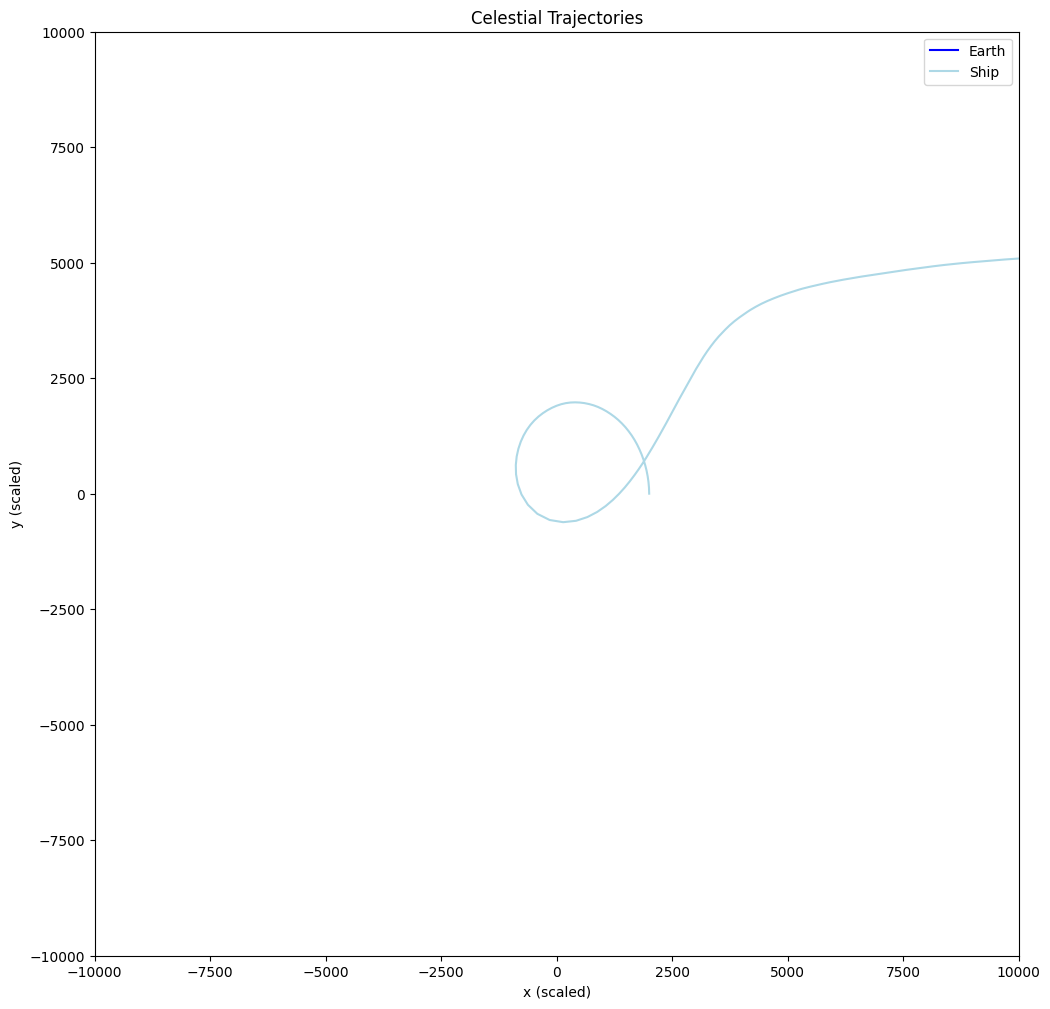

Failure: Ship escaped the system or exceeded system escape velocity
Episode  250 | Return:  1.683e+00 | Loss: -1.296e+02


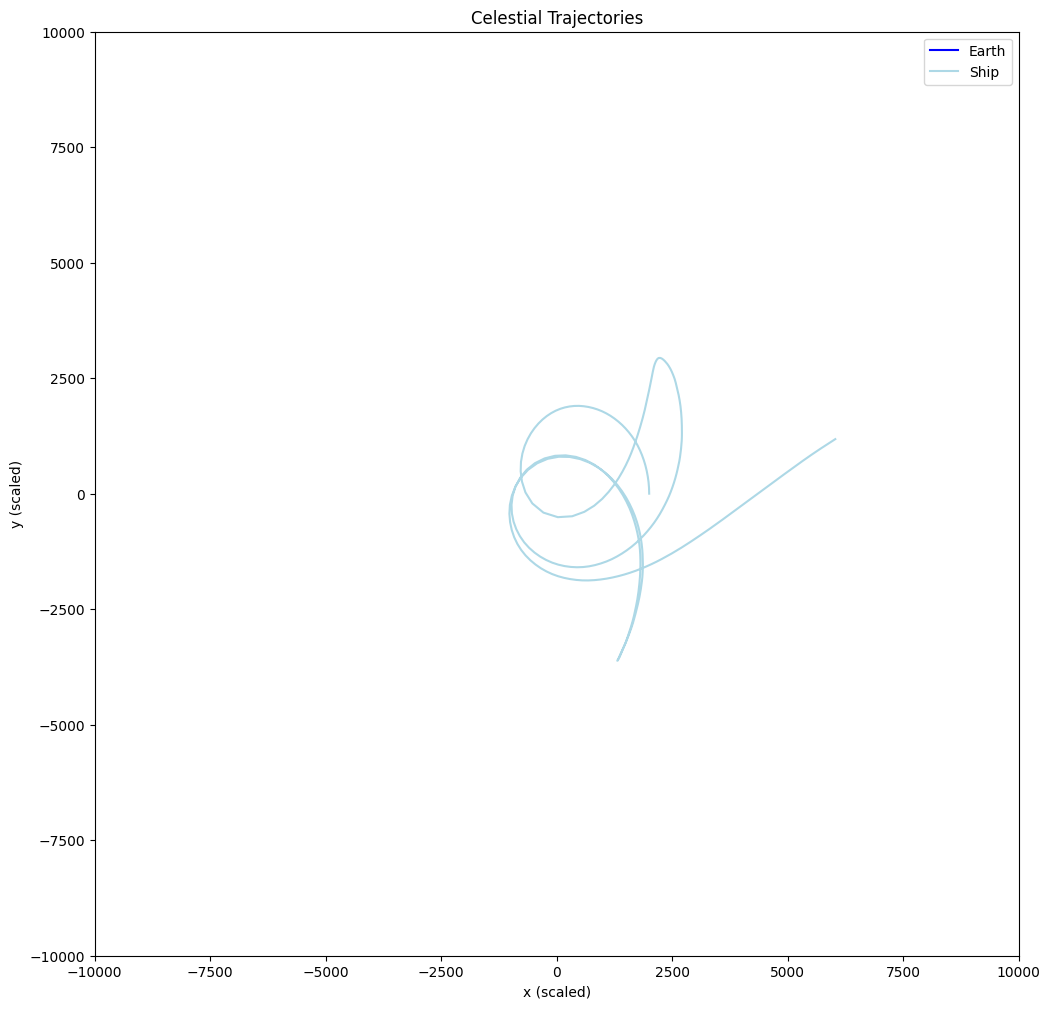

Success: Ship reached the target
Episode  260 | Return:  6.138e-01 | Loss:  8.453e+02


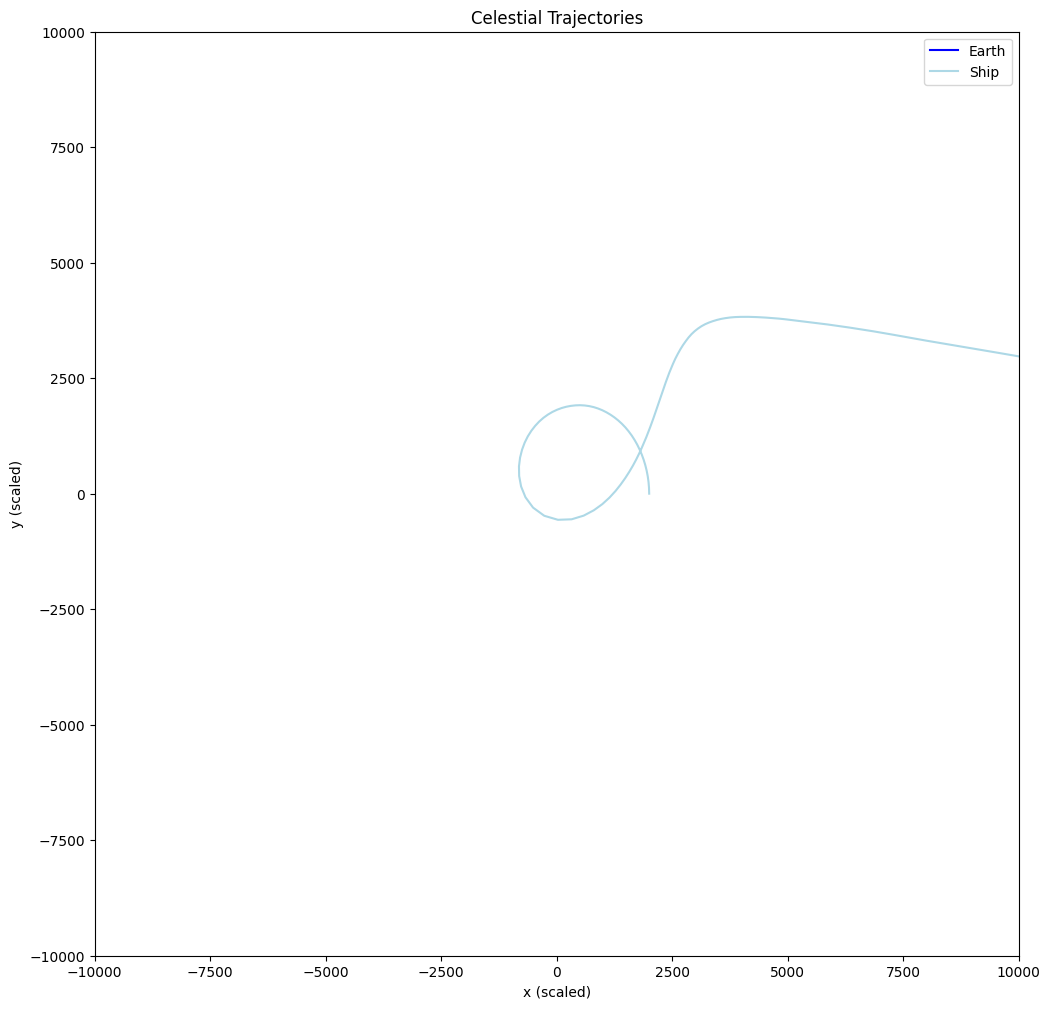

Success: Ship reached the target
Success: Ship reached the target
Episode  270 | Return:  7.874e-01 | Loss:  6.775e+02


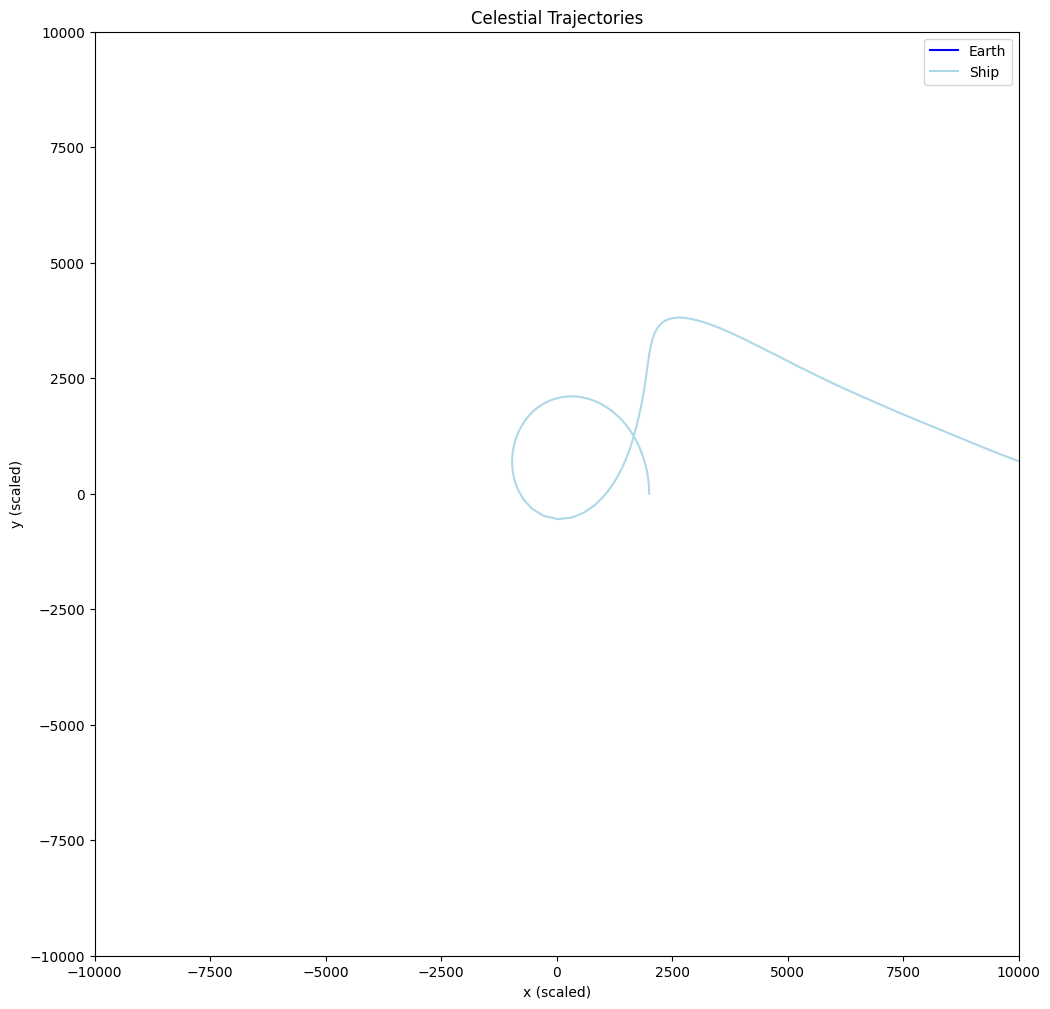

Success: Ship reached the target
Episode  280 | Return:  5.562e-01 | Loss:  9.100e+02


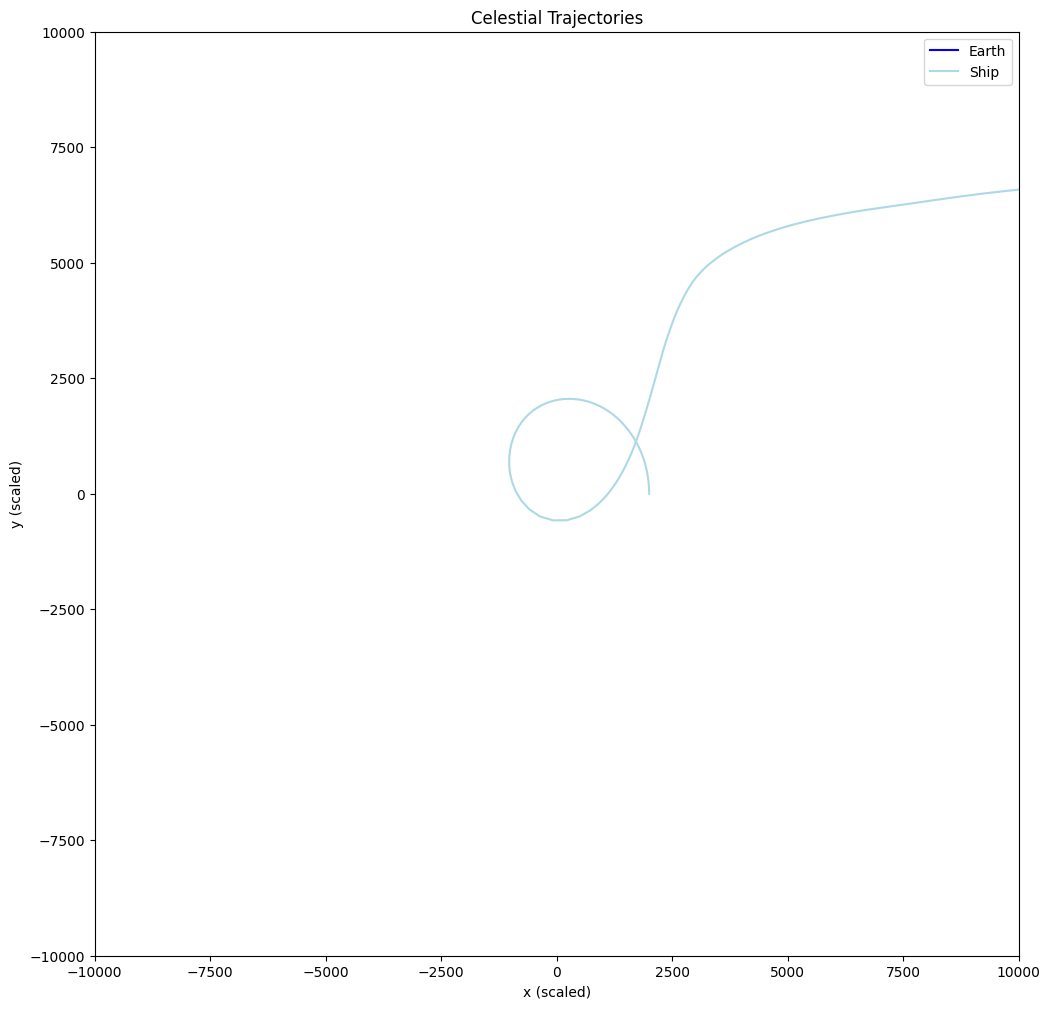

Episode  290 | Return:  1.664e+00 | Loss: -1.663e+02


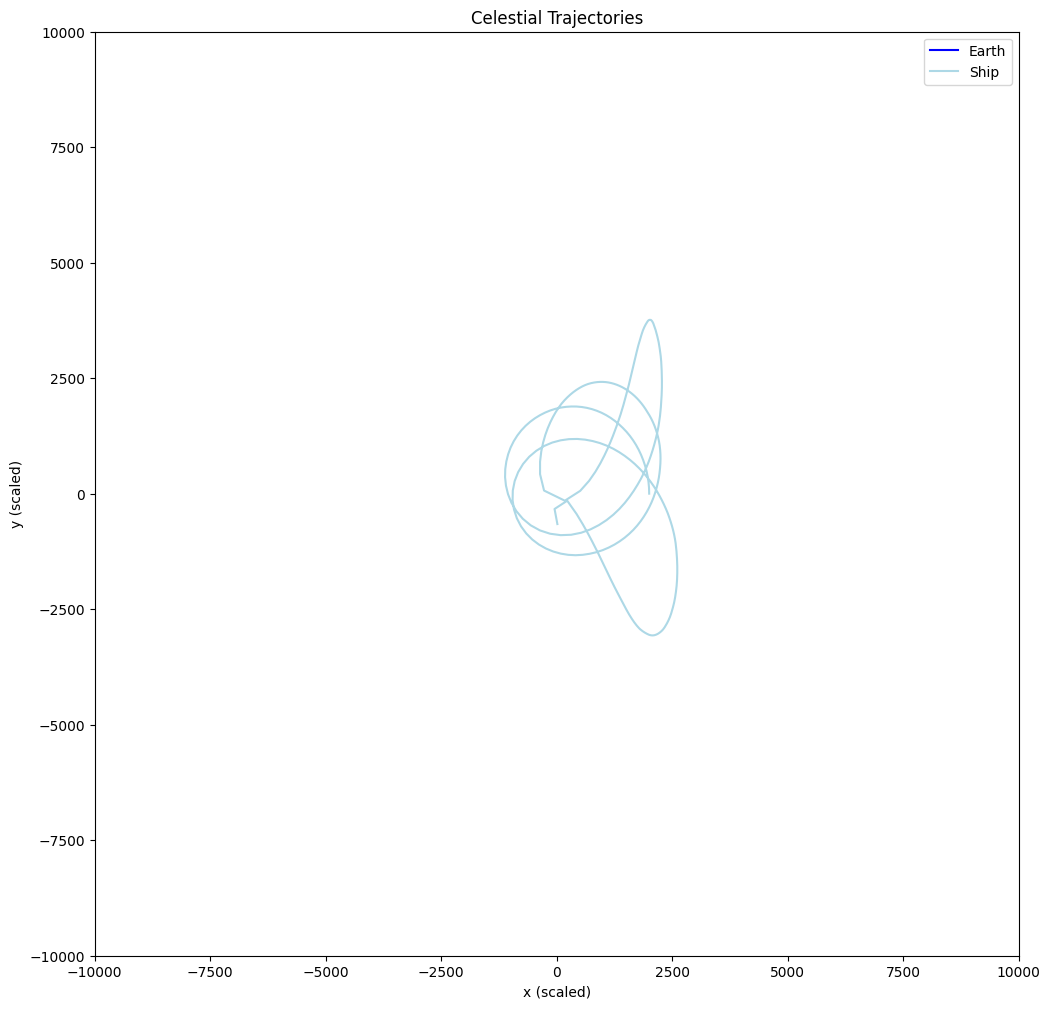

Failure: Ship crashed
Episode  300 | Return:  1.799e+00 | Loss: -3.547e+02


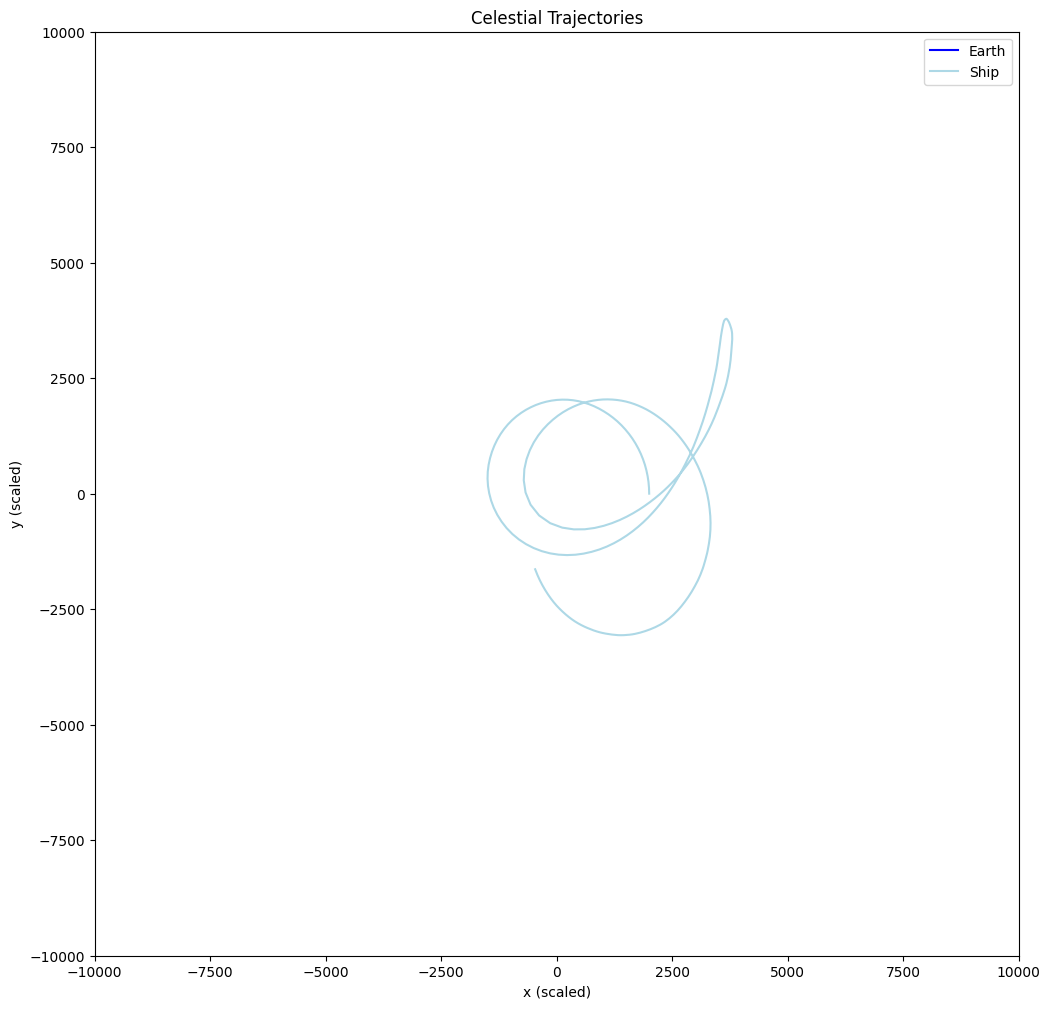

Failure: Ship crashed
Failure: Ship escaped the system or exceeded system escape velocity
Episode  310 | Return:  1.728e+00 | Loss:  6.880e+00


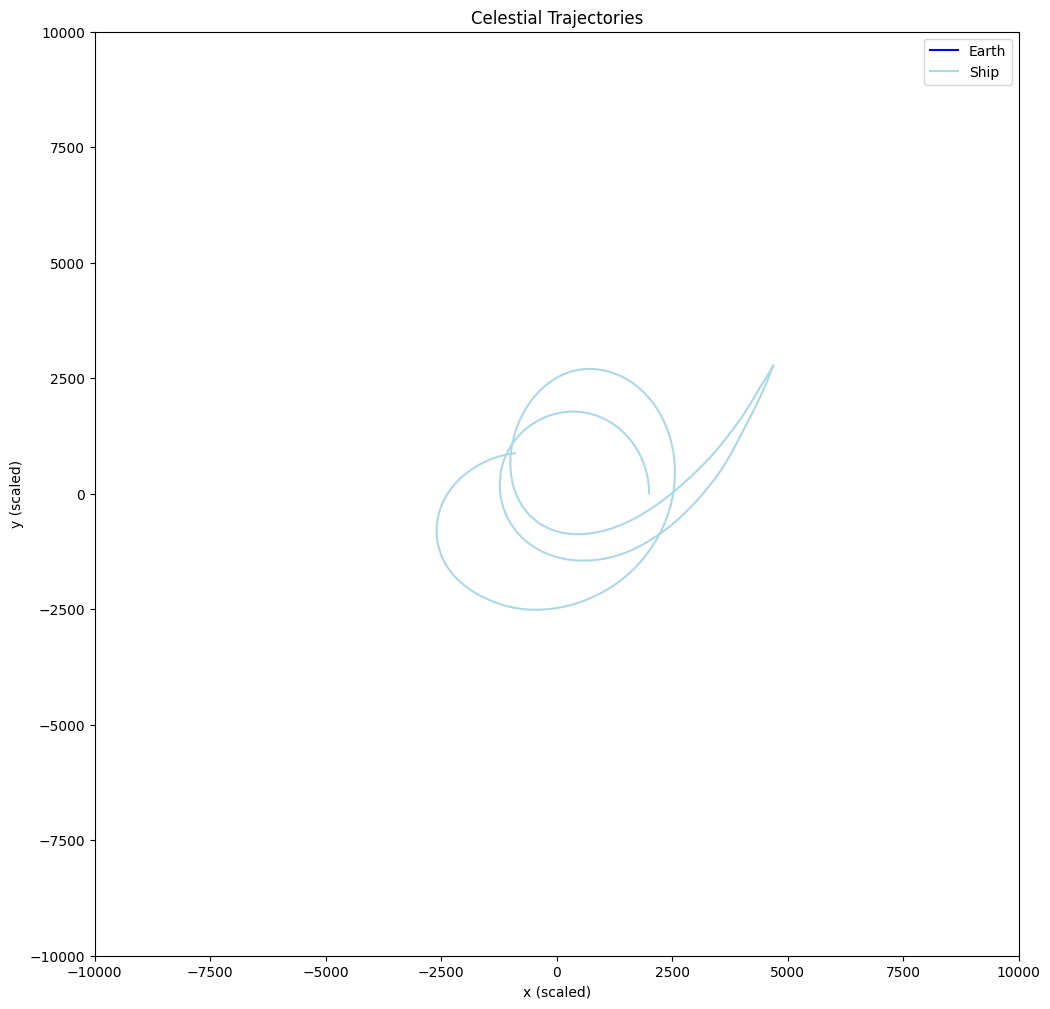

Failure: Ship crashed
Episode  320 | Return:  1.177e+00 | Loss:  4.789e+02


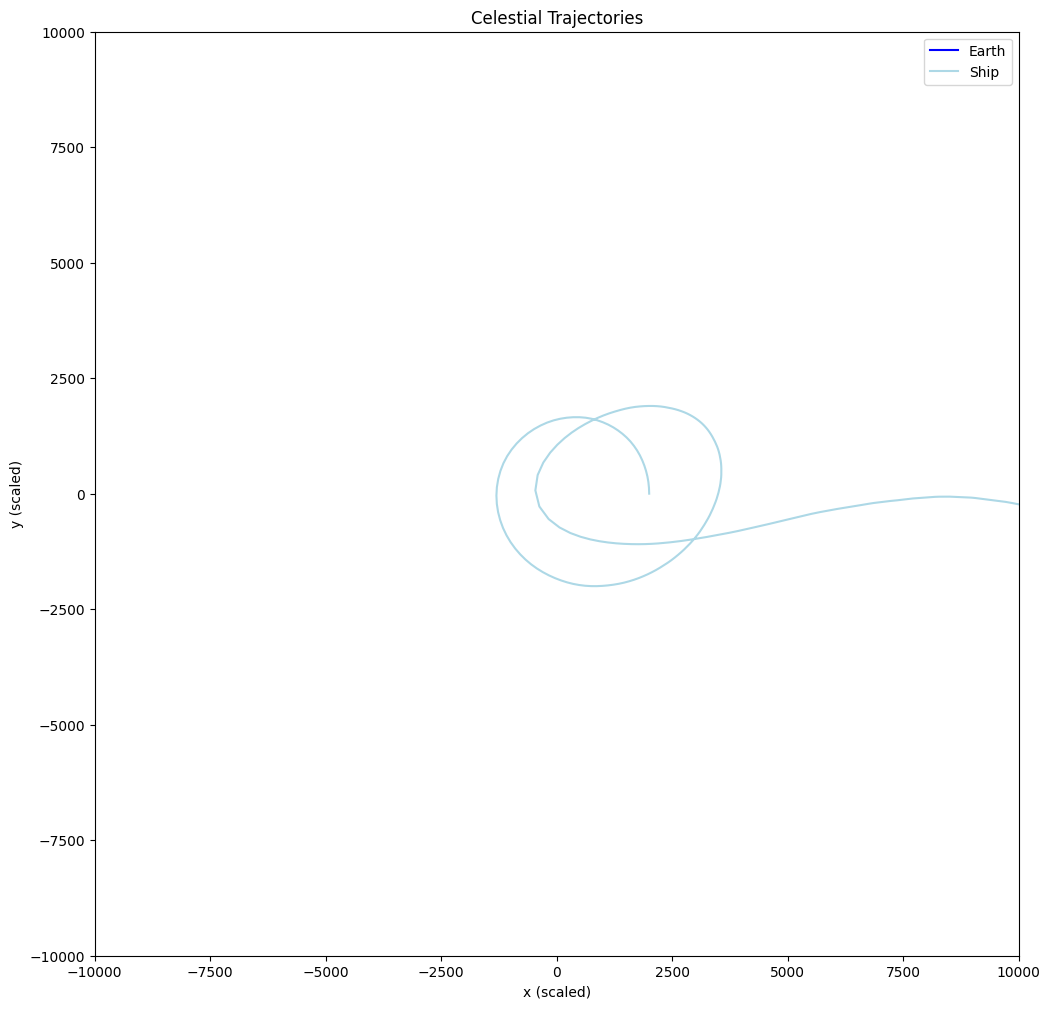

Episode  330 | Return:  1.289e+00 | Loss:  7.211e+02


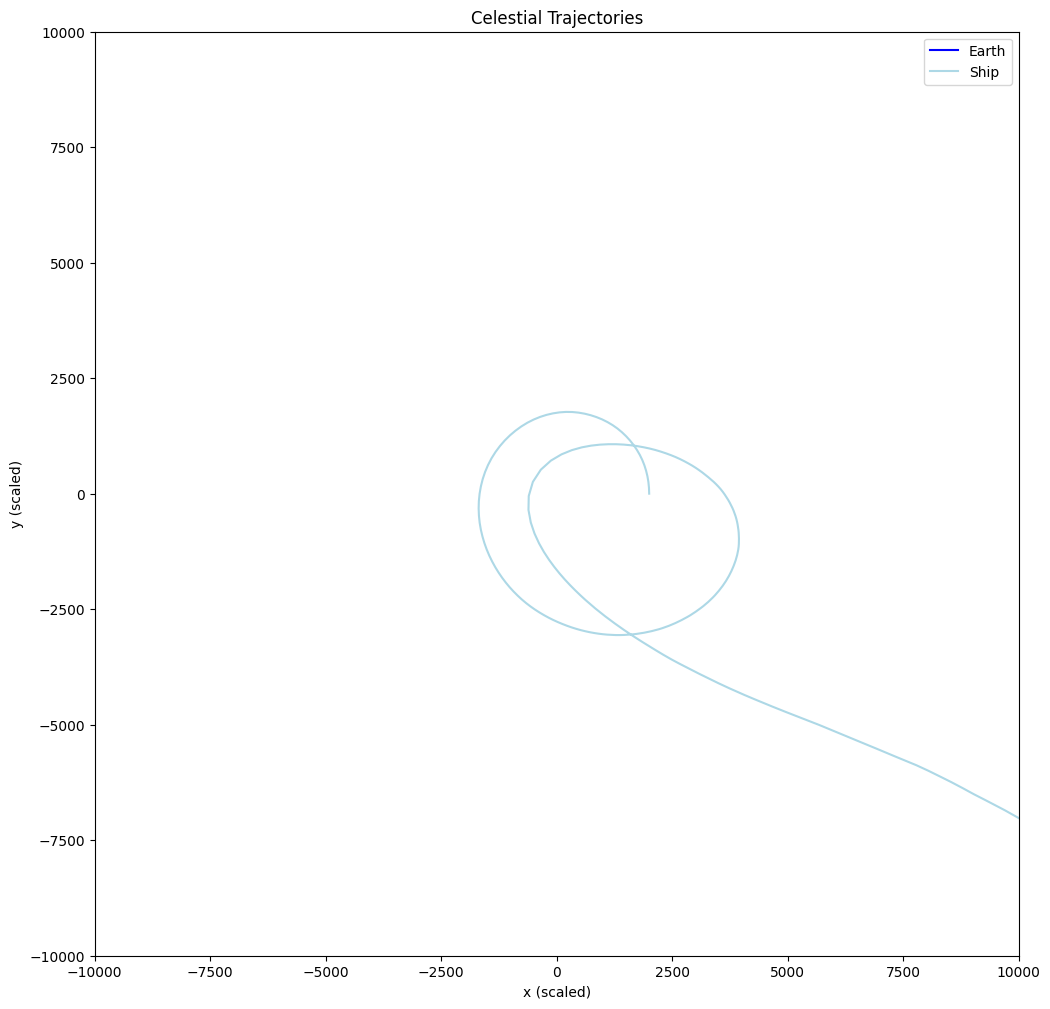

Failure: Ship escaped the system or exceeded system escape velocity
Episode  340 | Return: -9.080e-01 | Loss: -4.093e+01


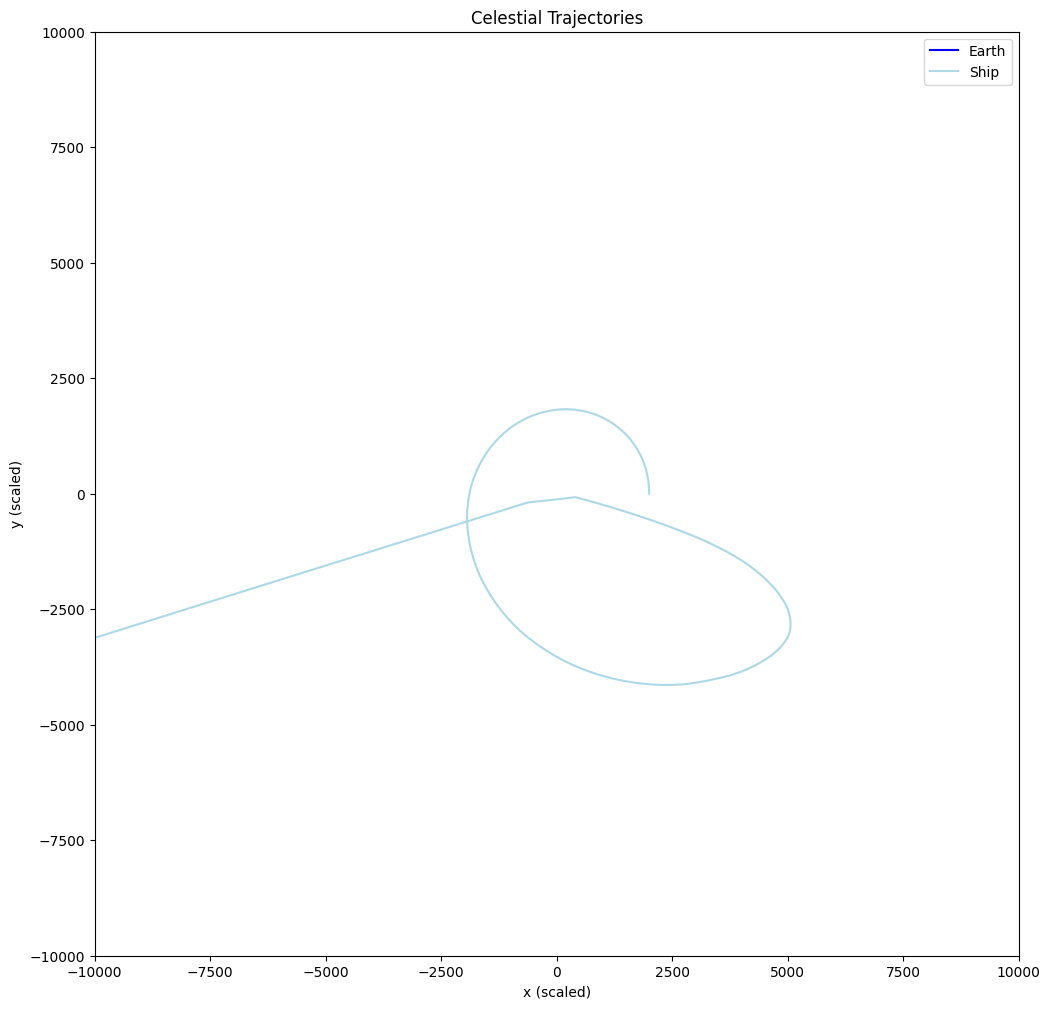

Failure: Ship crashed
Episode  350 | Return:  1.445e+00 | Loss:  7.510e+02


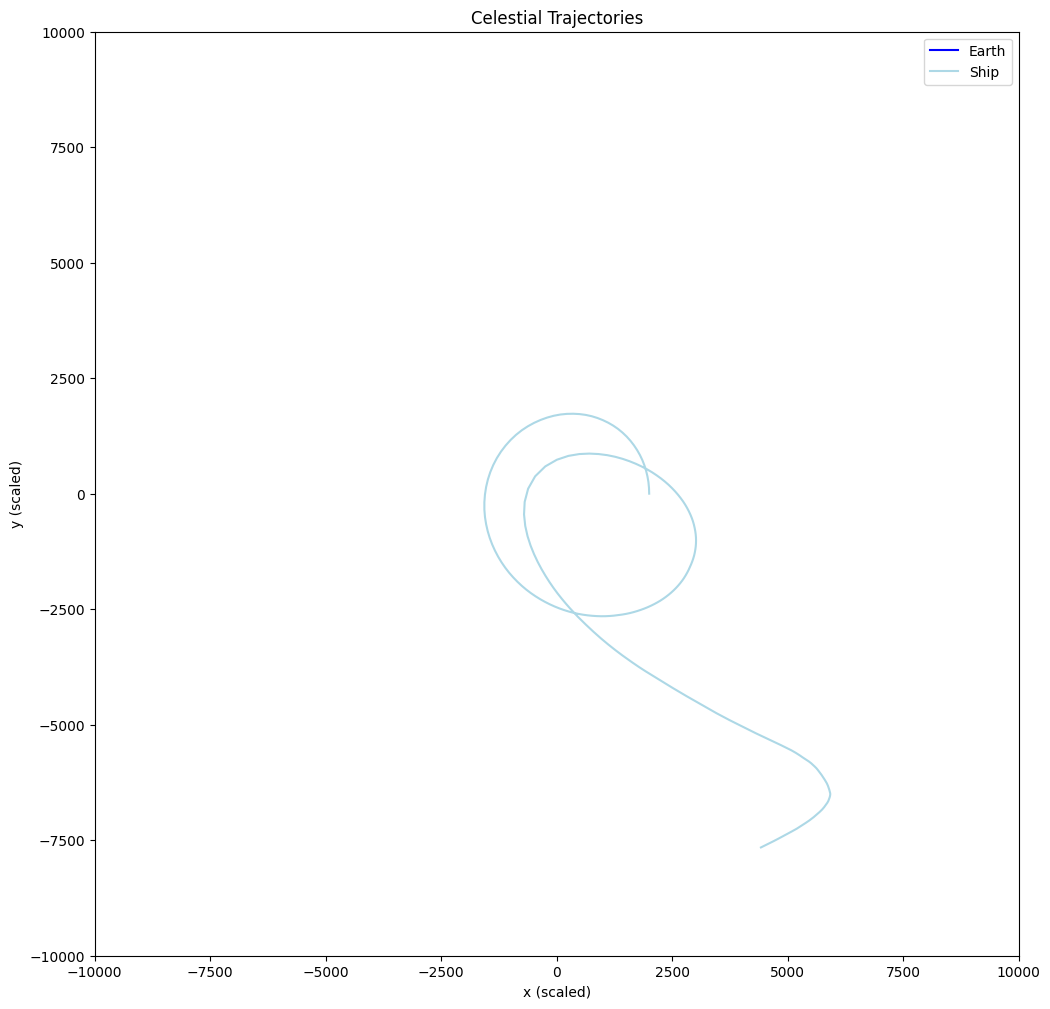

Episode  360 | Return:  1.510e+00 | Loss:  6.840e+02


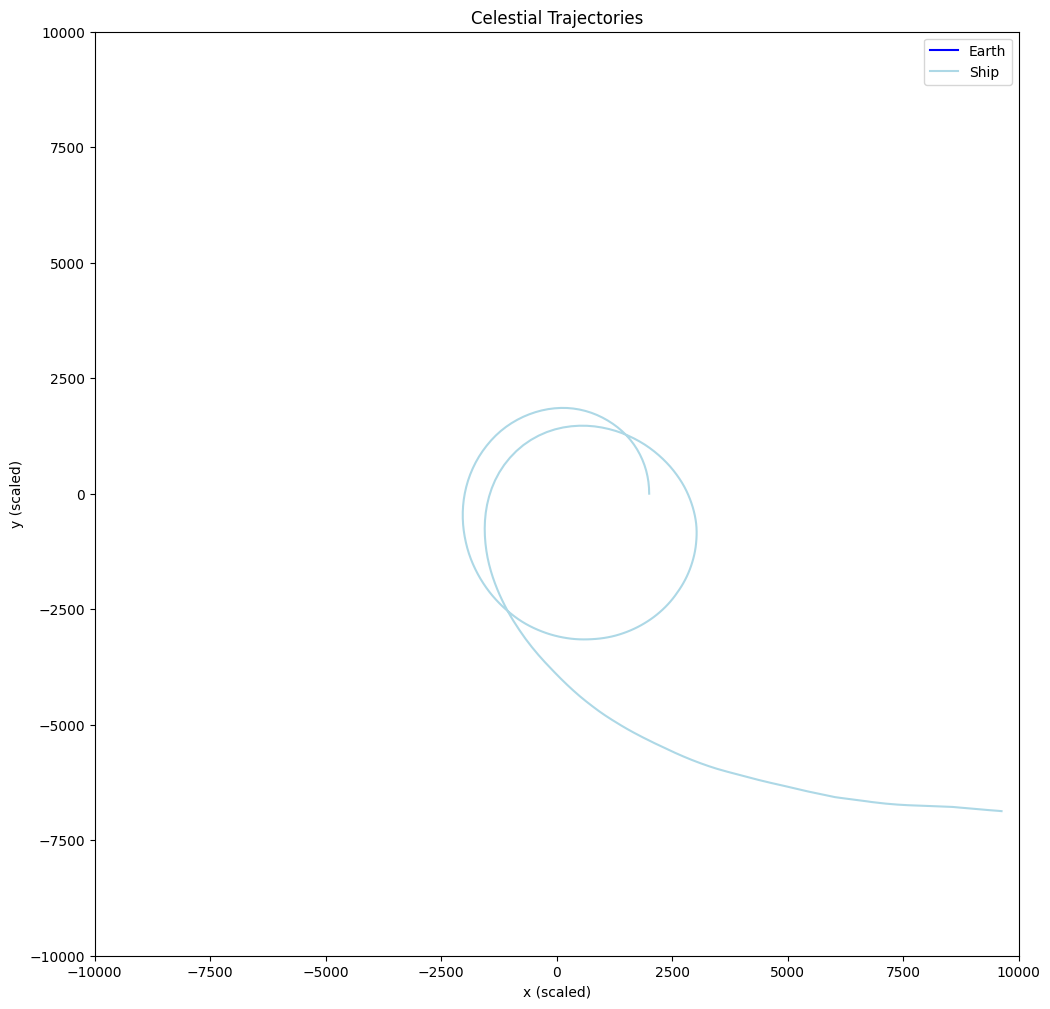

Episode  370 | Return:  1.909e+00 | Loss:  9.736e+02


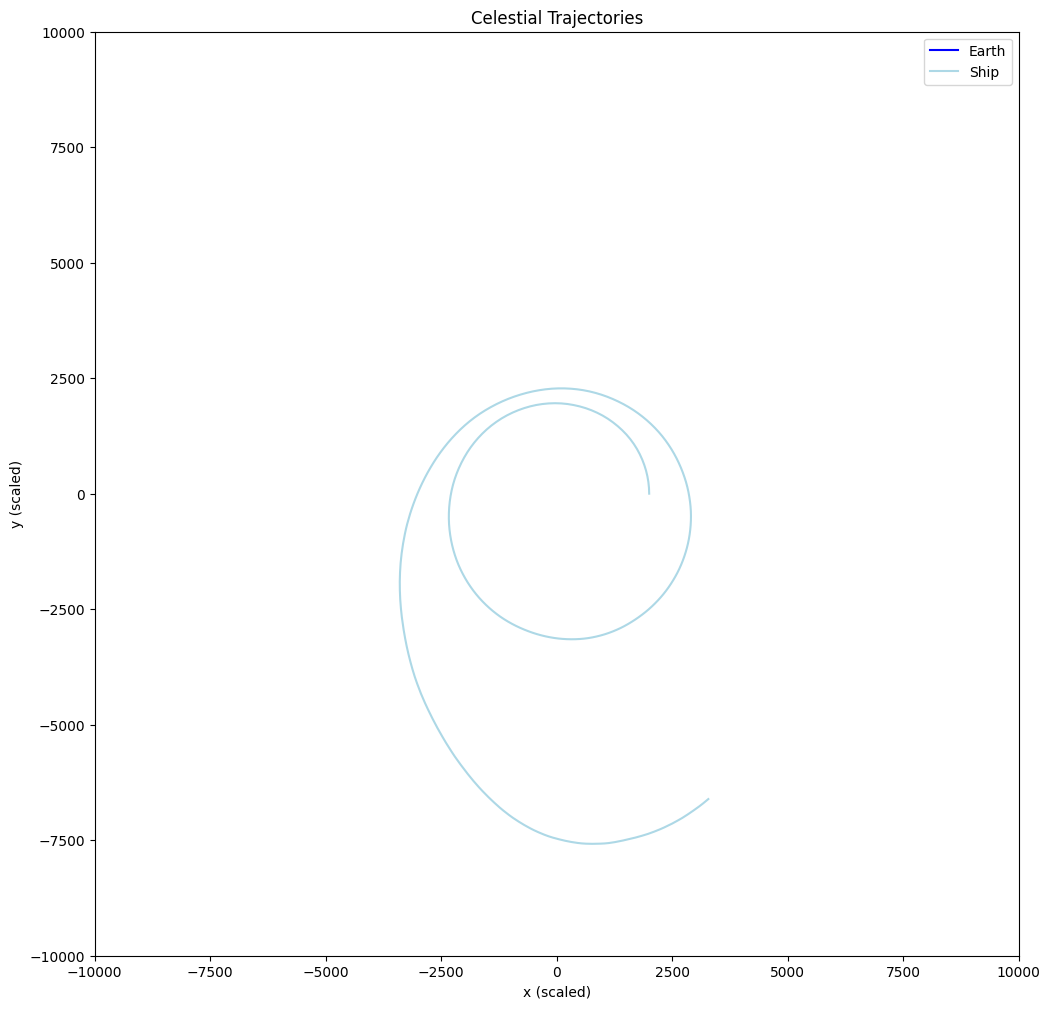

Episode  380 | Return:  2.168e+00 | Loss:  3.921e+01


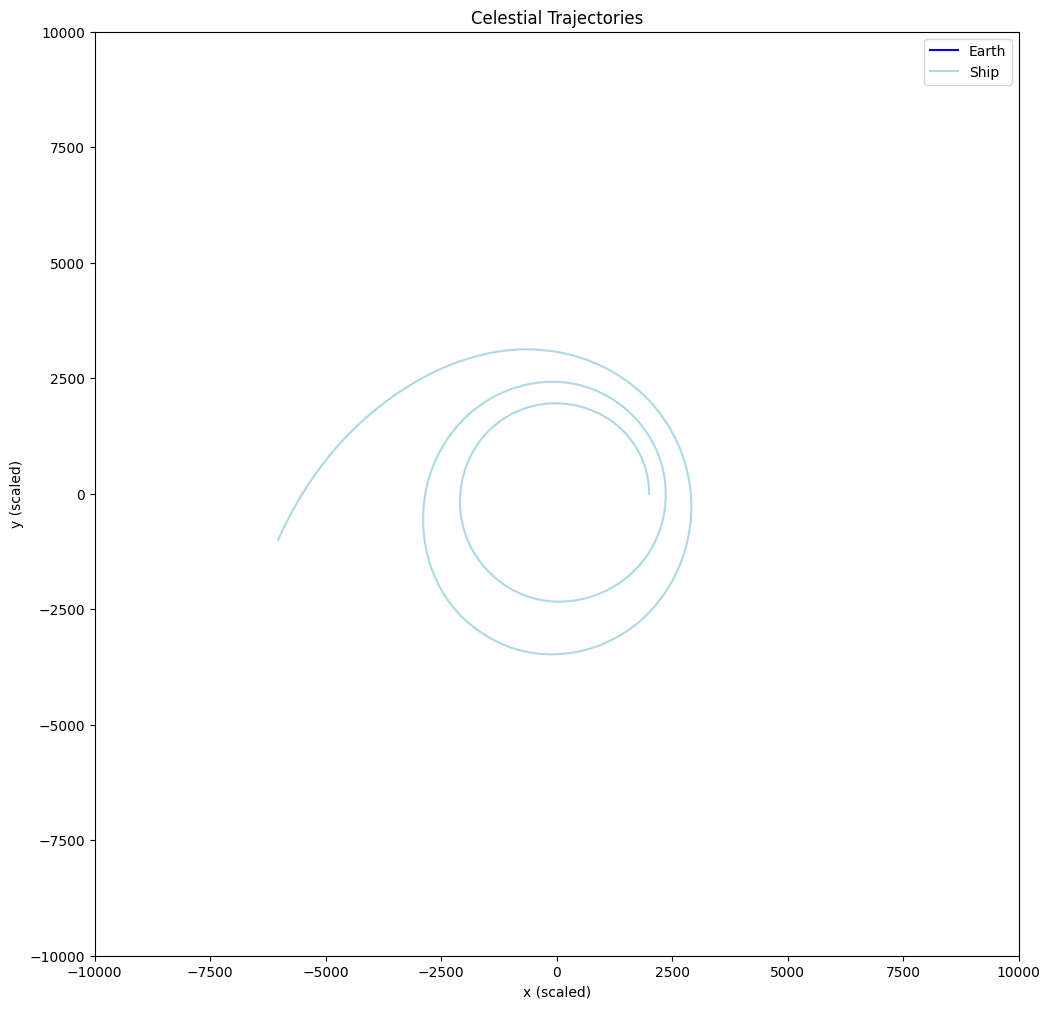

Episode  390 | Return:  2.146e+00 | Loss: -1.951e+02


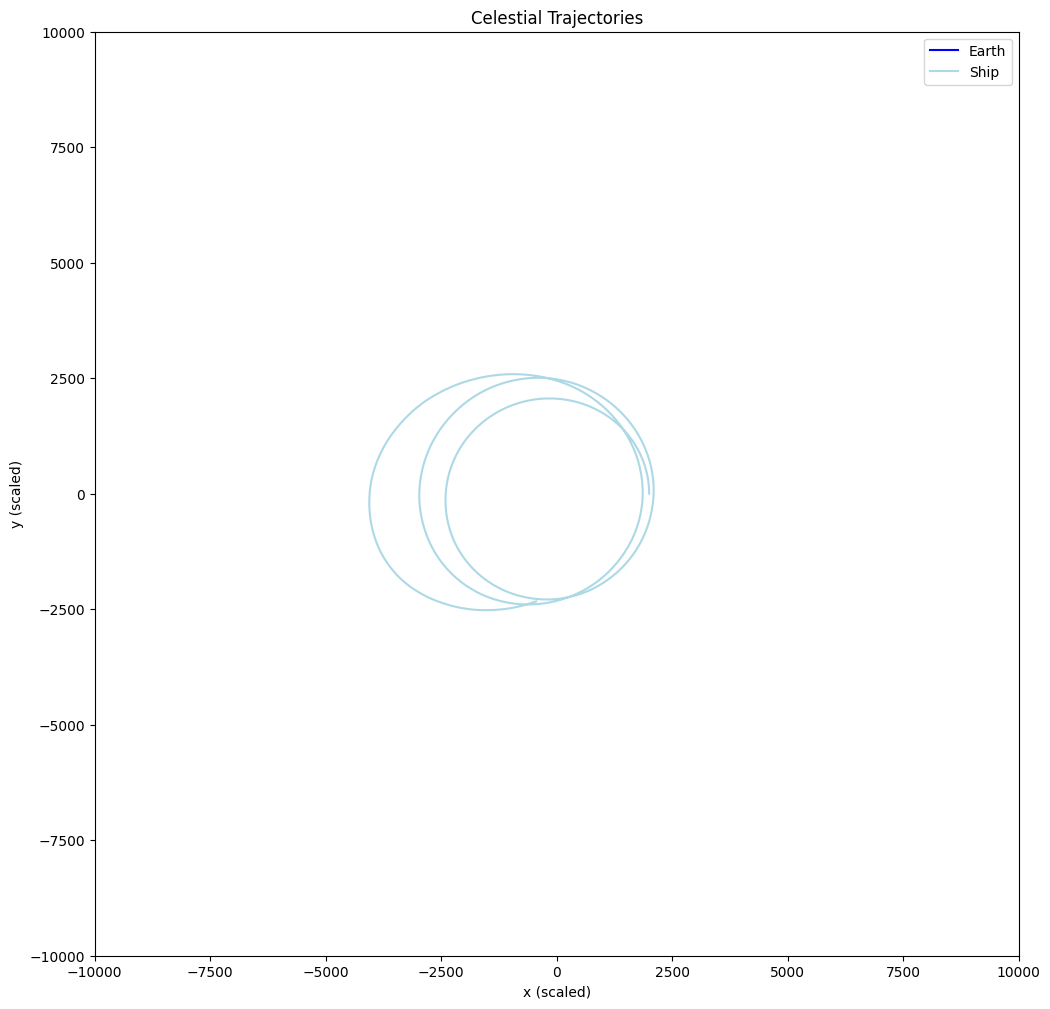

Episode  400 | Return:  2.079e+00 | Loss:  2.666e+02


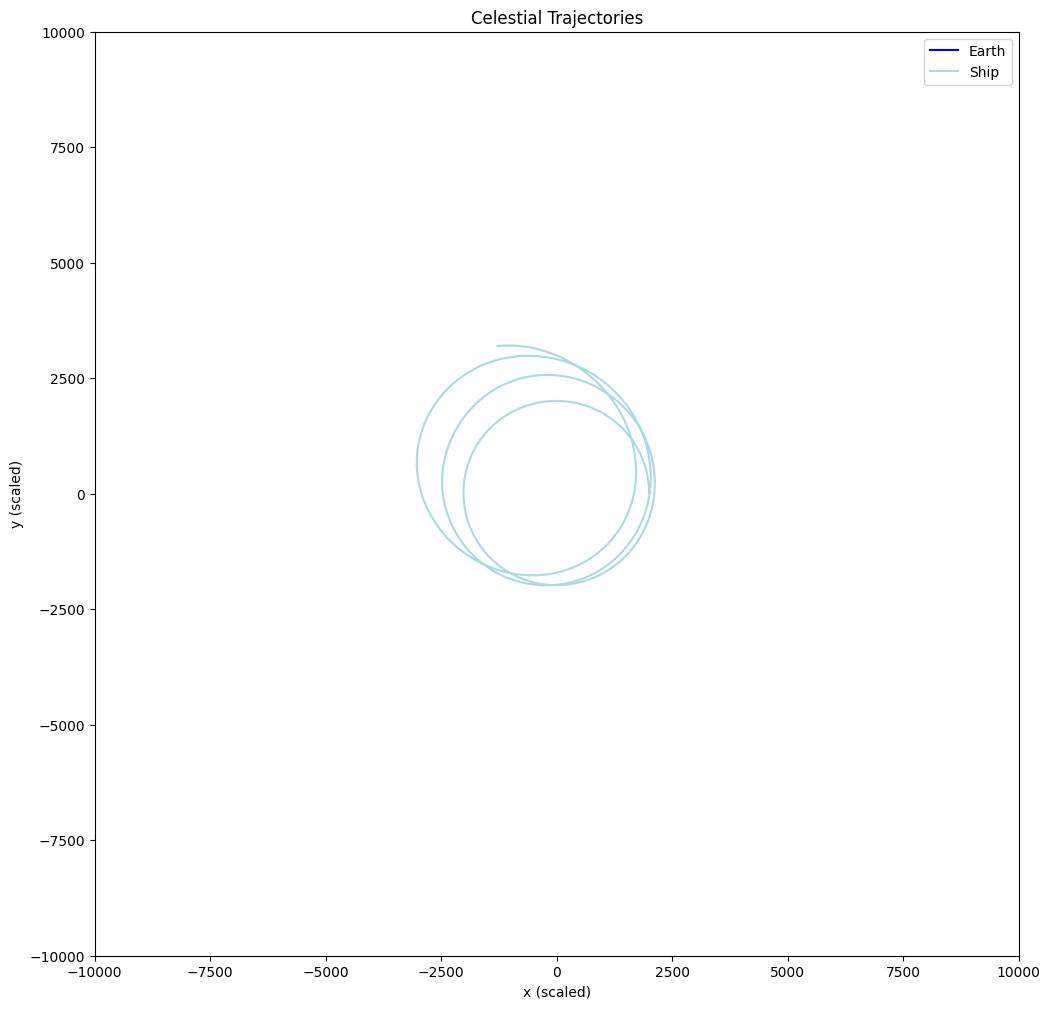

Episode  410 | Return:  2.024e+00 | Loss:  2.512e+02


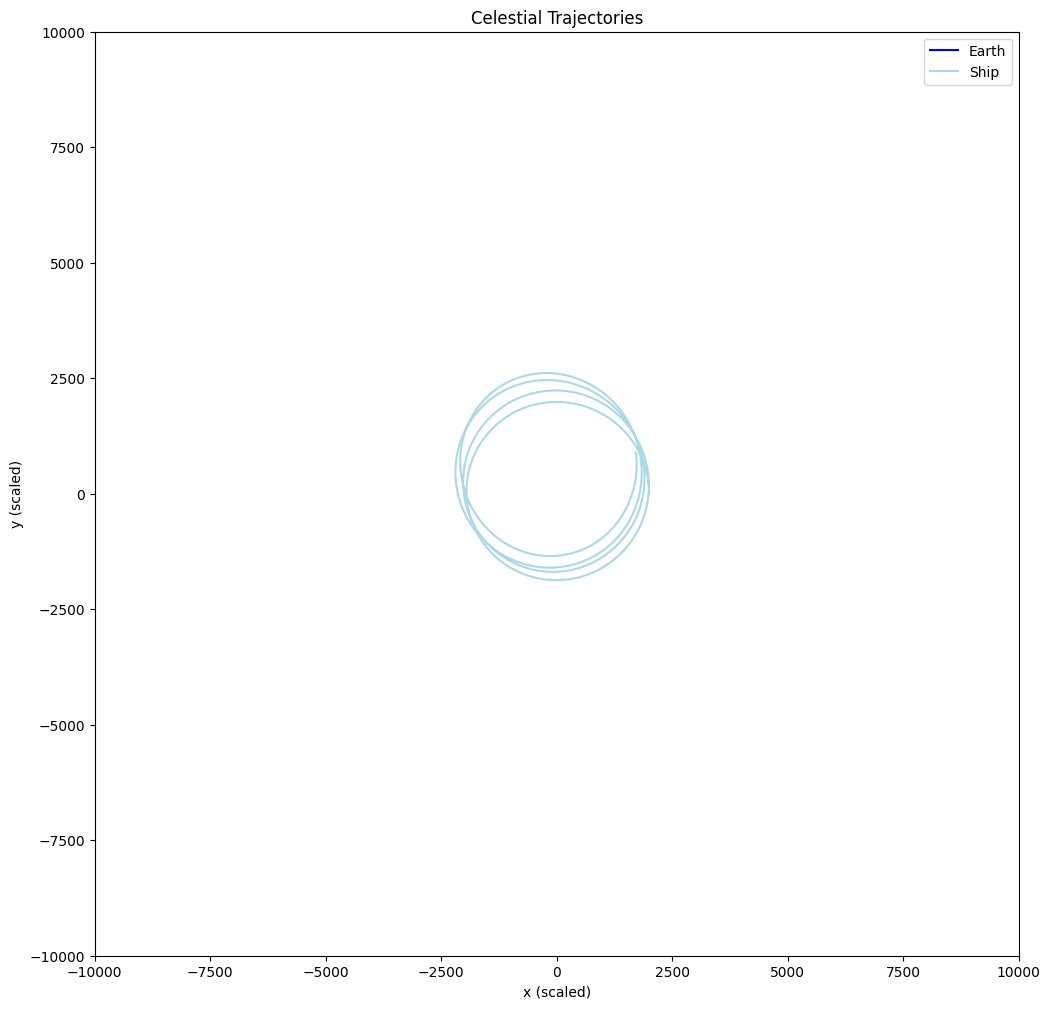

Episode  420 | Return:  2.043e+00 | Loss: -8.375e+01


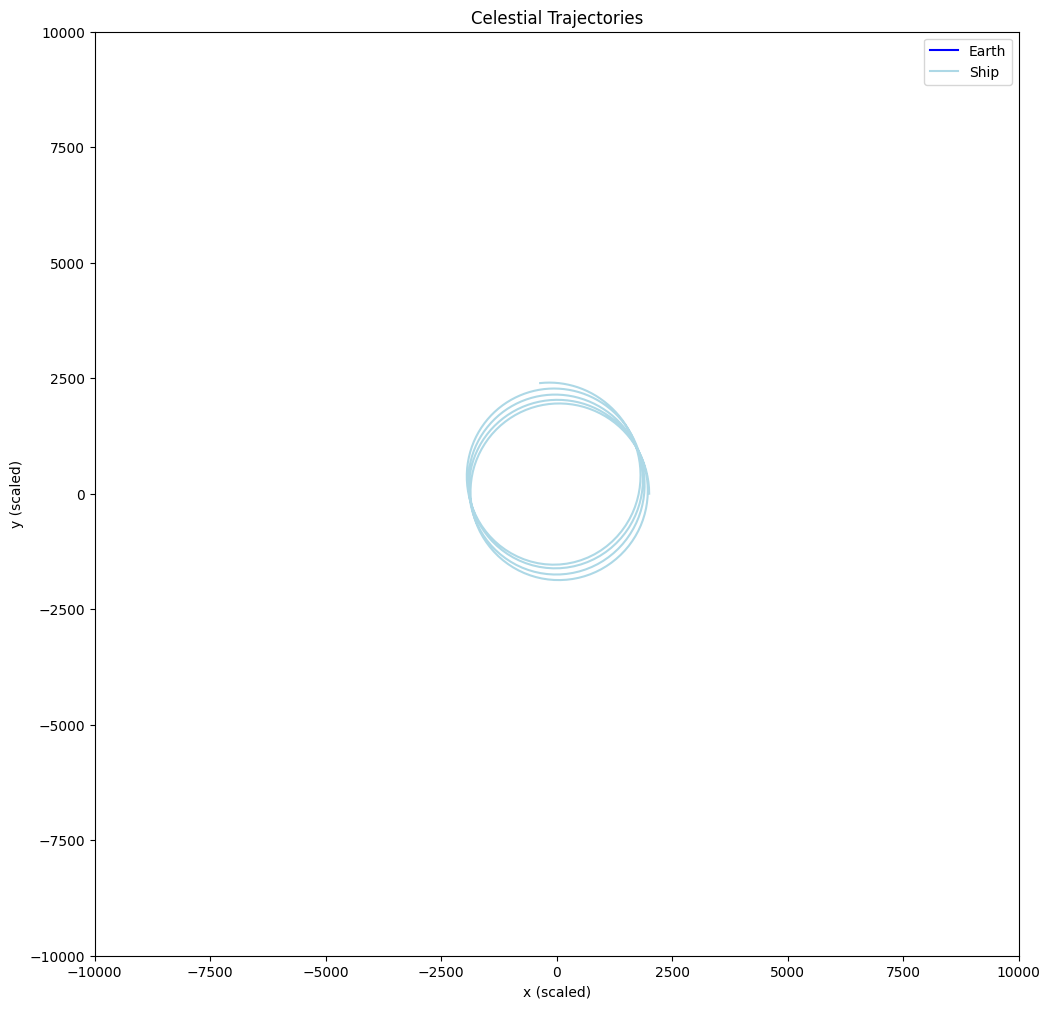

Episode  430 | Return:  2.067e+00 | Loss: -2.475e+01


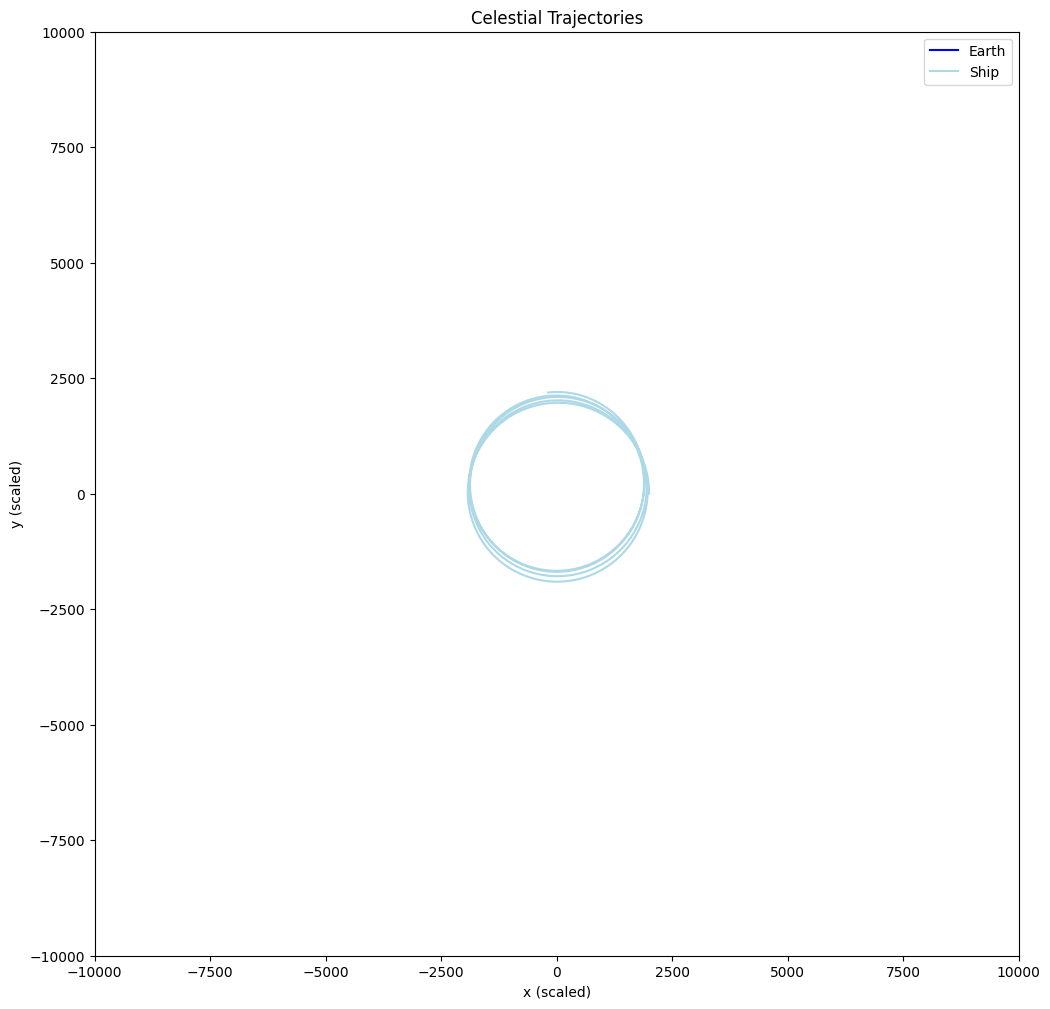

Episode  440 | Return:  2.076e+00 | Loss: -1.892e+02


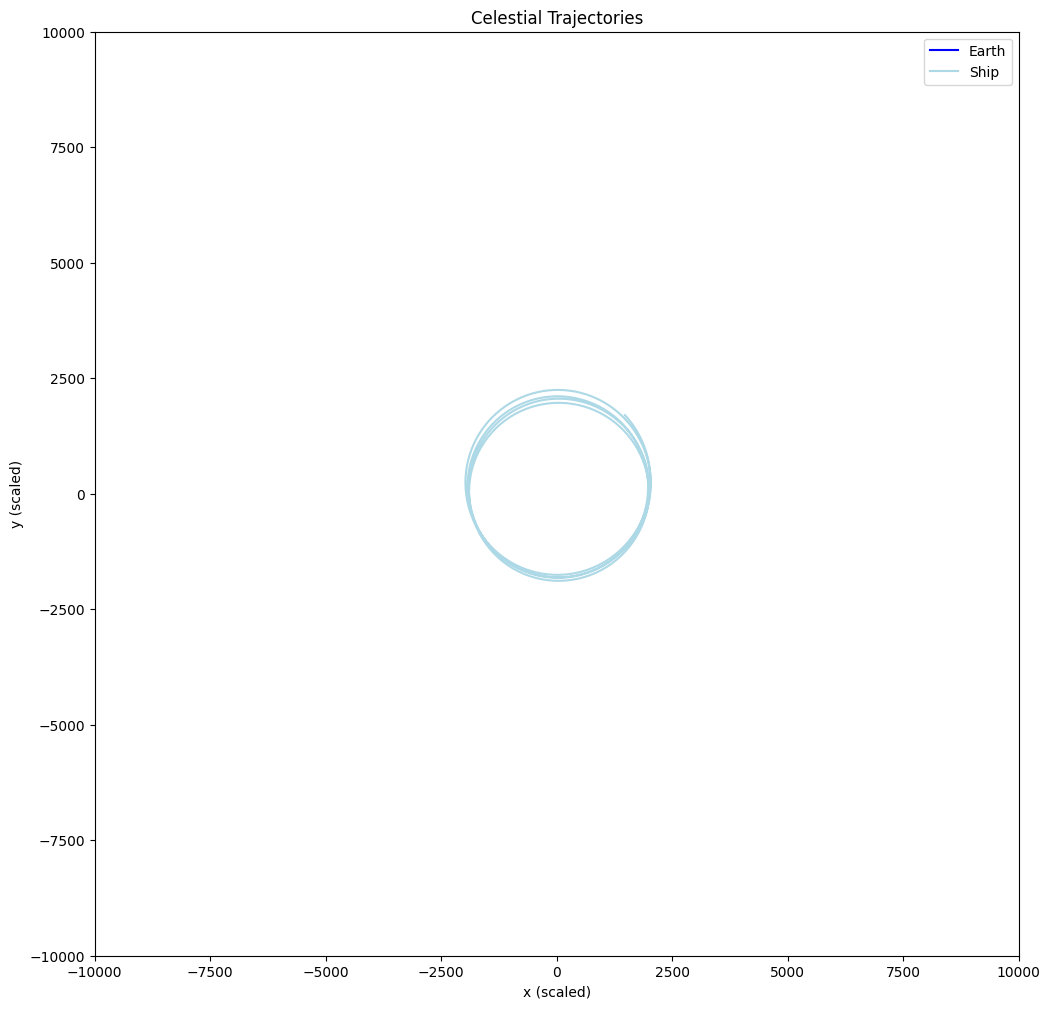

Episode  450 | Return:  2.092e+00 | Loss:  1.510e+01


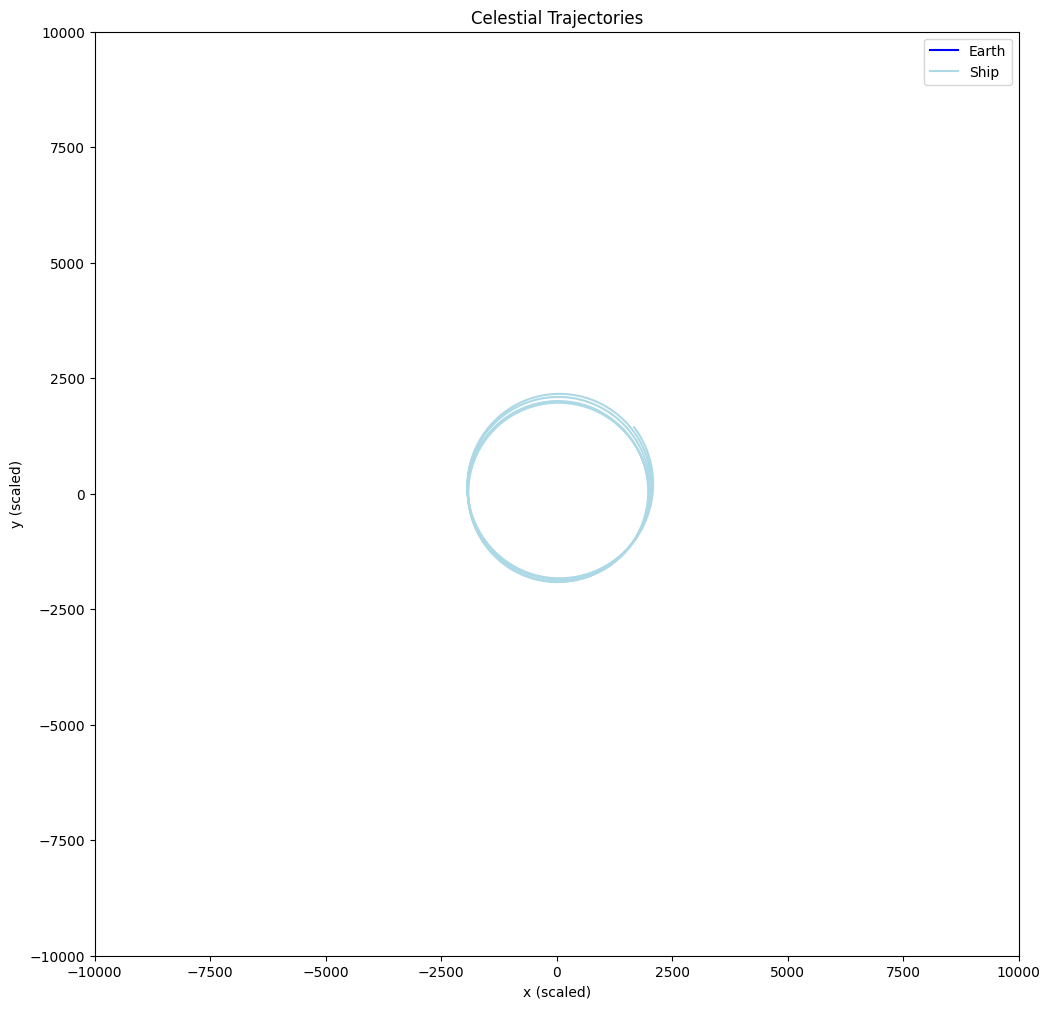

Episode  460 | Return:  2.087e+00 | Loss:  4.108e+01


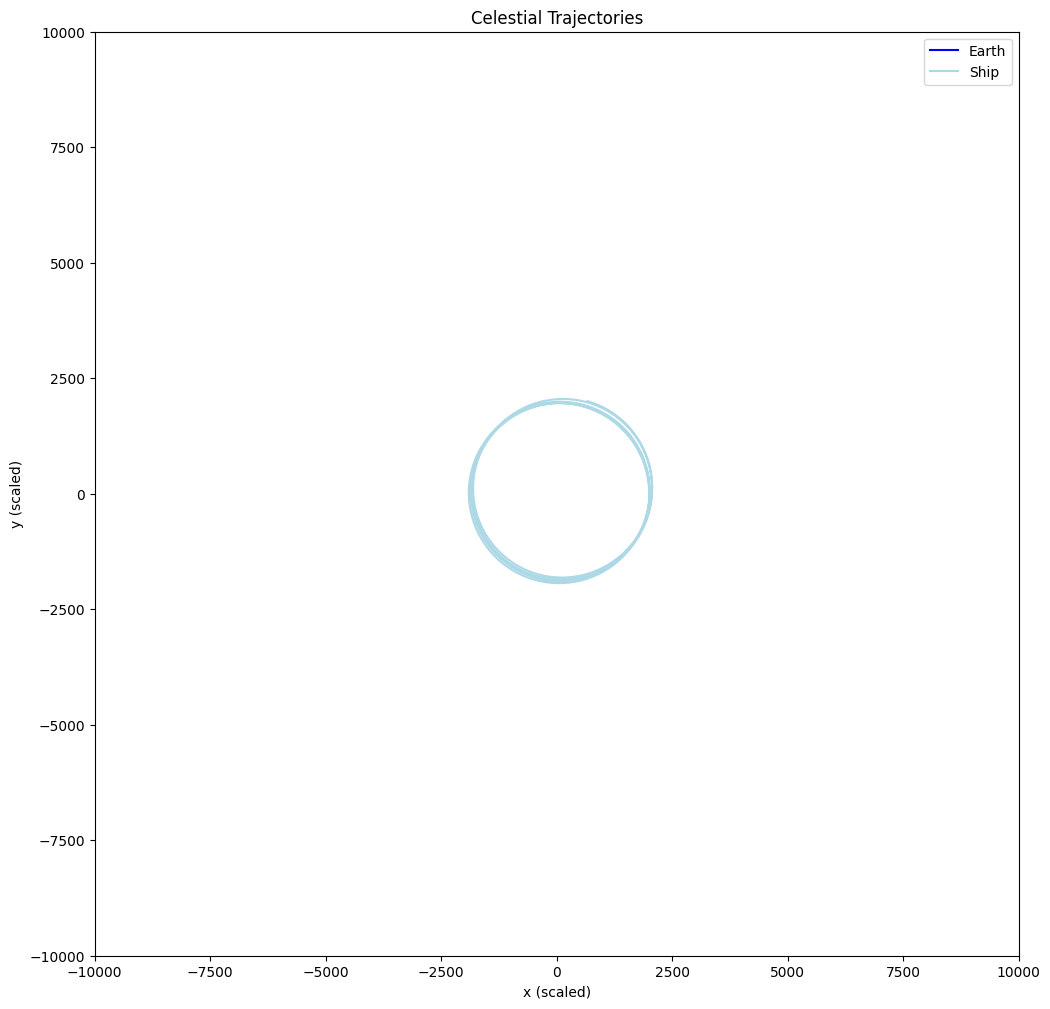

Episode  470 | Return:  2.082e+00 | Loss:  9.266e+01


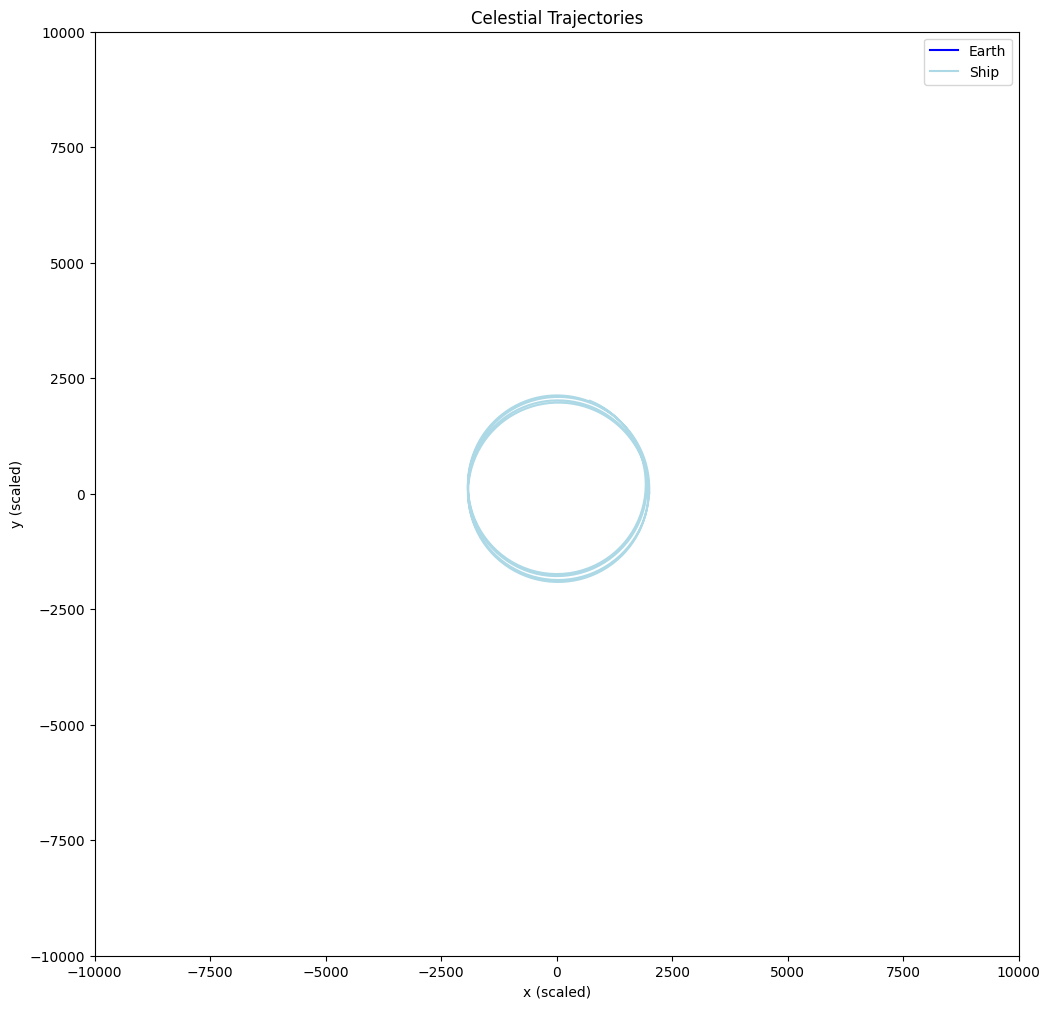

Episode  480 | Return:  2.112e+00 | Loss: -5.113e+01


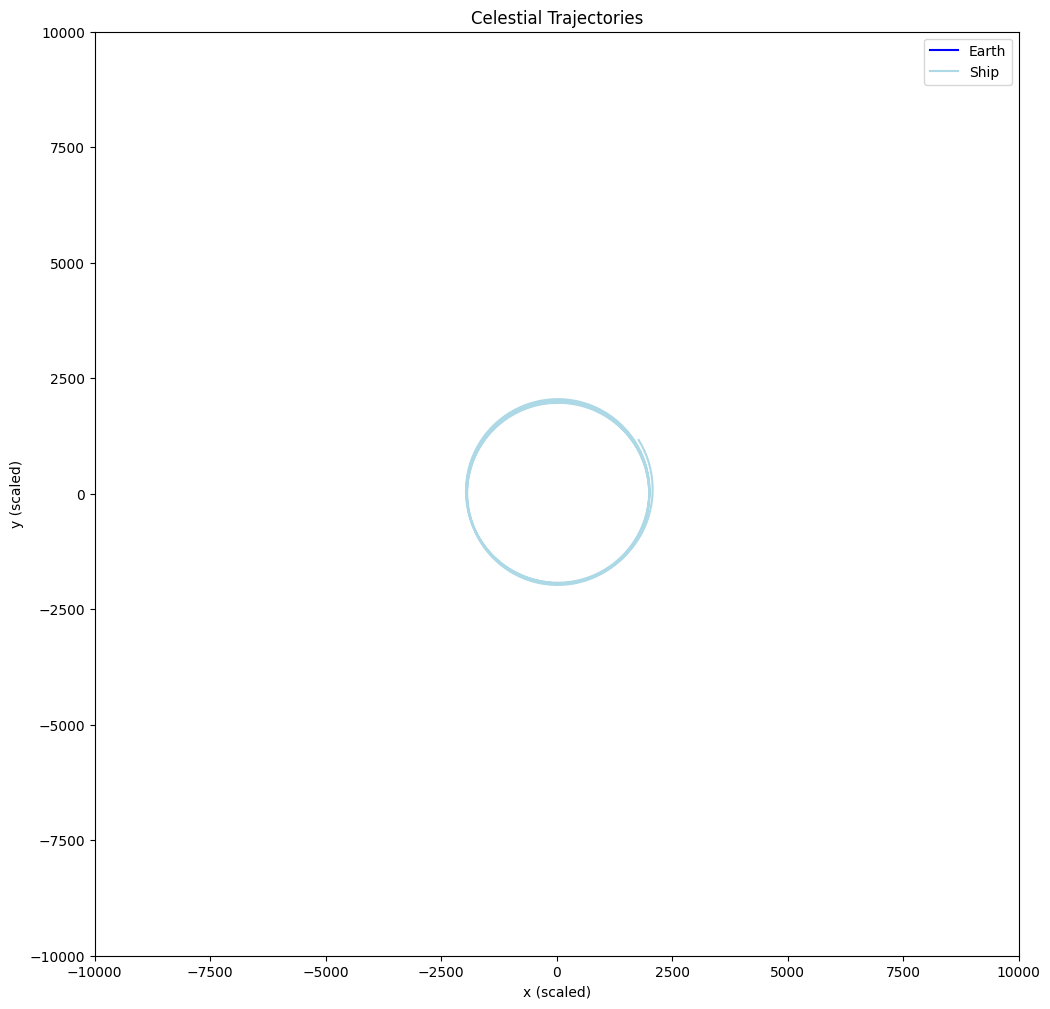

Episode  490 | Return:  2.097e+00 | Loss:  4.686e+01


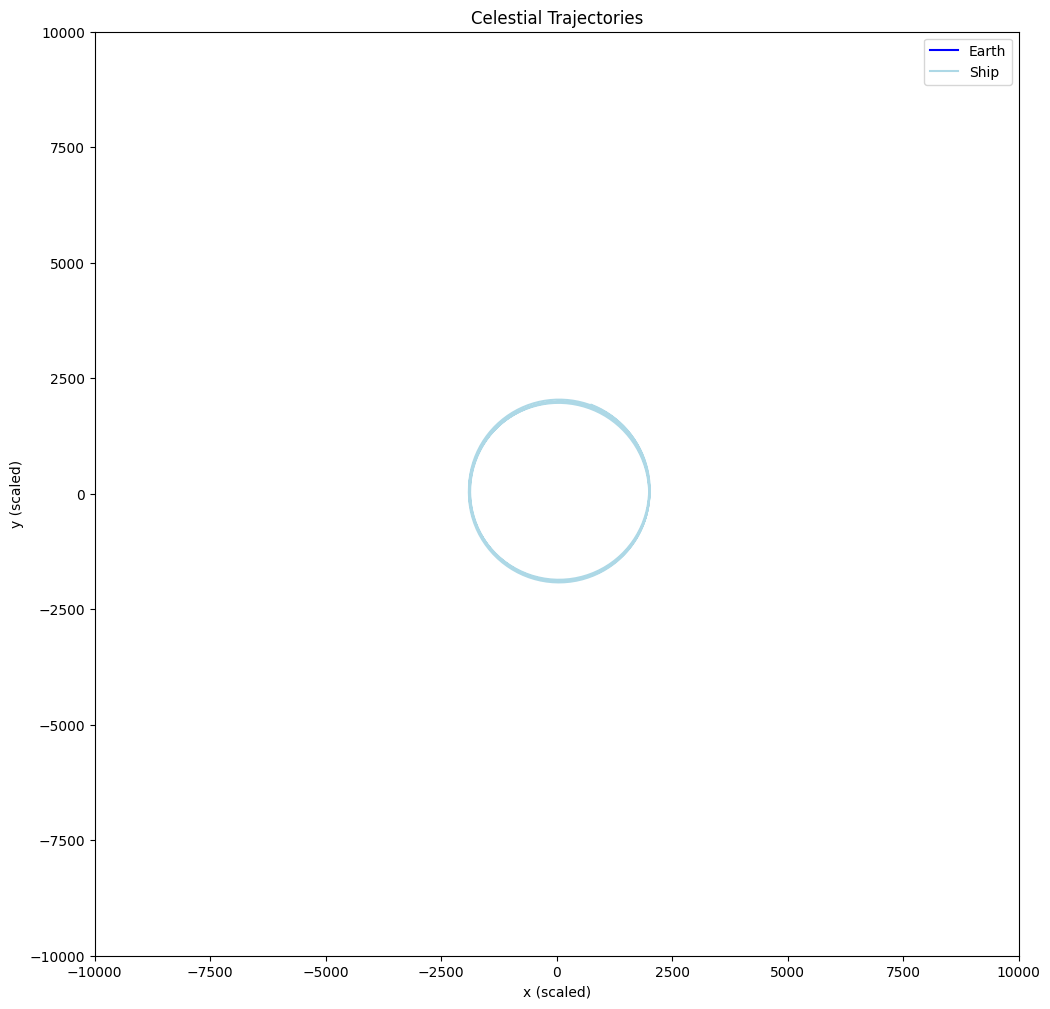

Episode  500 | Return:  2.100e+00 | Loss: -5.427e+01


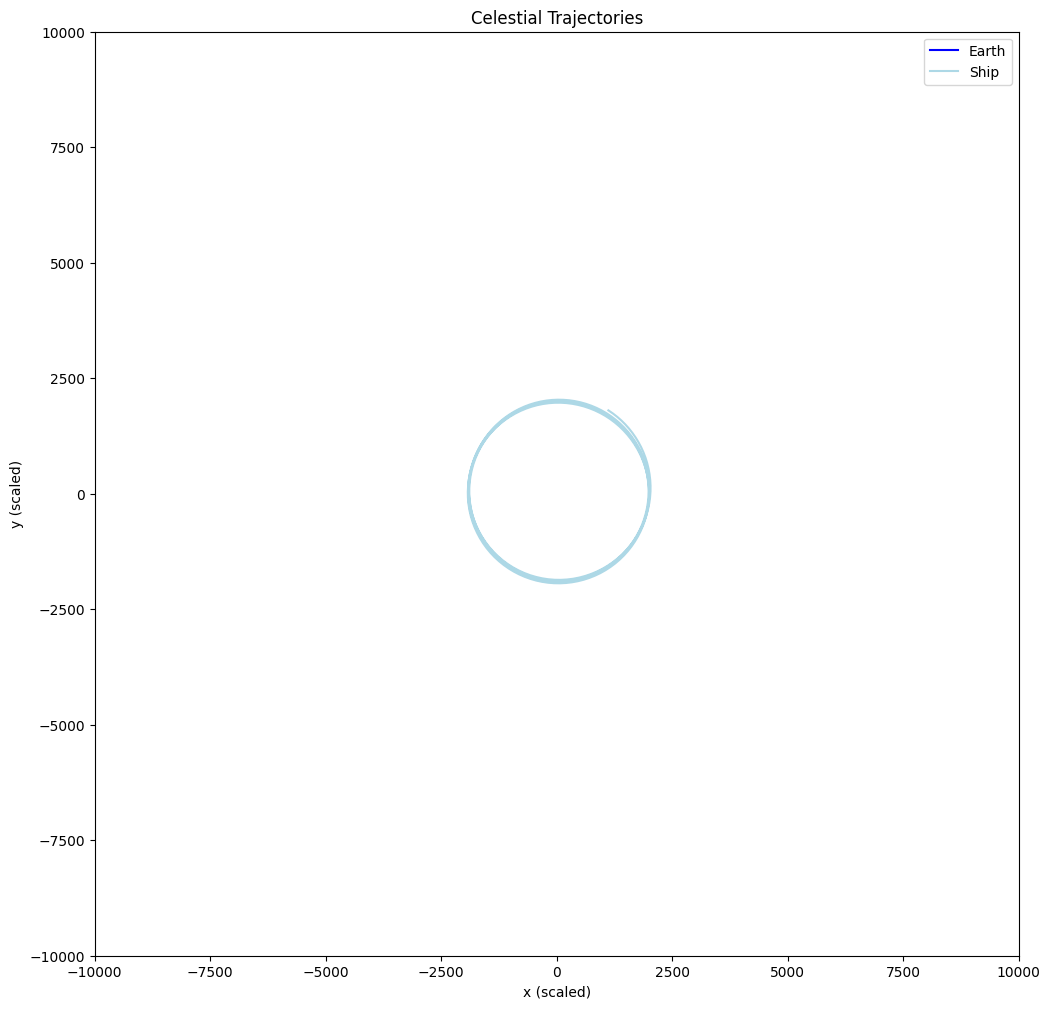

Episode  510 | Return:  2.098e+00 | Loss:  3.597e+00


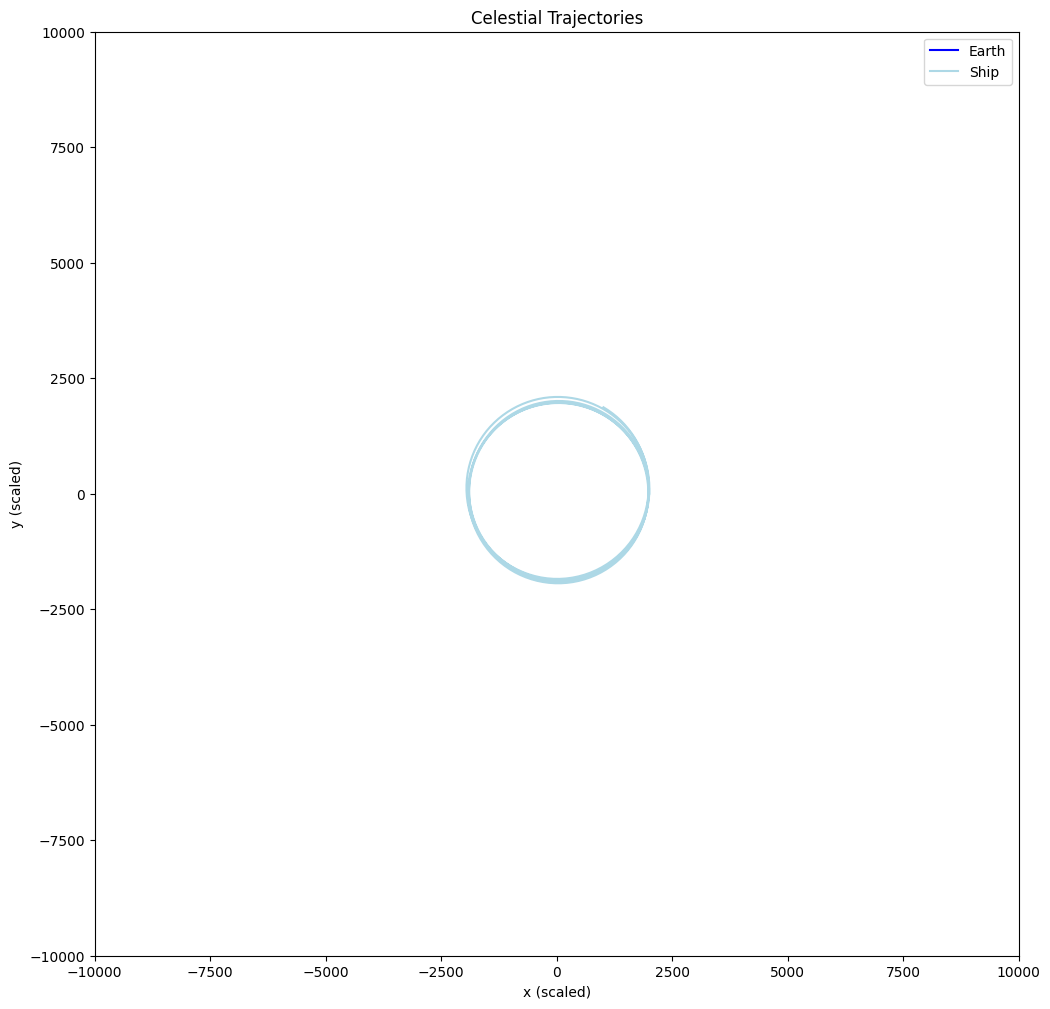

Episode  520 | Return:  2.109e+00 | Loss:  3.409e+01


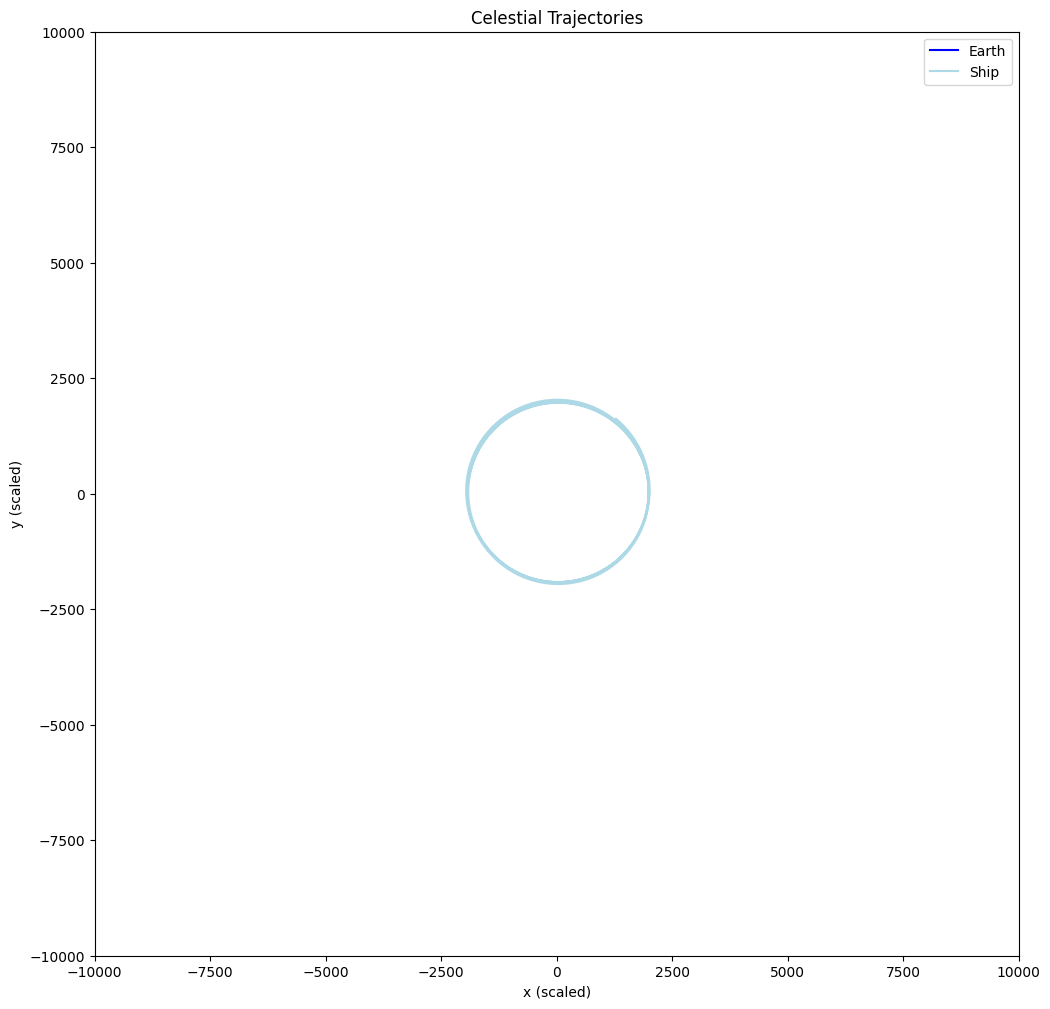

Episode  530 | Return:  2.108e+00 | Loss:  1.862e+01


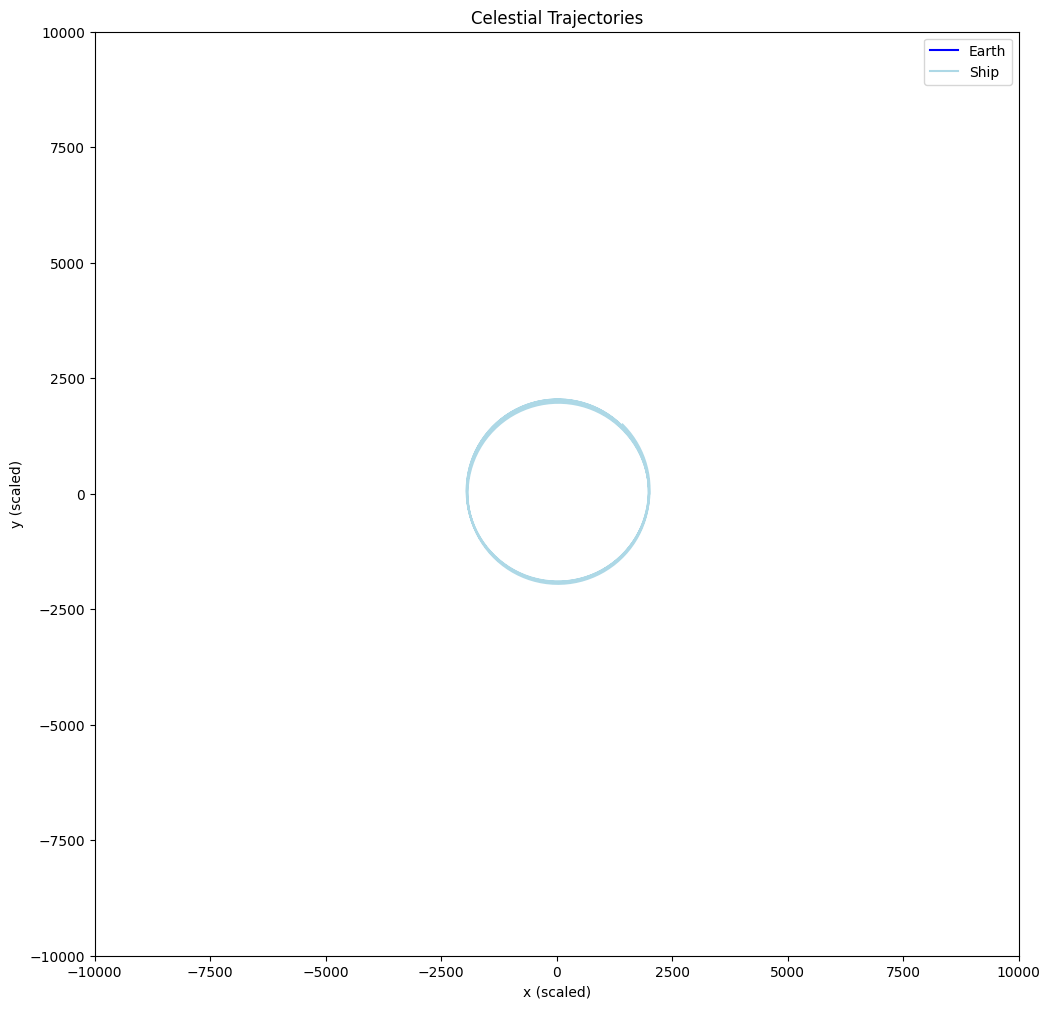

Episode  540 | Return:  2.104e+00 | Loss:  2.385e+01


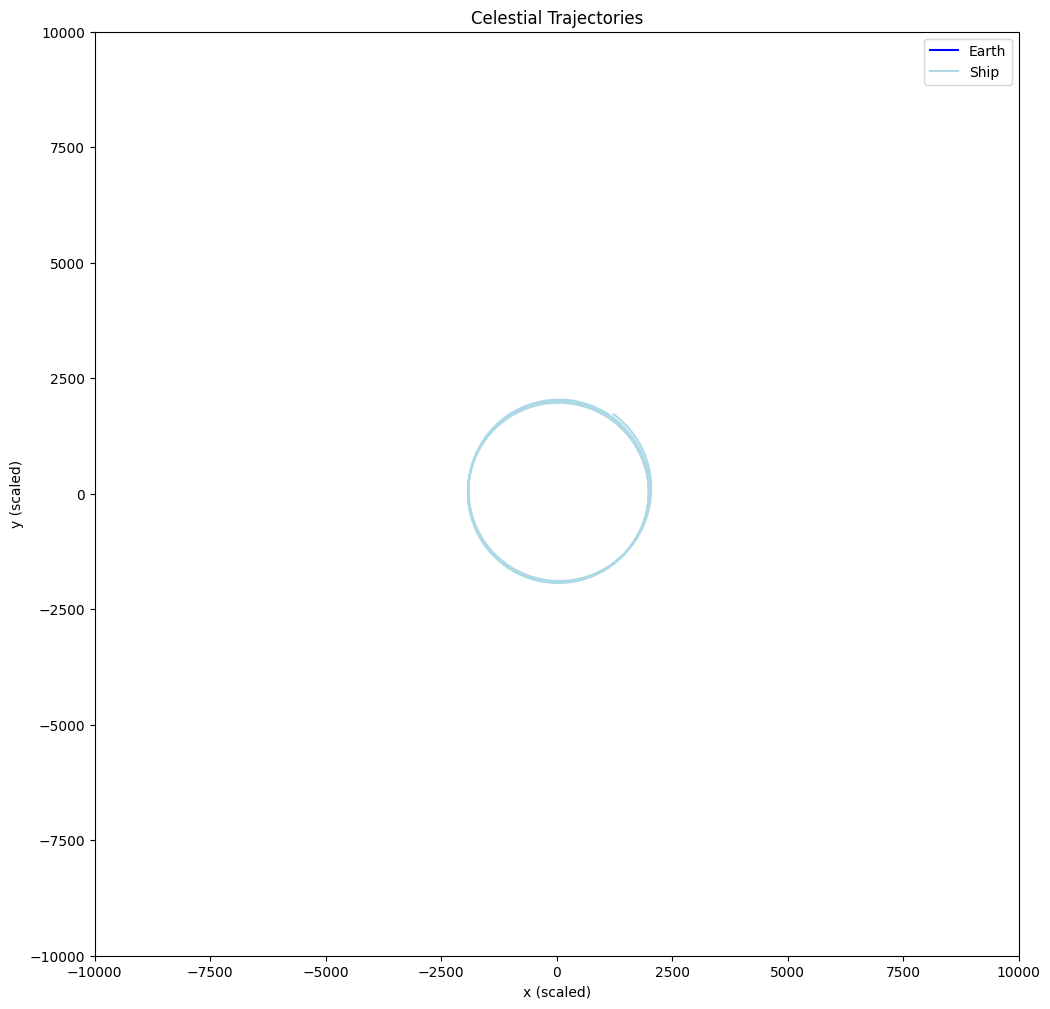

Episode  550 | Return:  2.110e+00 | Loss: -7.920e+00


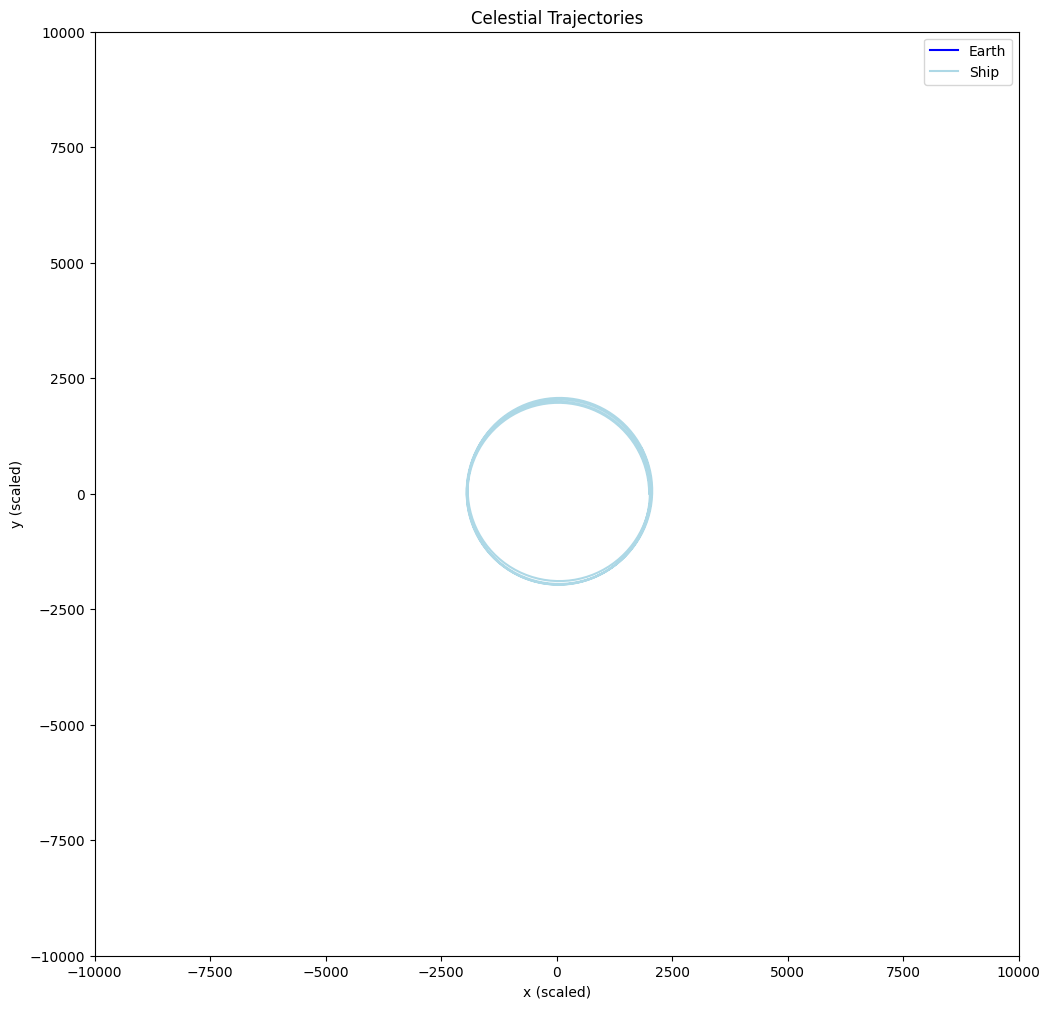

Episode  560 | Return:  2.102e+00 | Loss: -6.633e+01


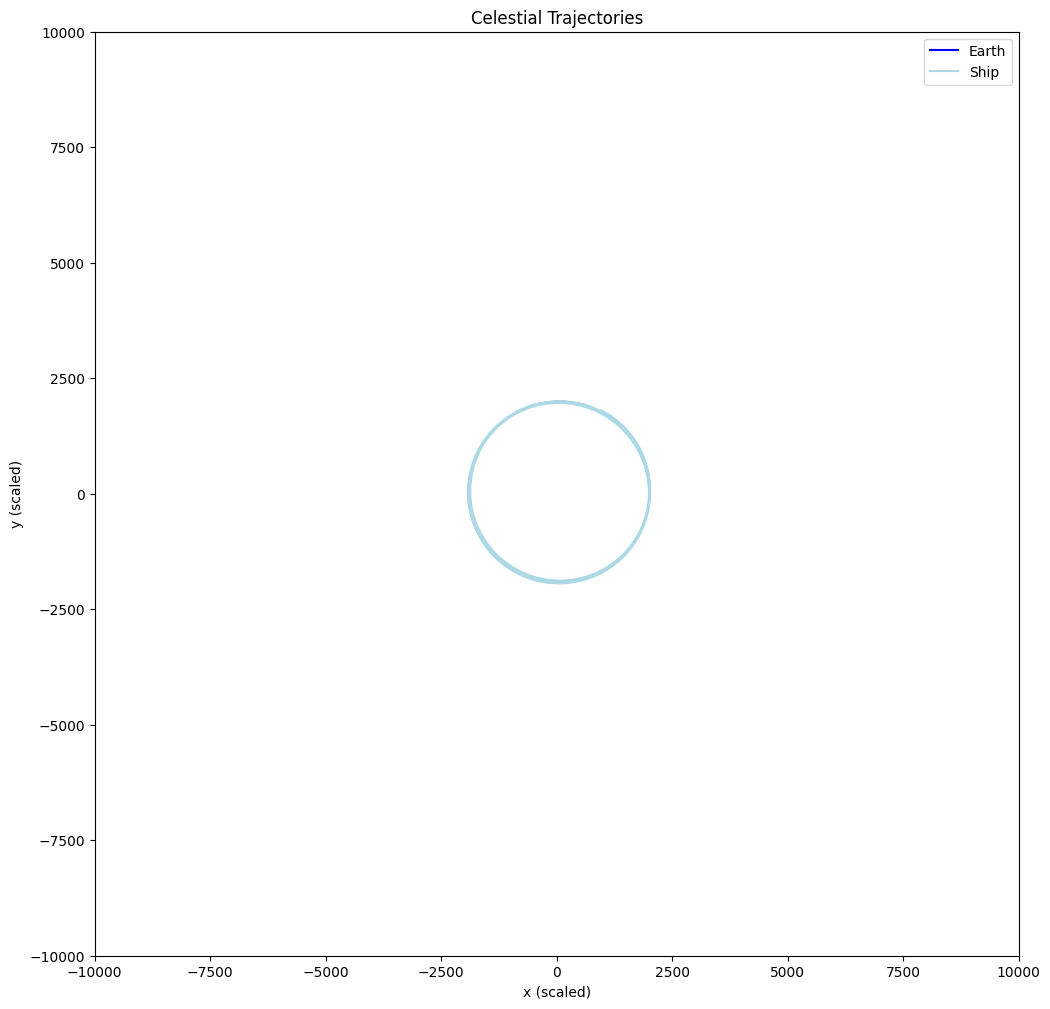

Episode  570 | Return:  2.109e+00 | Loss:  1.589e+01


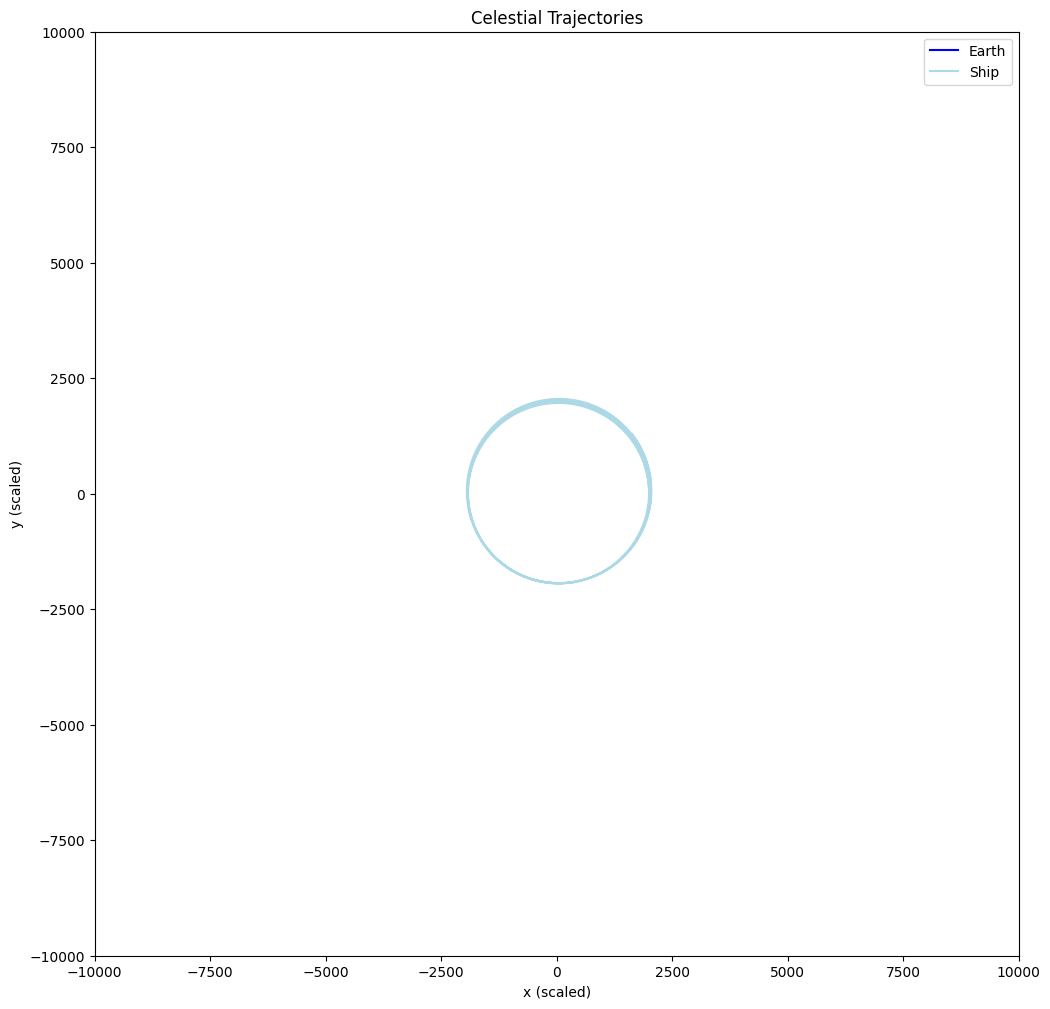

Episode  580 | Return:  2.119e+00 | Loss:  1.918e+01


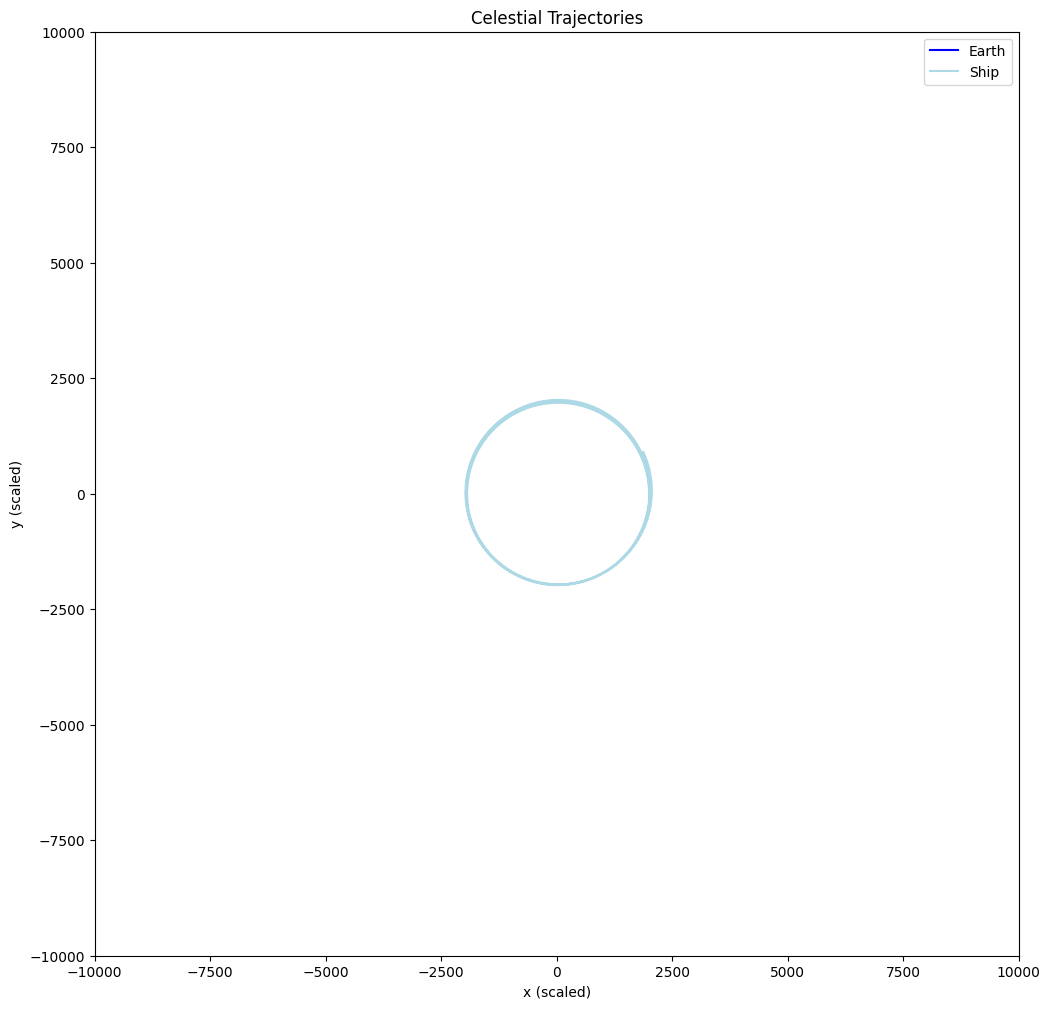

Episode  590 | Return:  2.115e+00 | Loss:  2.467e+01


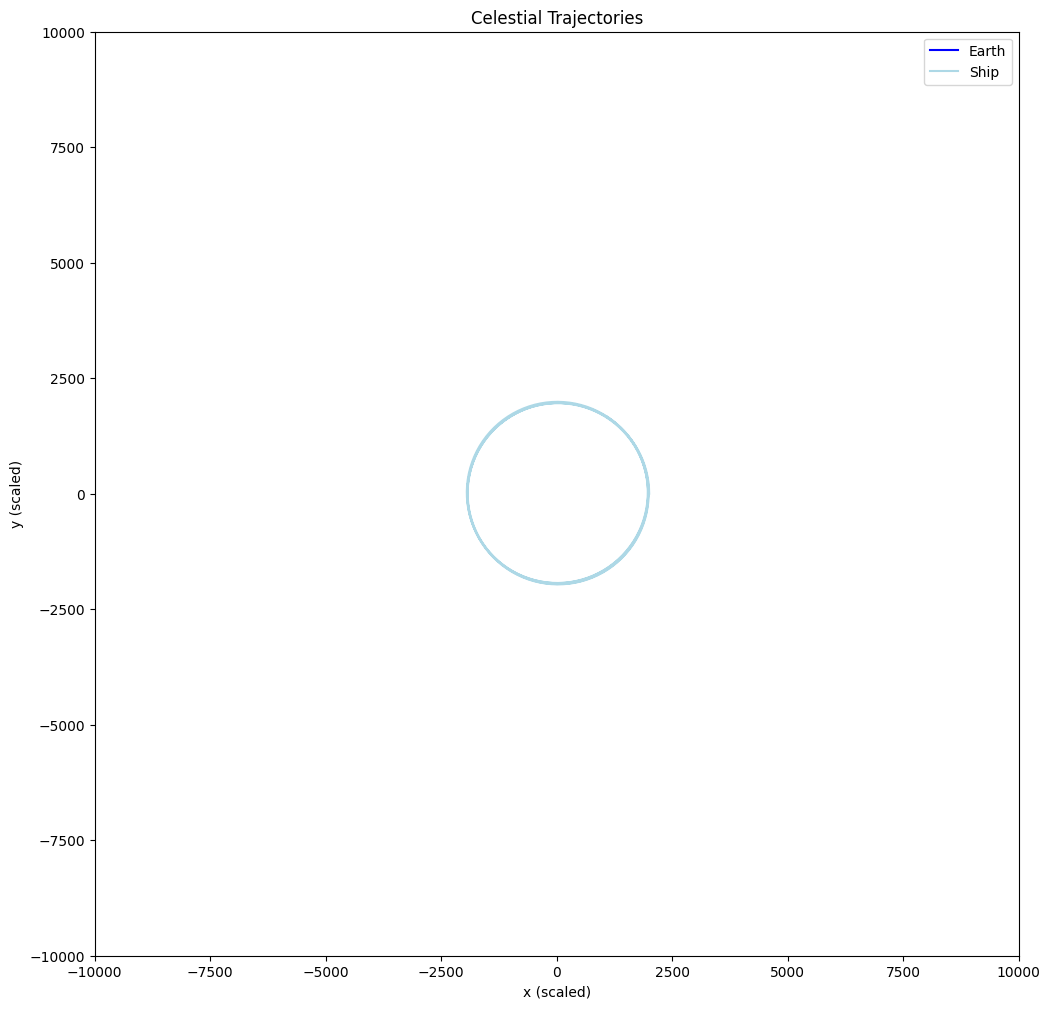

Episode  600 | Return:  2.103e+00 | Loss:  2.362e+00


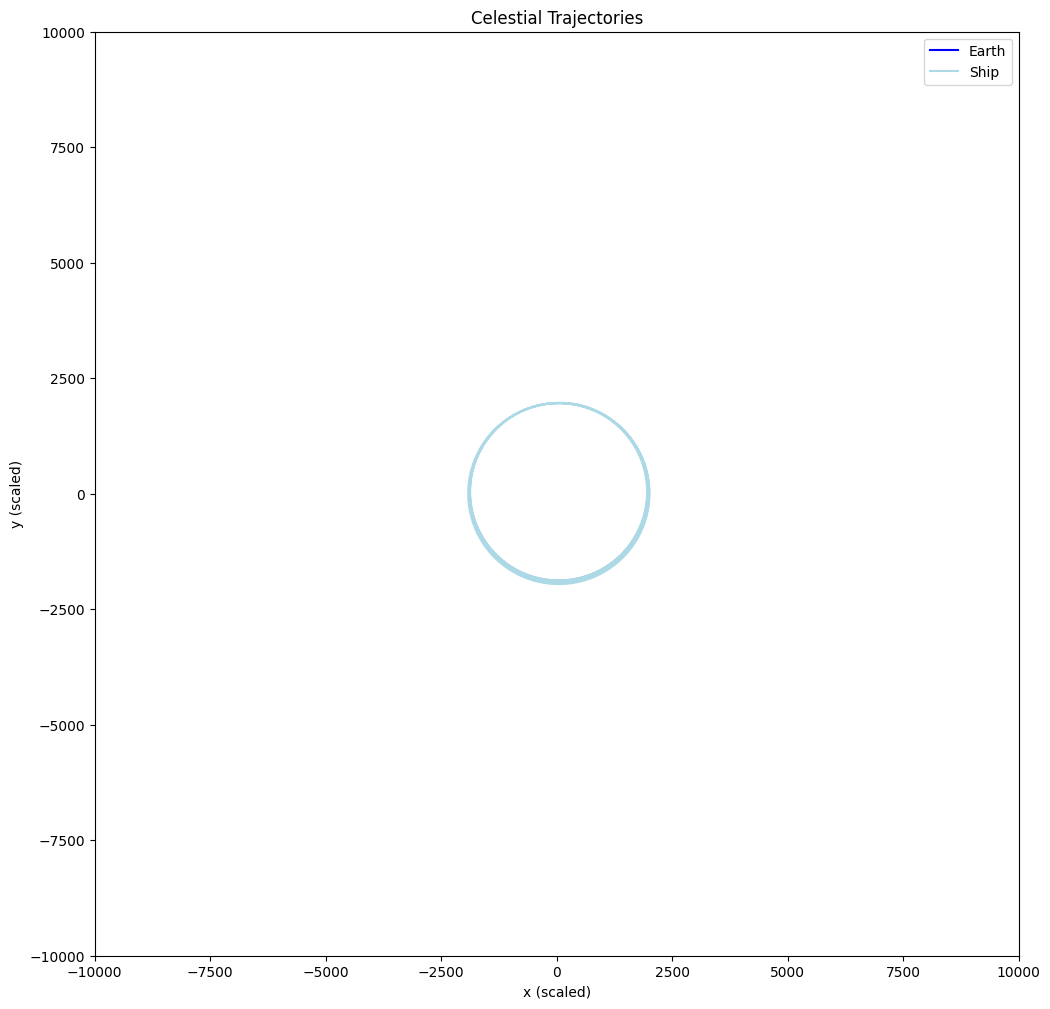

Episode  610 | Return:  2.107e+00 | Loss: -3.662e+01


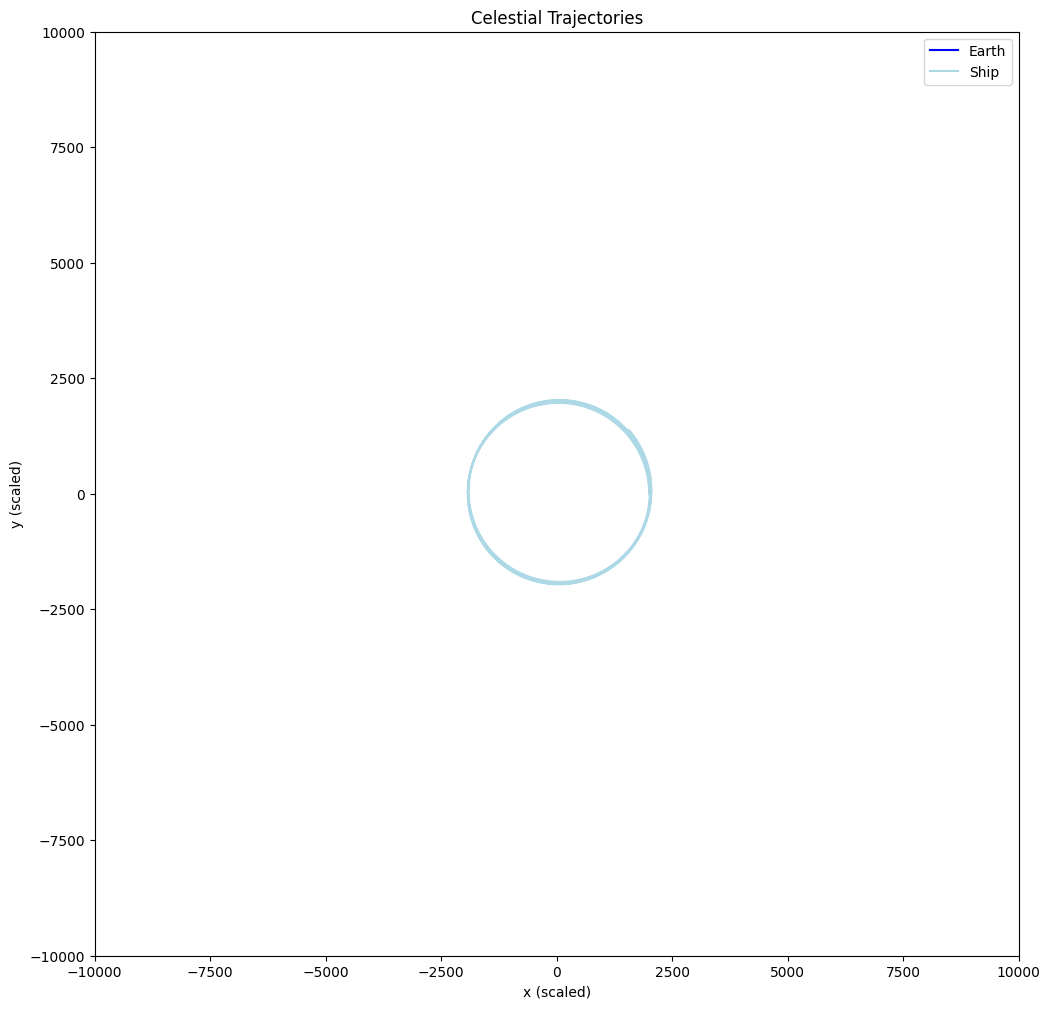

Episode  620 | Return:  2.105e+00 | Loss:  2.137e+01


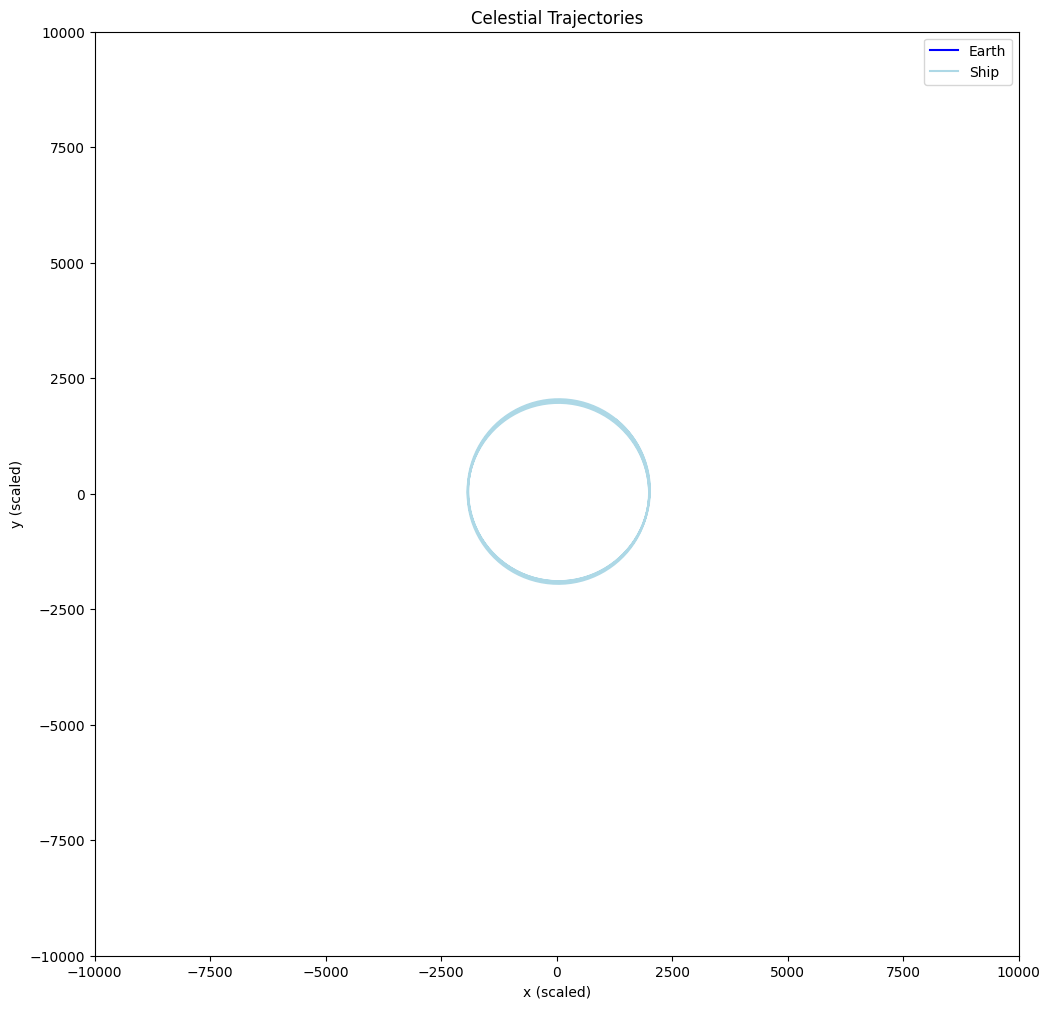

Episode  630 | Return:  2.113e+00 | Loss:  2.006e+01


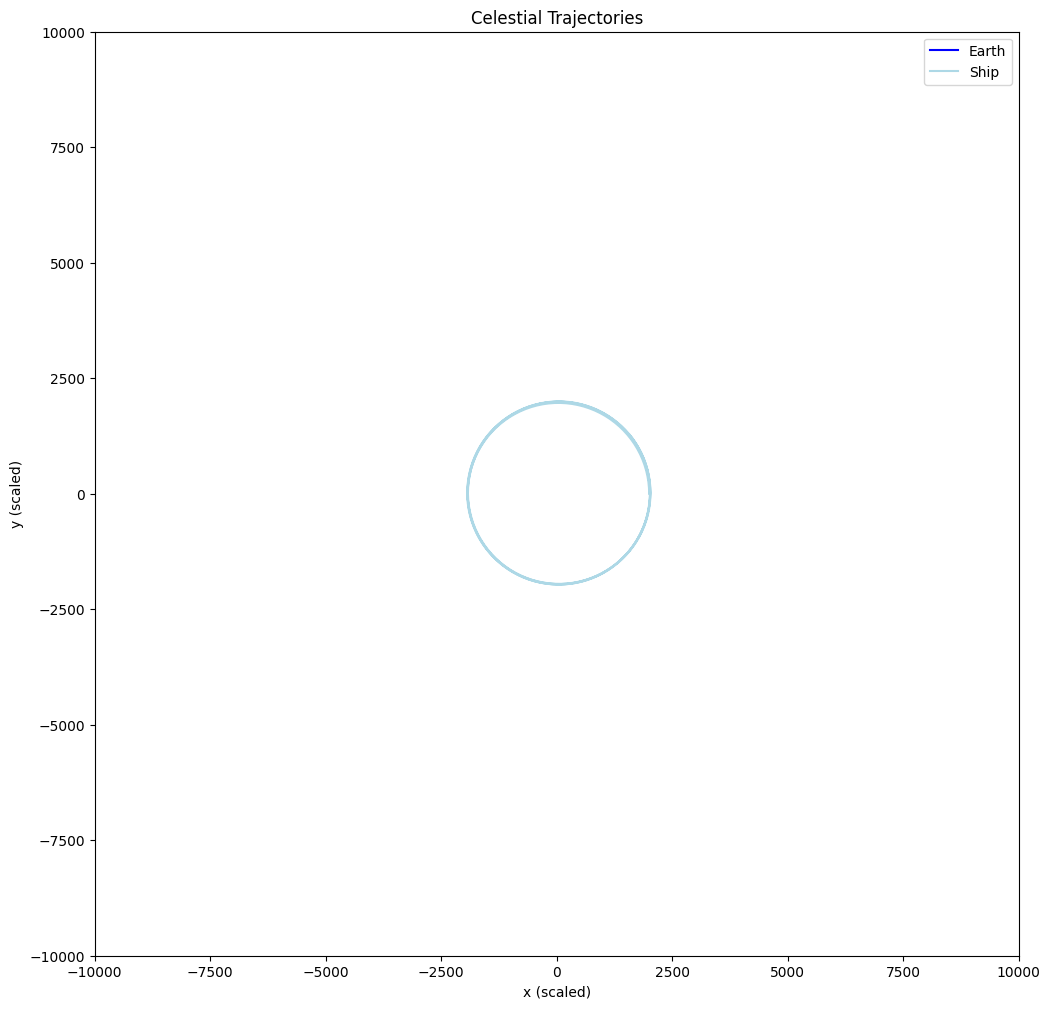

Episode  640 | Return:  2.113e+00 | Loss:  1.864e+01


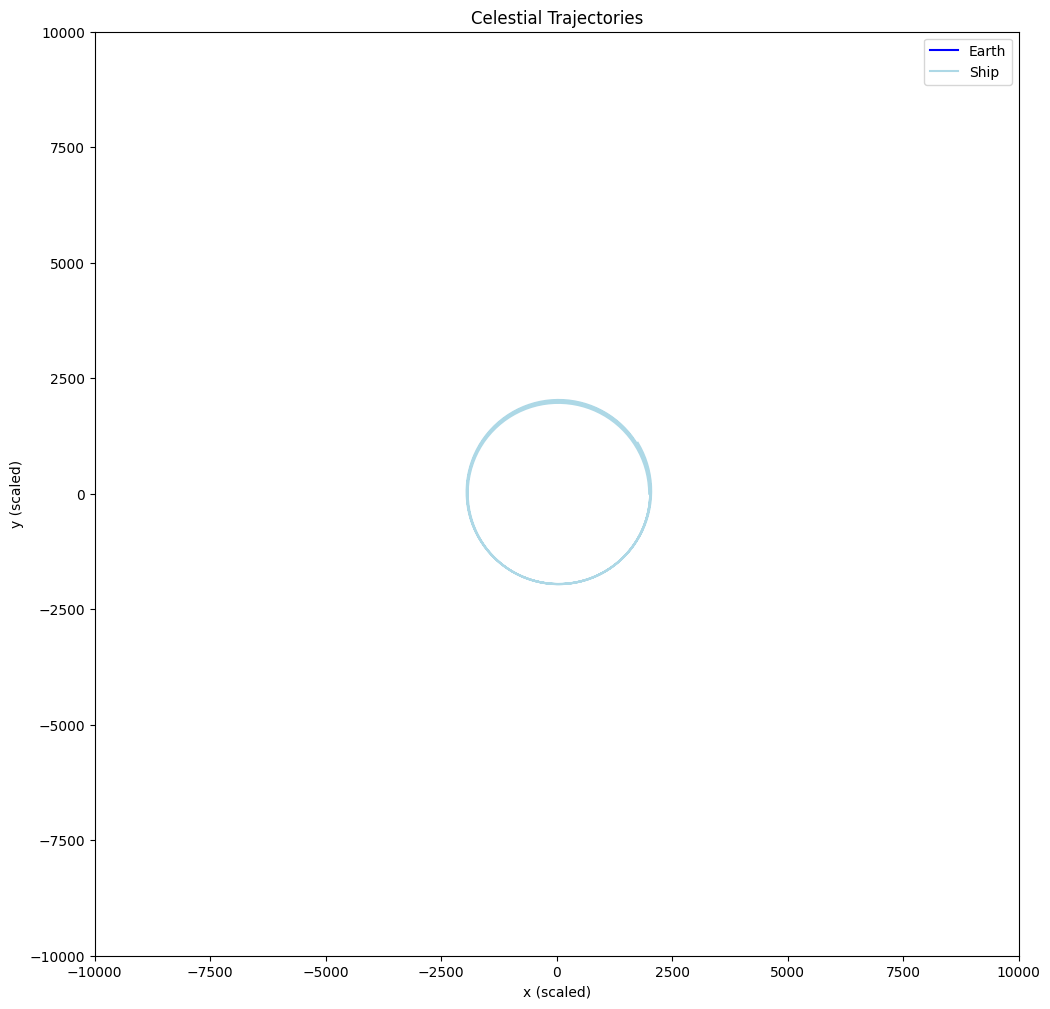

Episode  650 | Return:  2.110e+00 | Loss:  3.329e+01


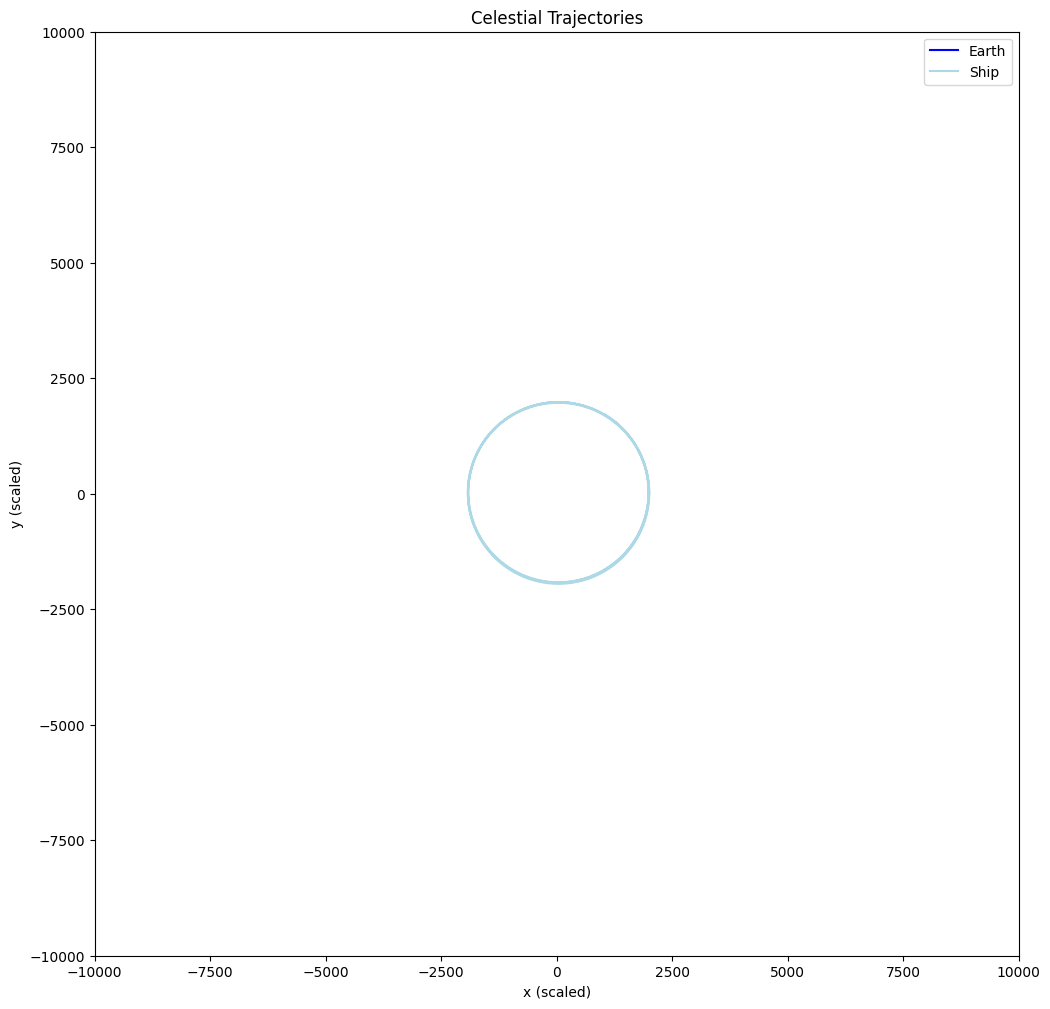

Episode  660 | Return:  2.111e+00 | Loss:  8.875e+00


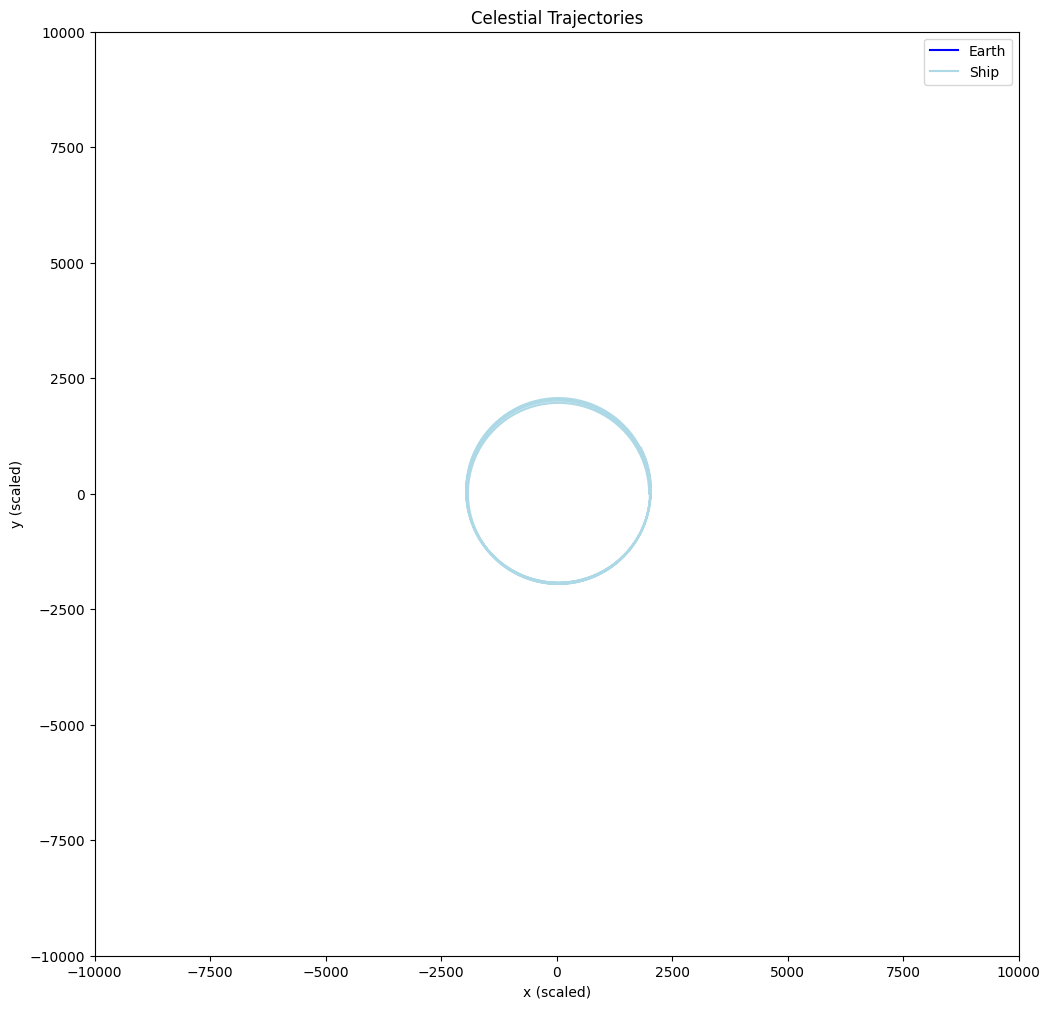

Episode  670 | Return:  2.104e+00 | Loss:  2.477e+01


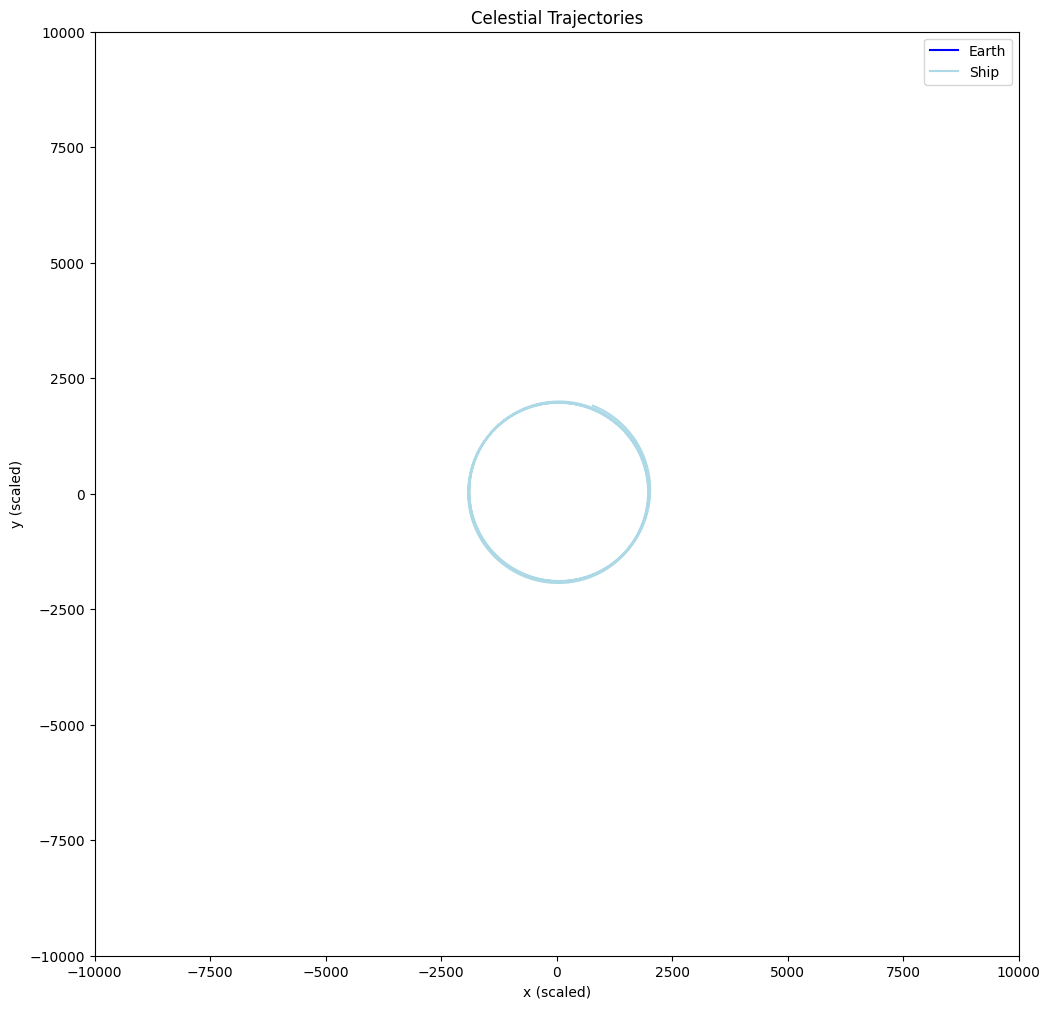

Episode  680 | Return:  2.113e+00 | Loss: -1.295e+01


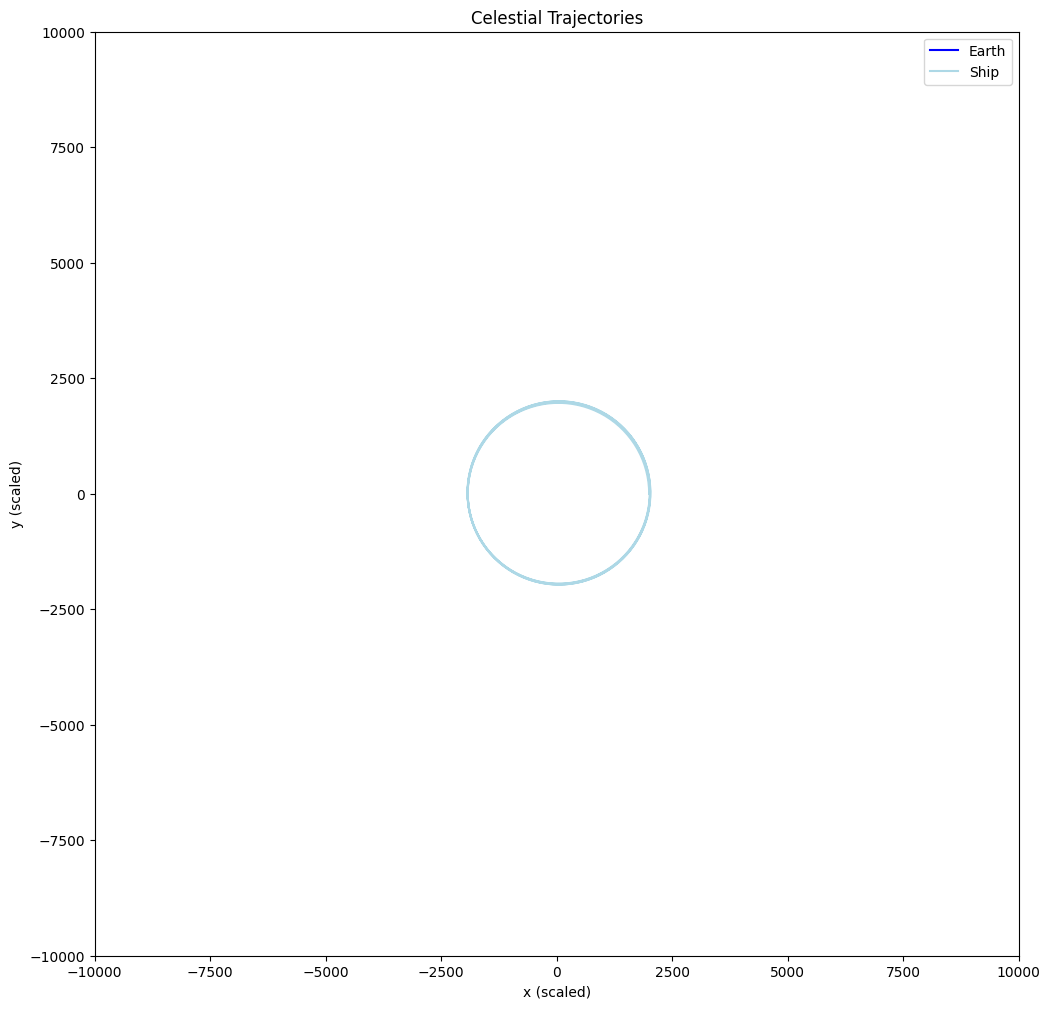

Episode  690 | Return:  2.113e+00 | Loss: -3.470e+01


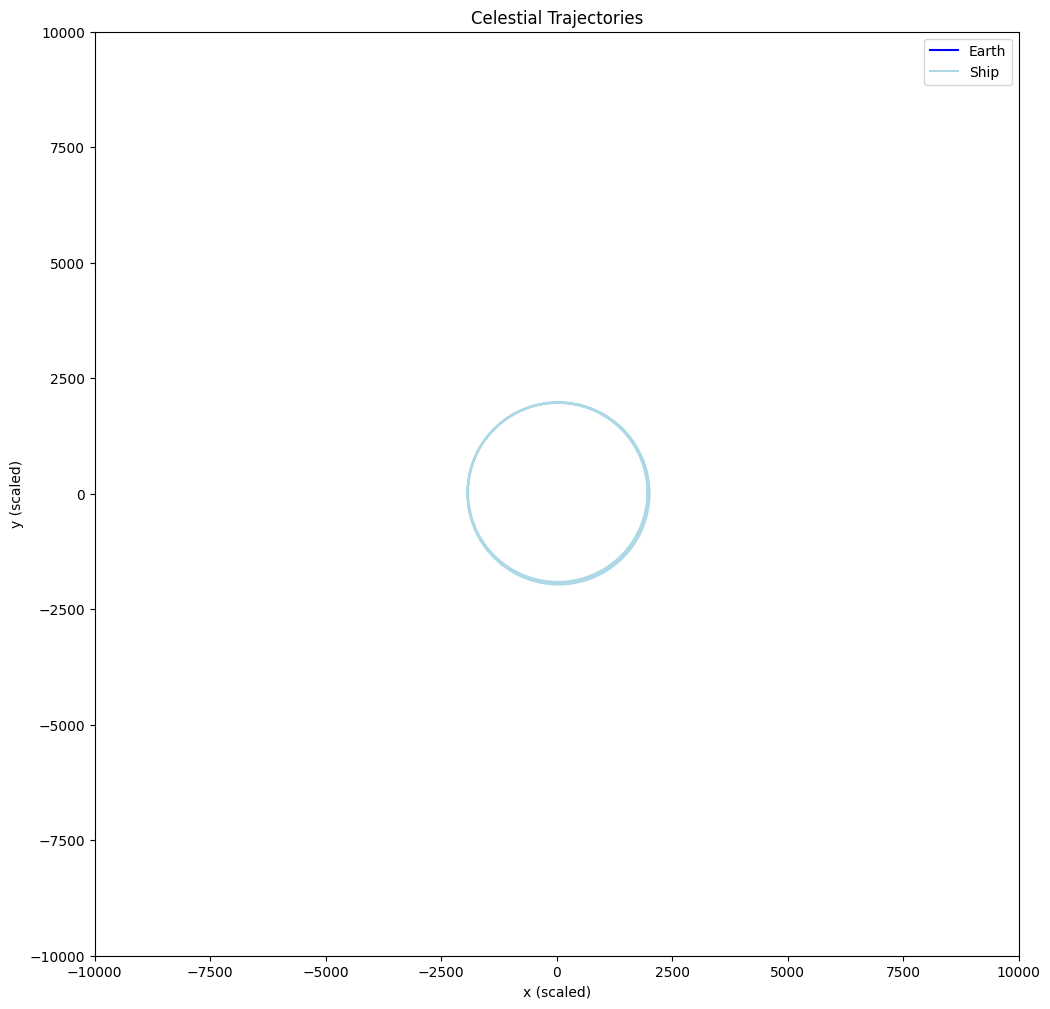

Episode  700 | Return:  2.114e+00 | Loss:  1.571e+01


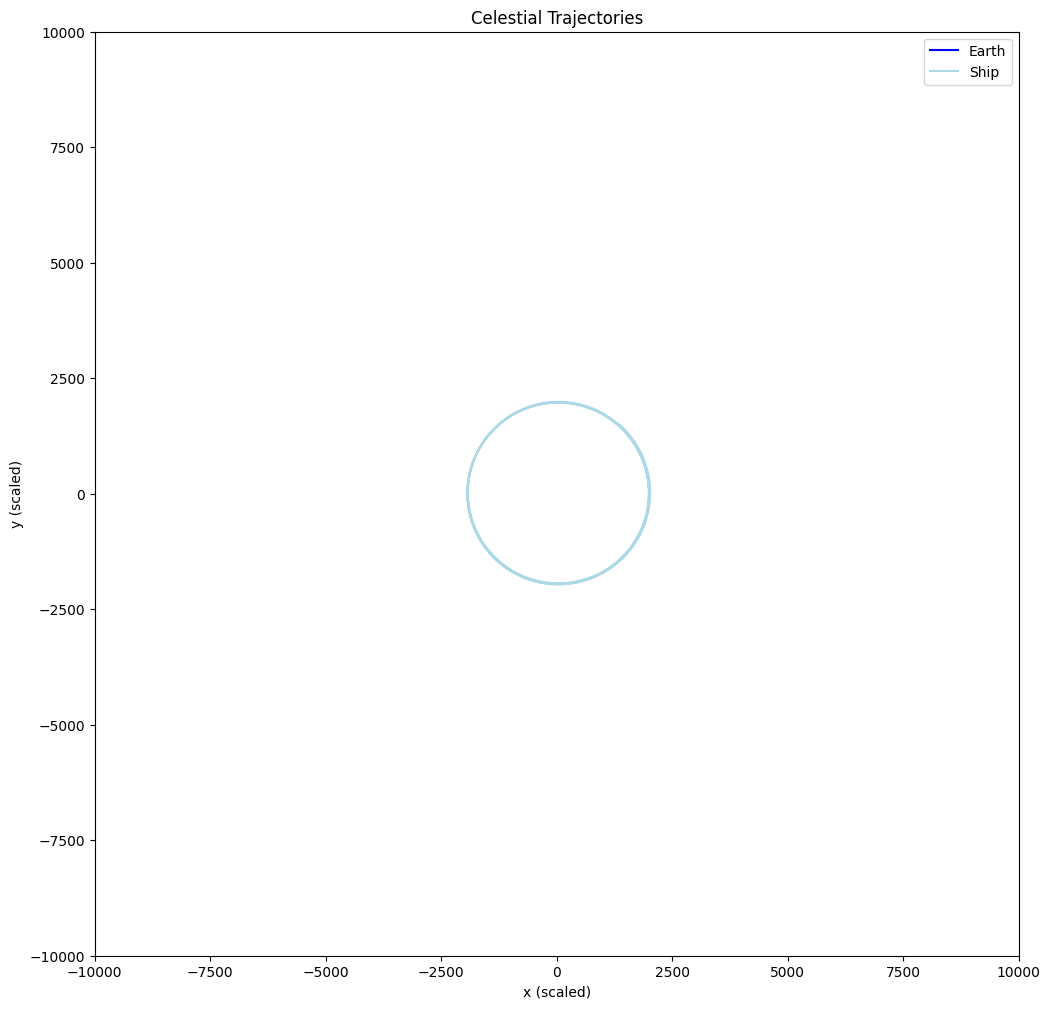

Episode  710 | Return:  2.111e+00 | Loss: -8.200e+01


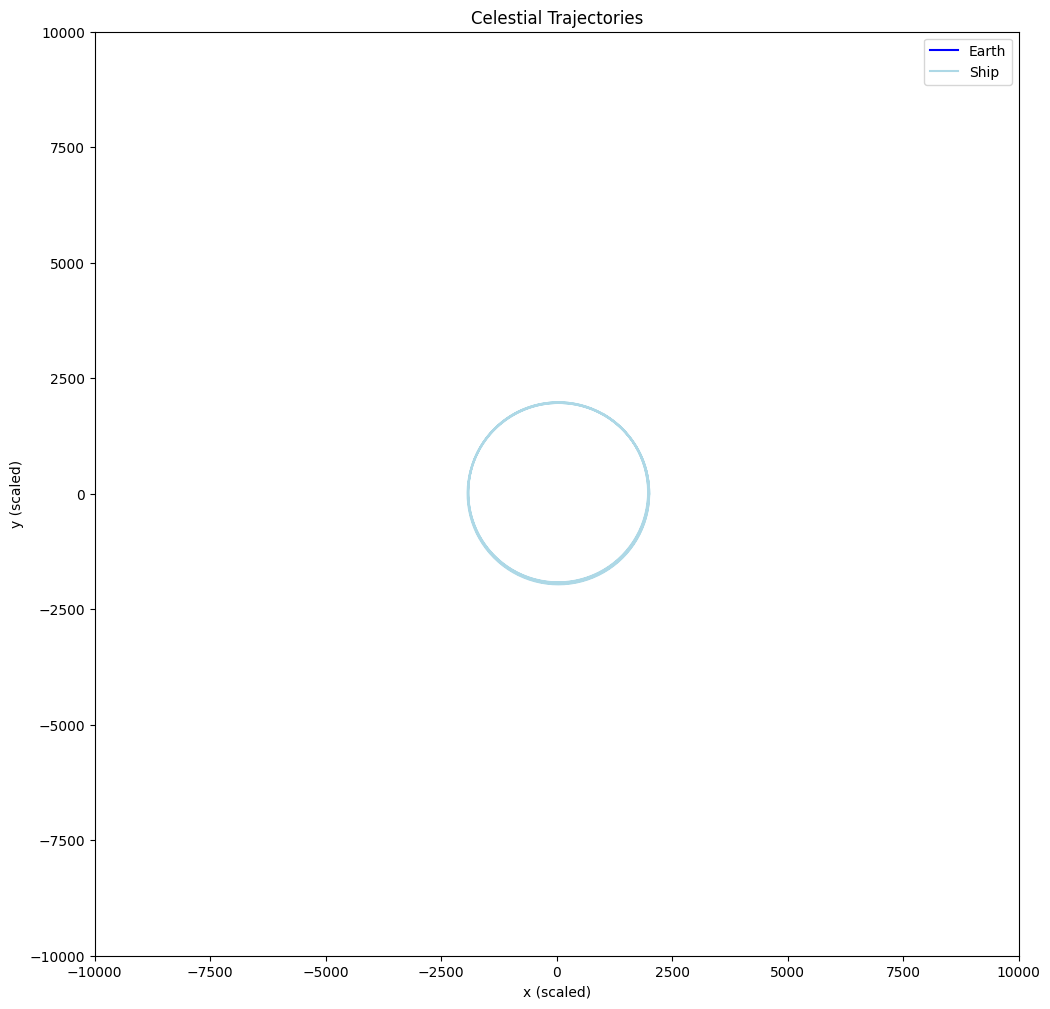

Episode  720 | Return:  2.115e+00 | Loss:  5.813e+00


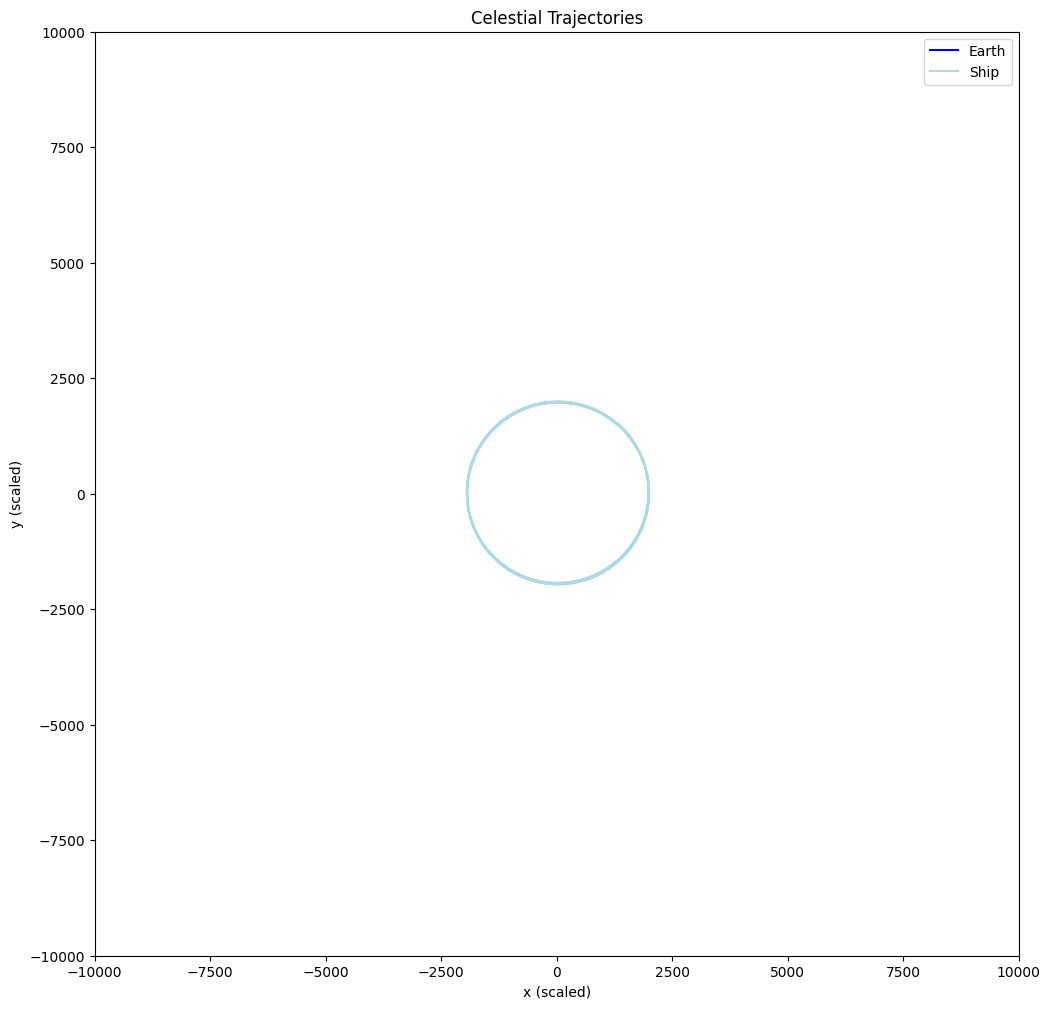

Episode  730 | Return:  2.111e+00 | Loss: -1.744e+02


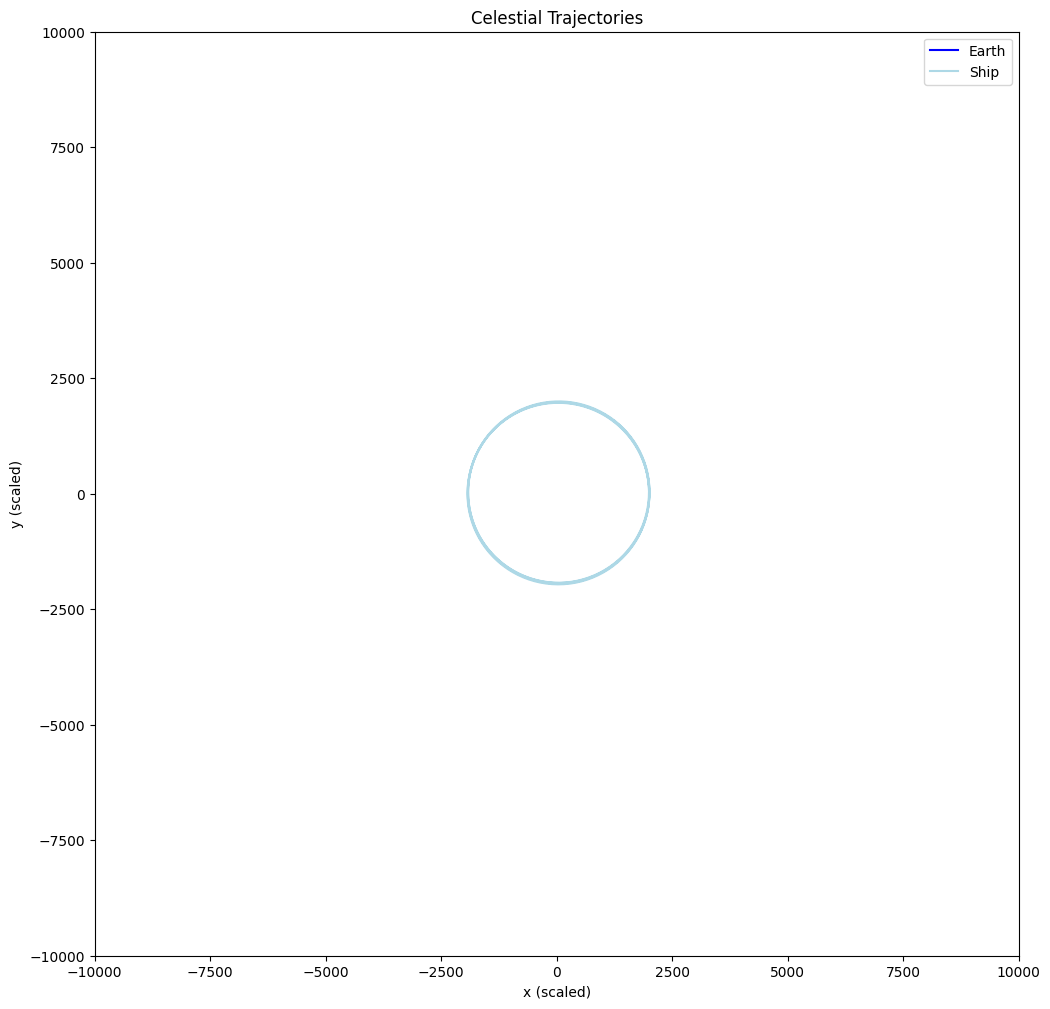

Episode  740 | Return:  2.113e+00 | Loss: -8.916e-01


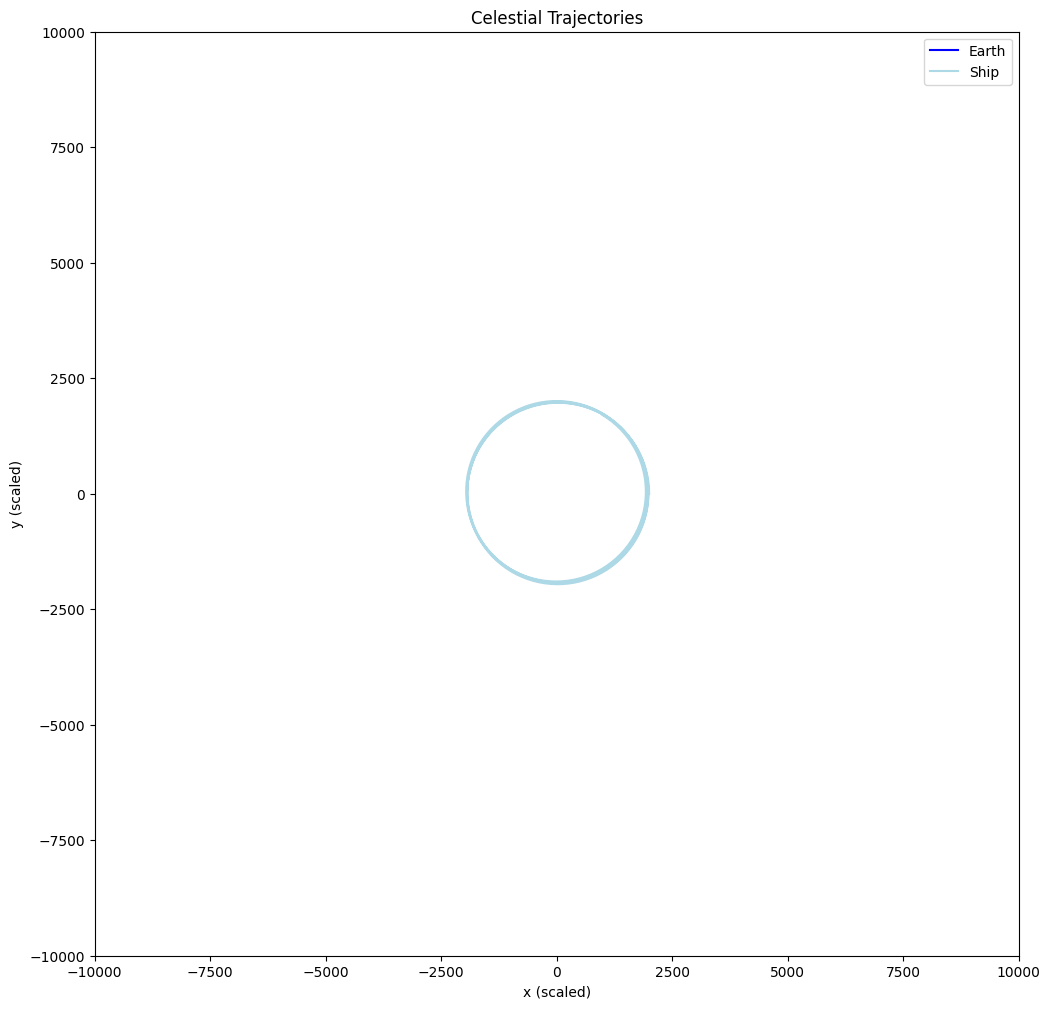

Episode  750 | Return:  2.116e+00 | Loss:  1.996e+01


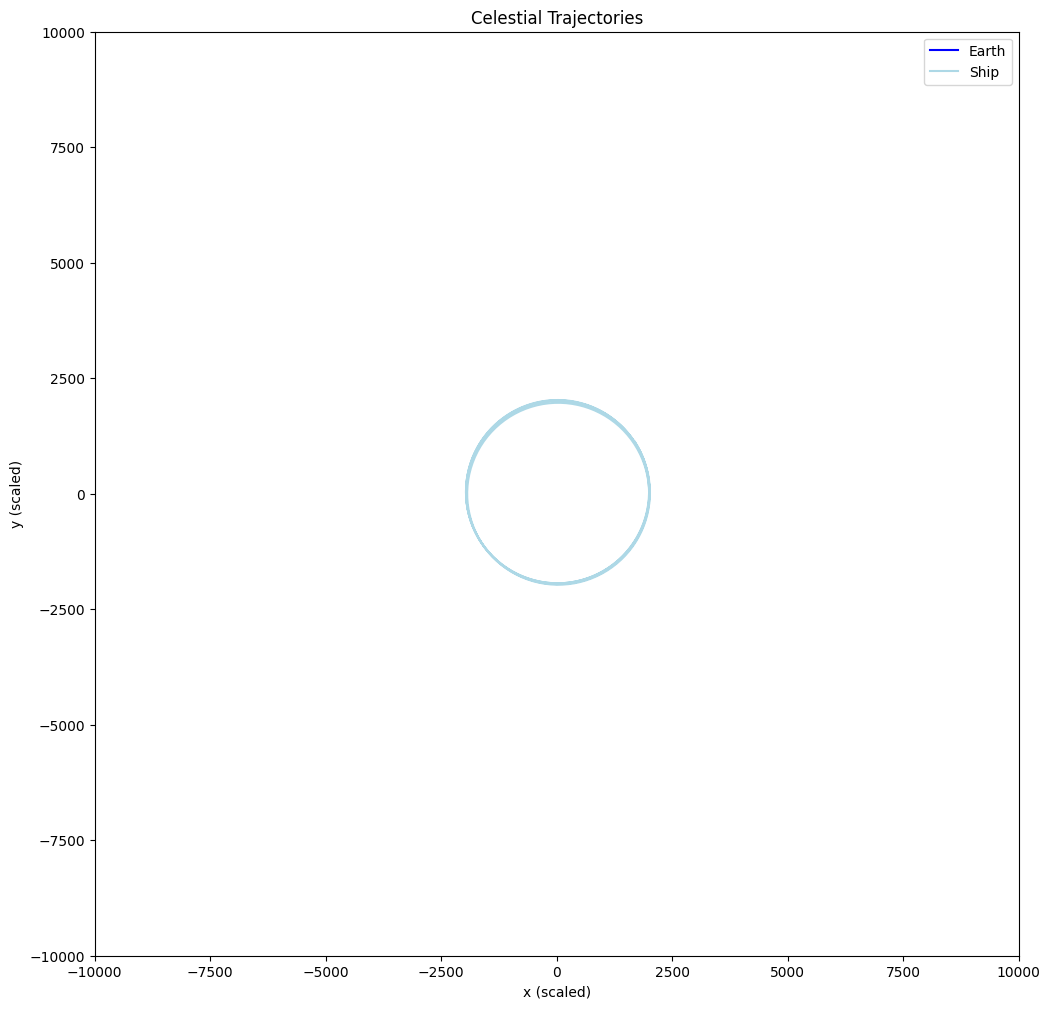

Episode  760 | Return:  2.116e+00 | Loss: -9.910e+01


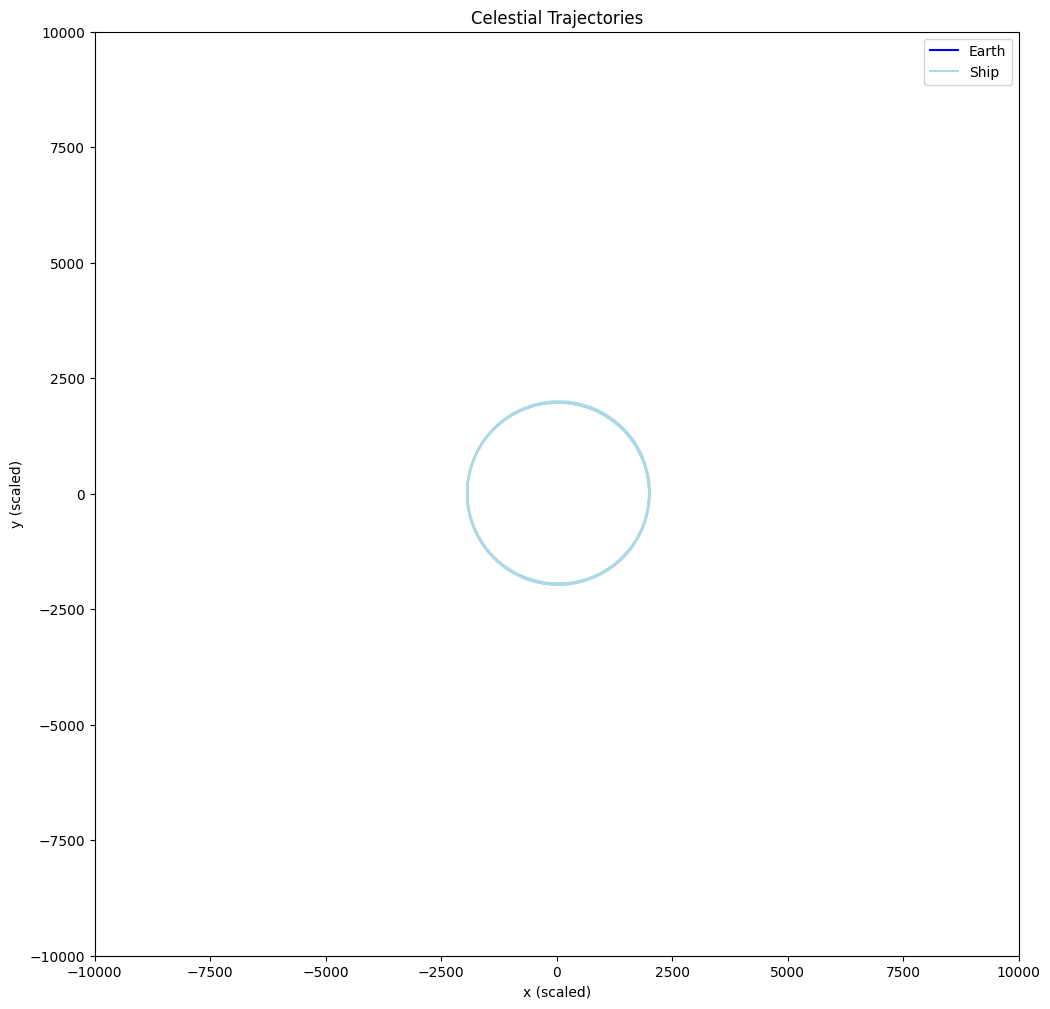

Episode  770 | Return:  2.115e+00 | Loss: -3.221e+01


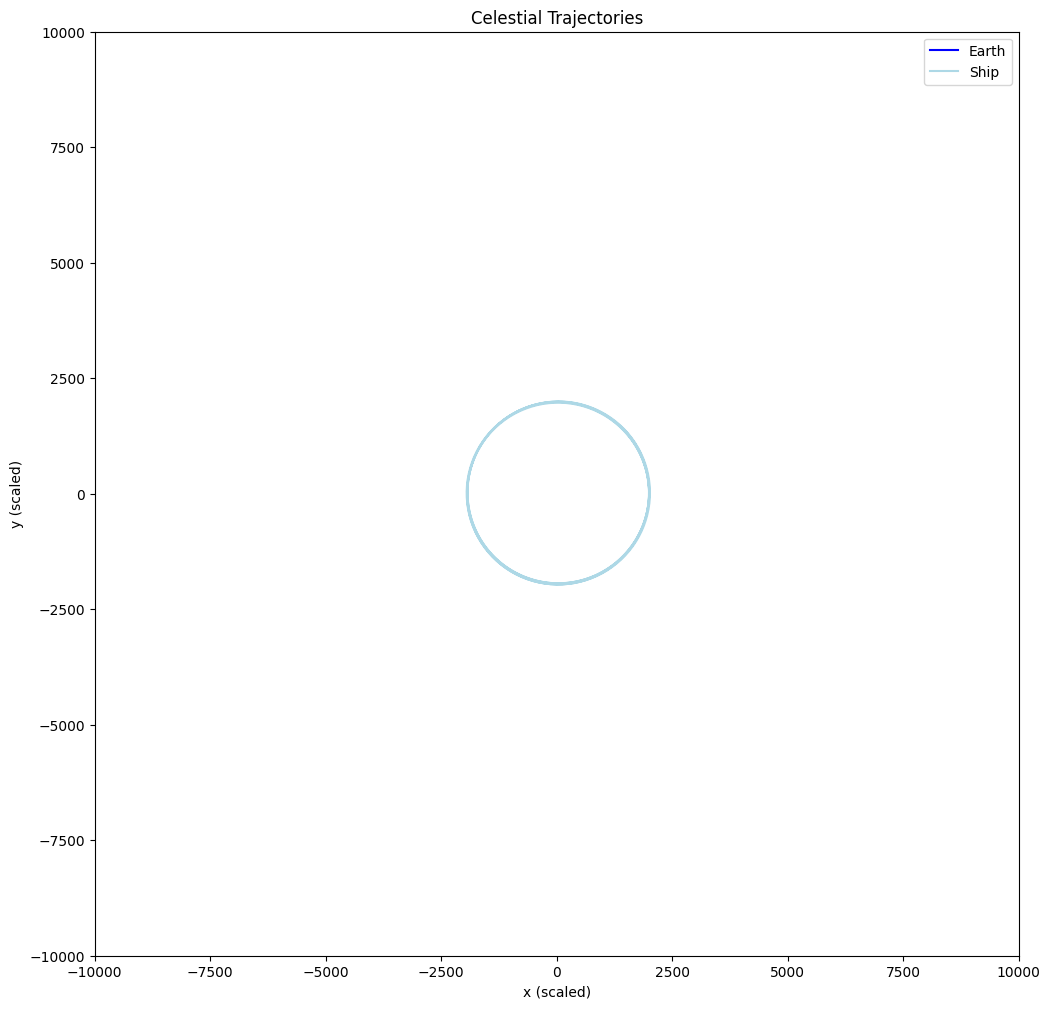

Episode  780 | Return:  2.115e+00 | Loss:  9.848e+00


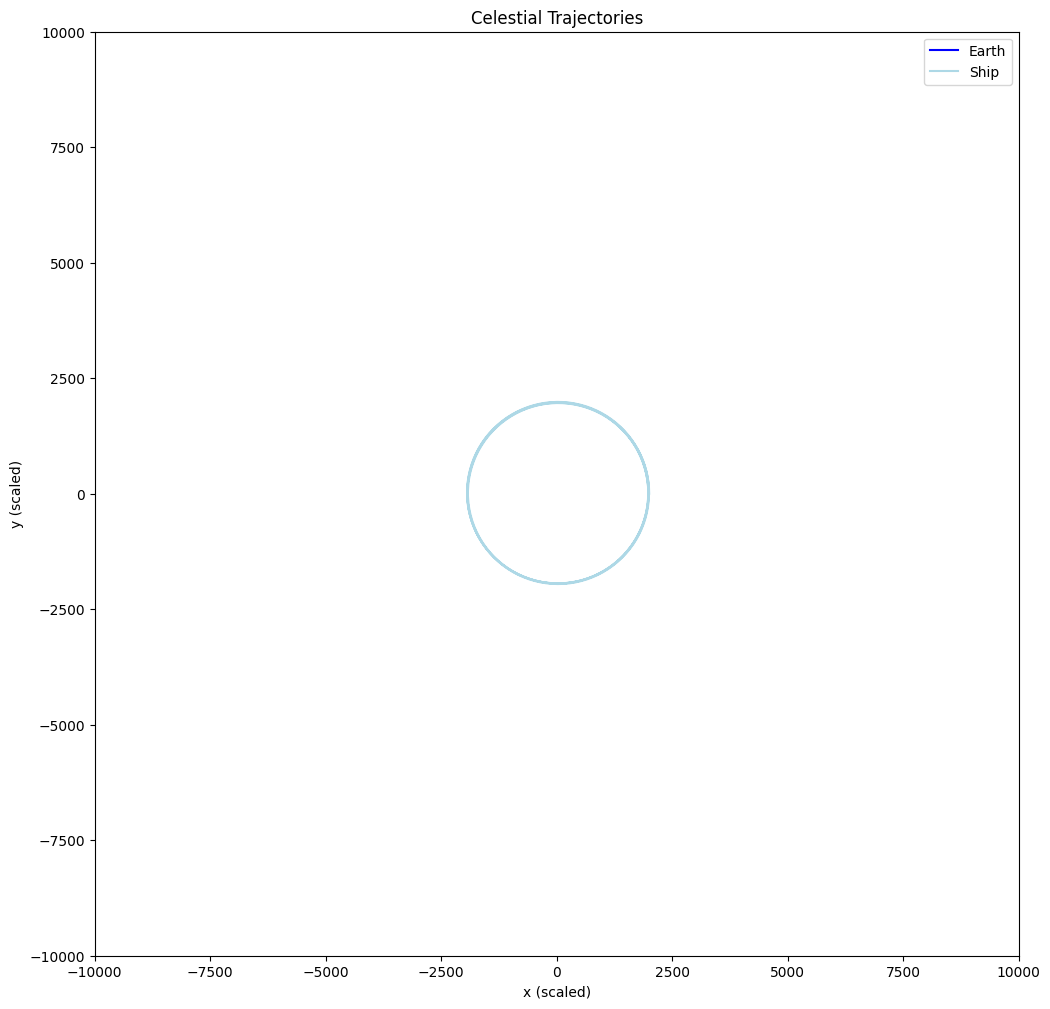

Episode  790 | Return:  2.112e+00 | Loss: -8.564e+01


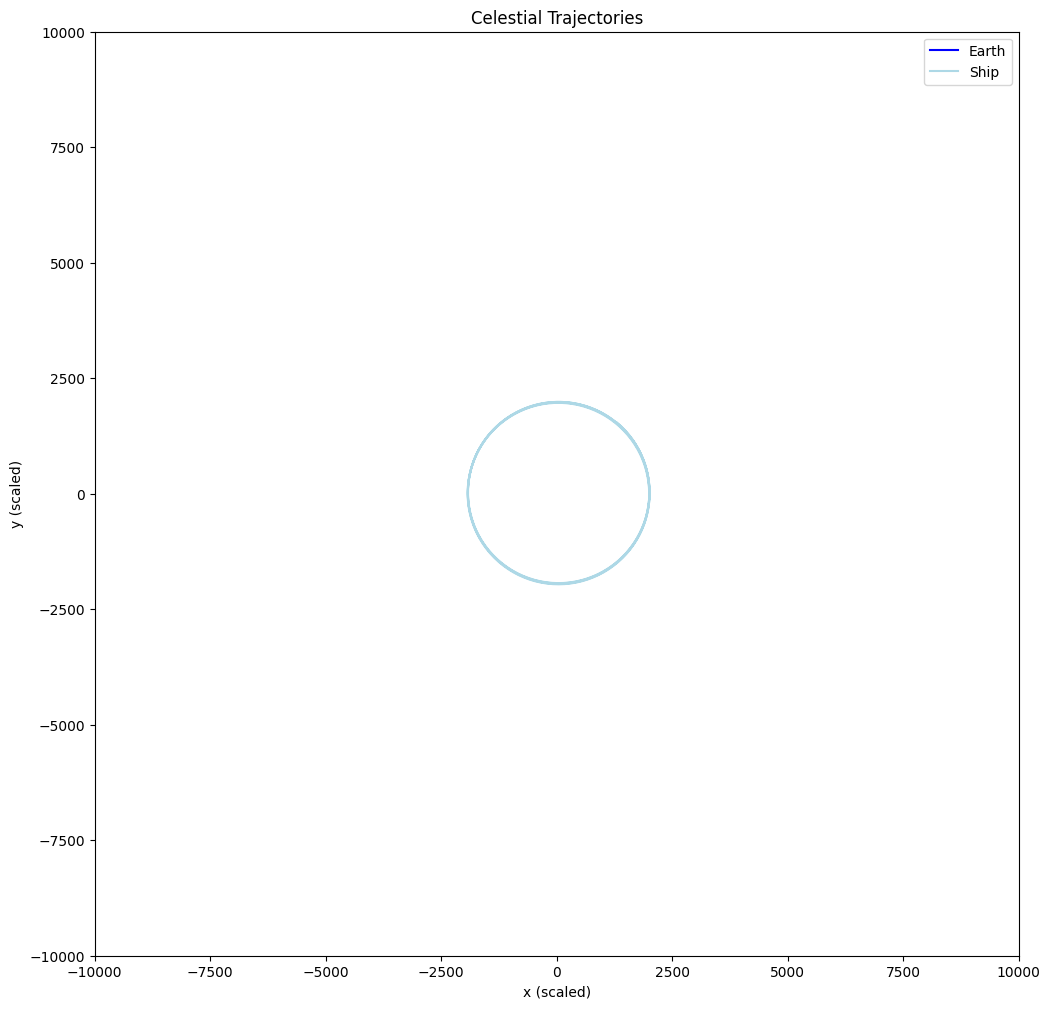

Episode  800 | Return:  2.118e+00 | Loss:  1.278e+01


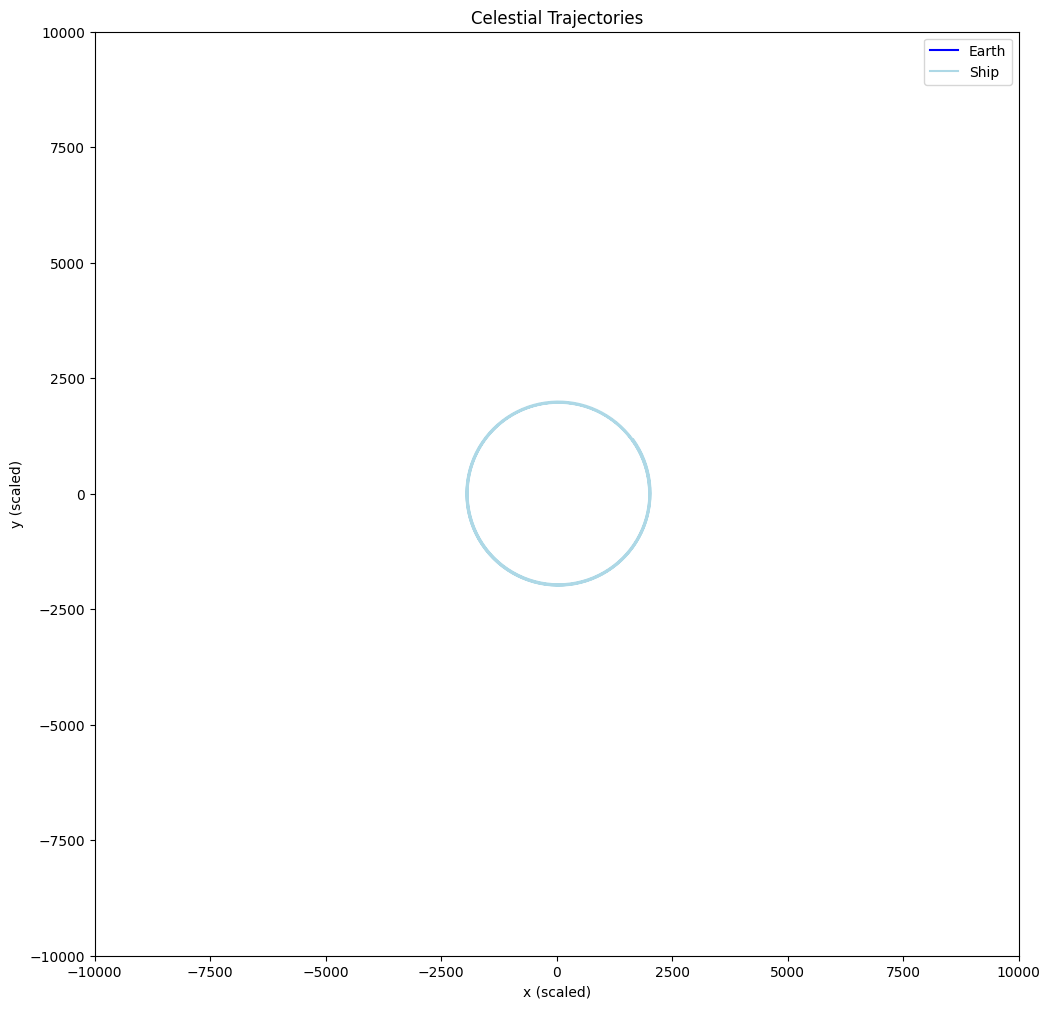

Episode  810 | Return:  2.114e+00 | Loss: -3.647e+01


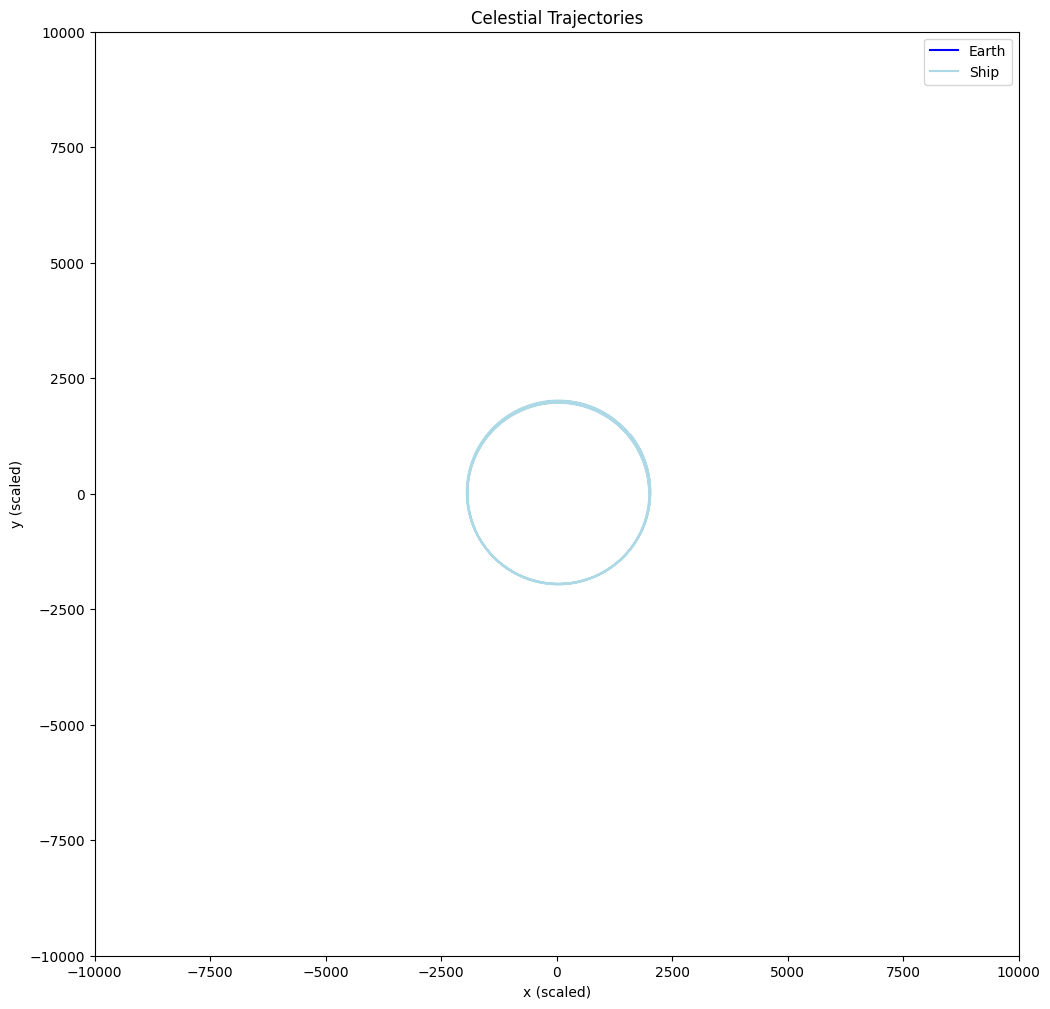

Episode  820 | Return:  2.115e+00 | Loss:  1.605e+01


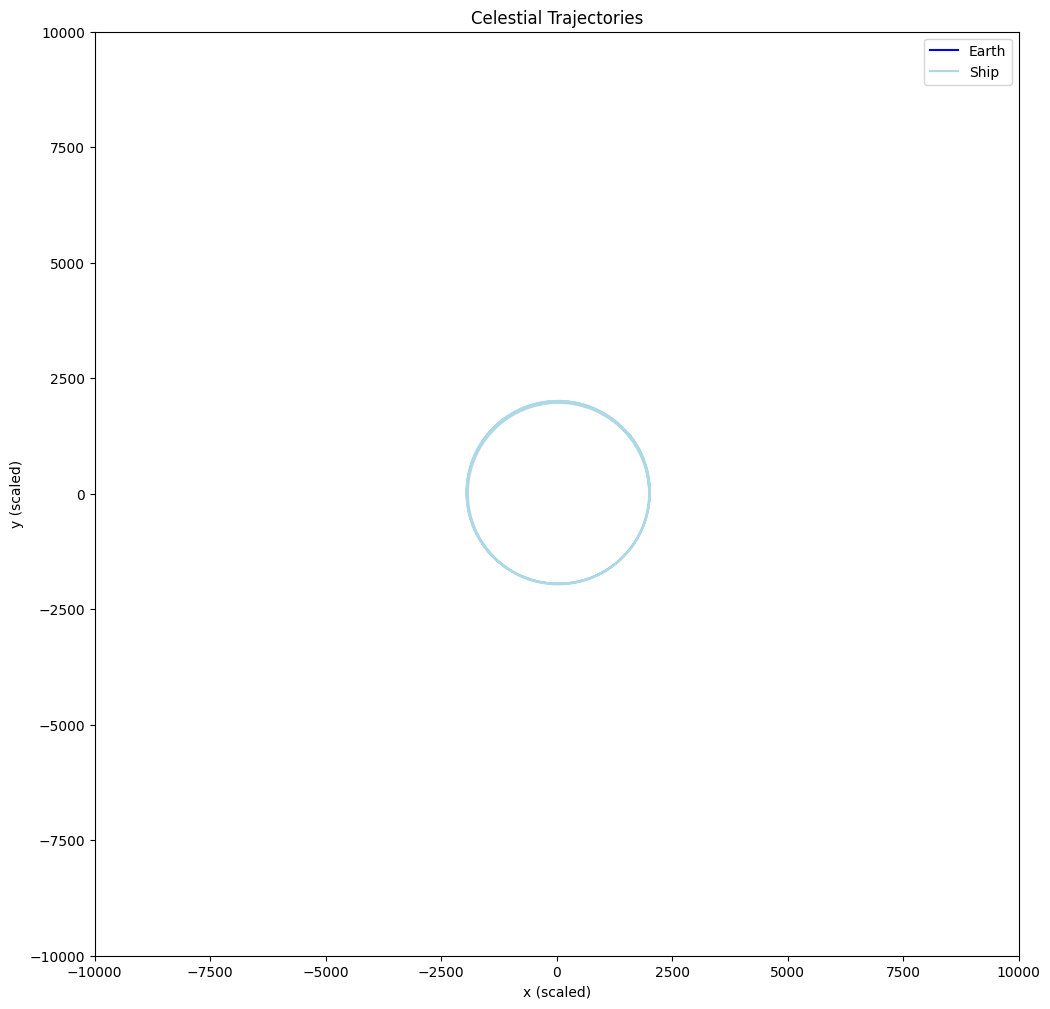

Episode  830 | Return:  2.115e+00 | Loss:  6.231e+00


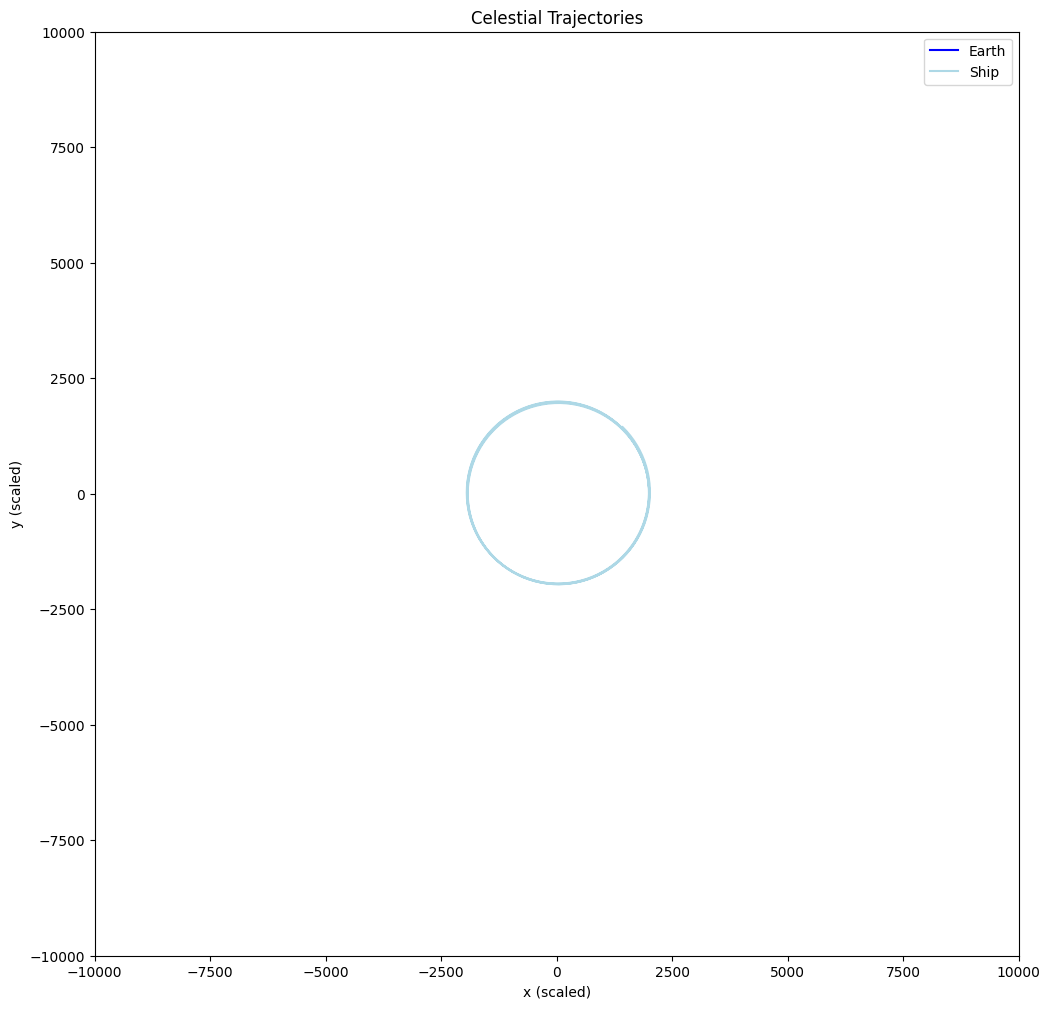

Episode  840 | Return:  2.116e+00 | Loss:  1.055e+01


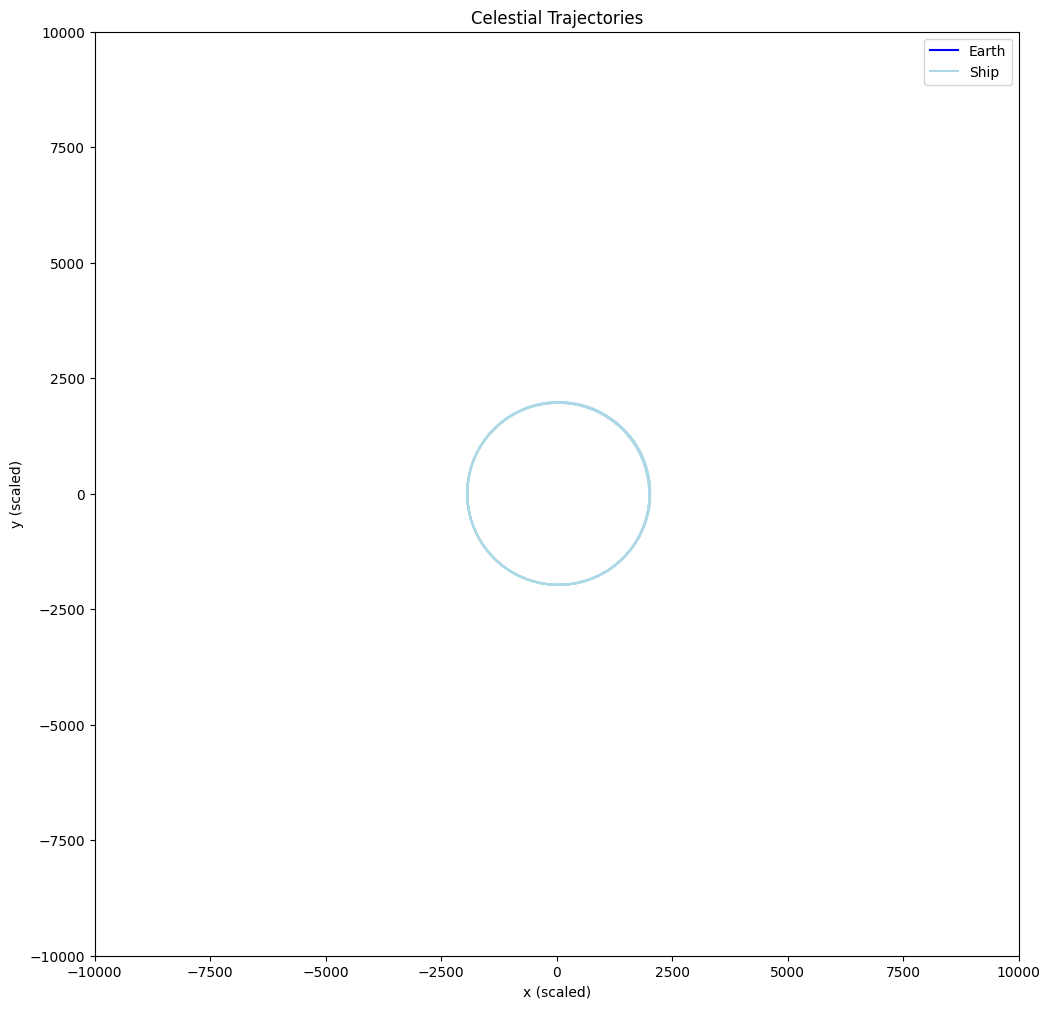

Episode  850 | Return:  2.115e+00 | Loss: -1.785e+01


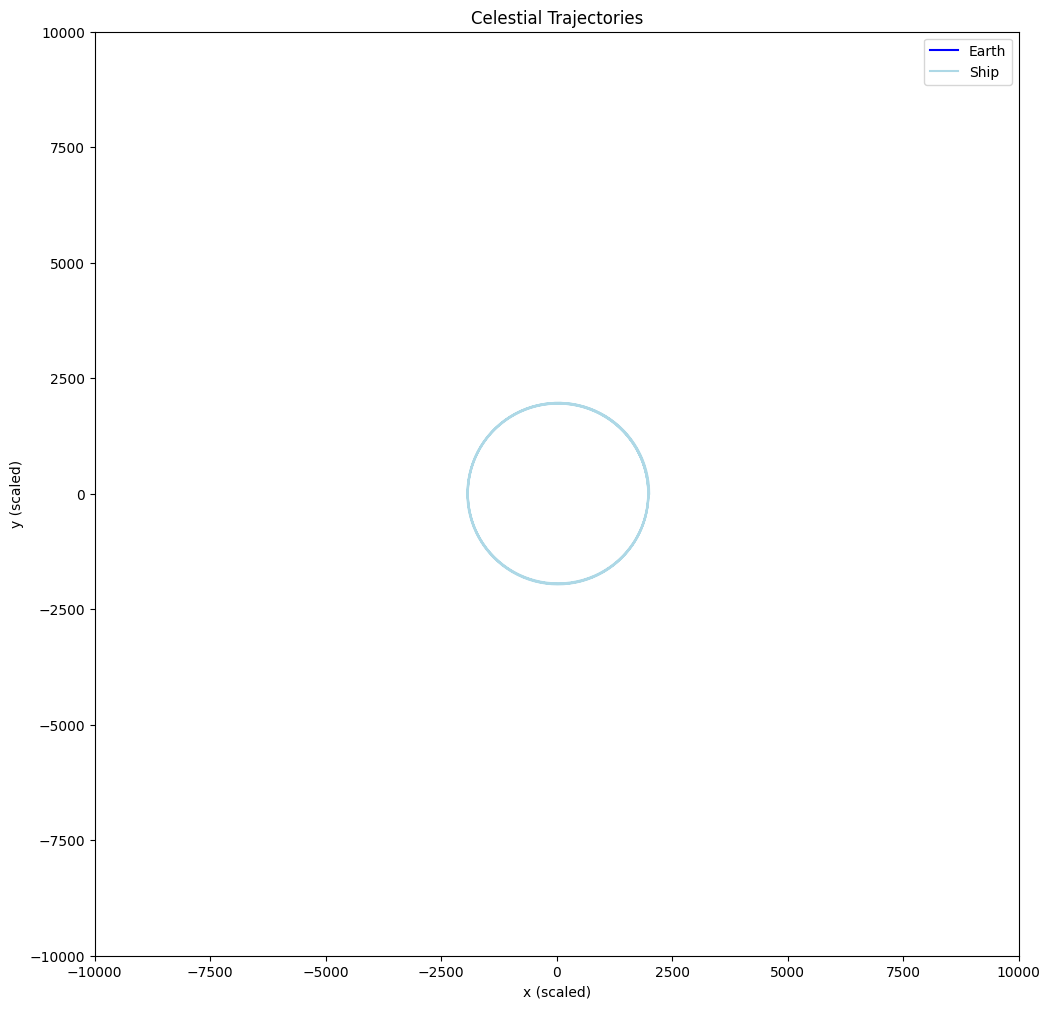

Episode  860 | Return:  2.115e+00 | Loss:  1.157e+01


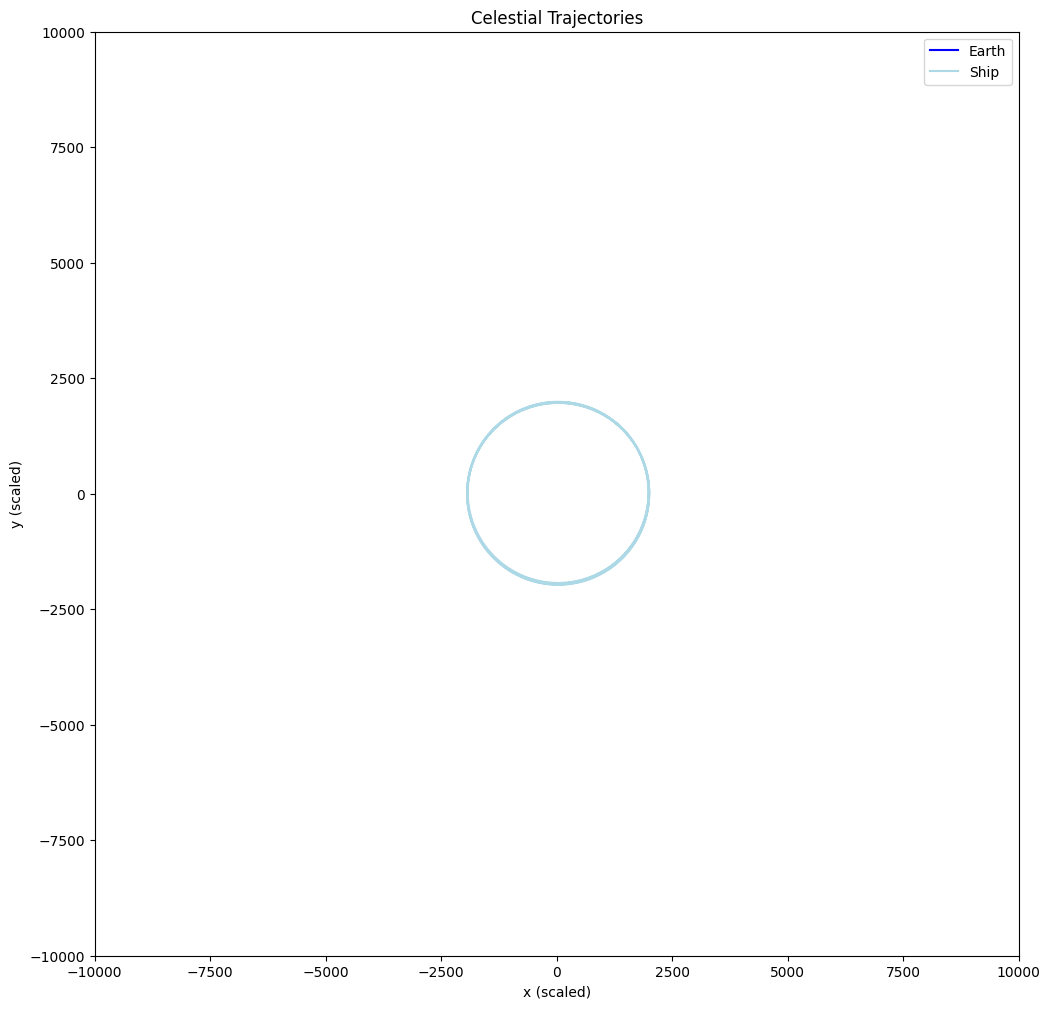

Episode  870 | Return:  2.115e+00 | Loss:  2.722e-01


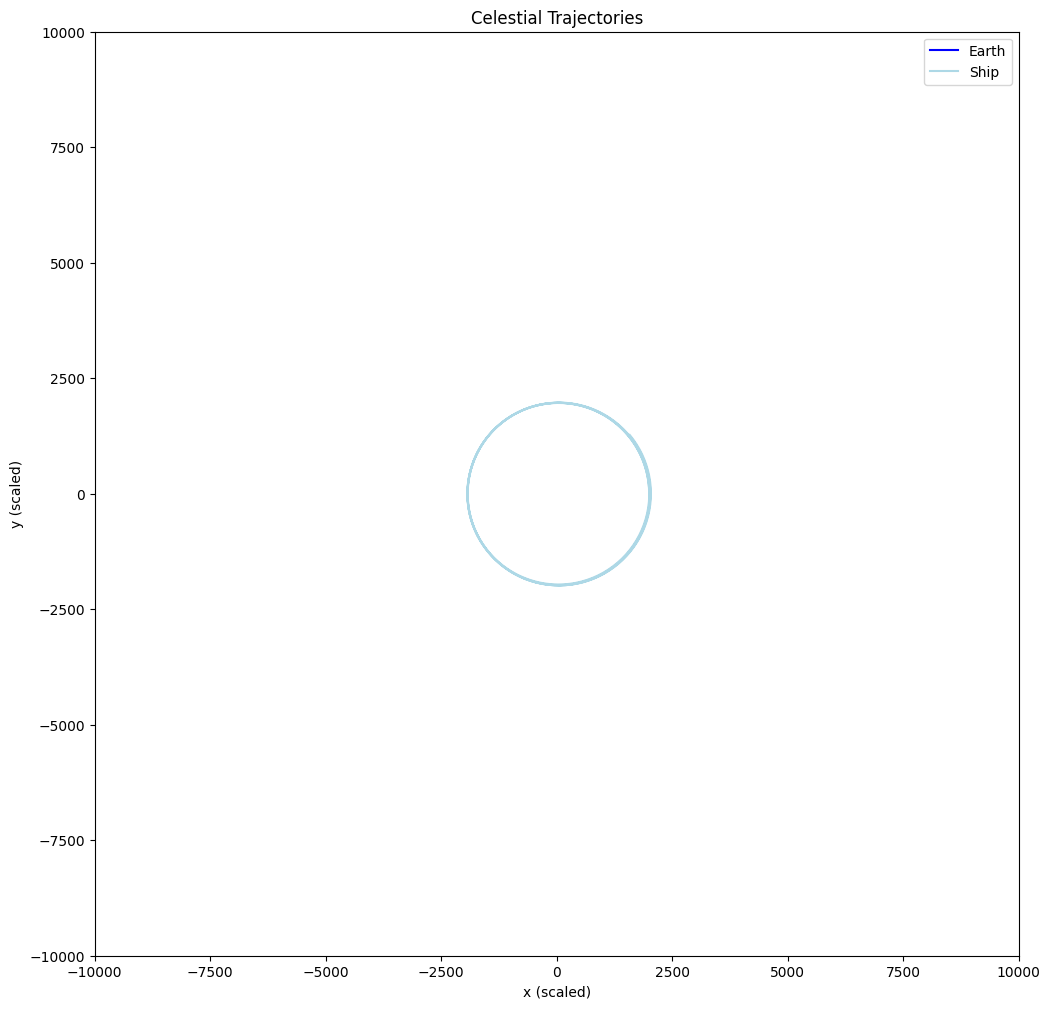

Episode  880 | Return:  2.111e+00 | Loss:  9.195e+00


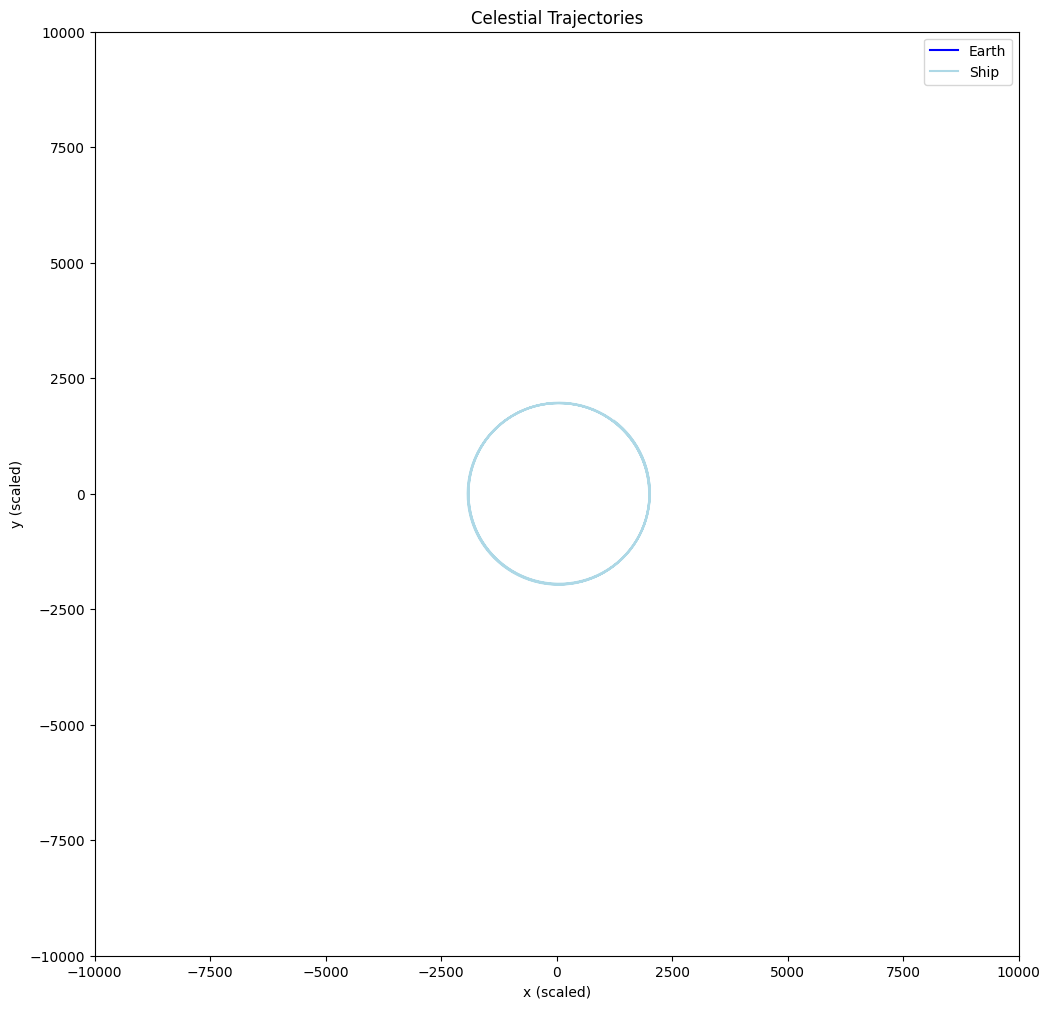

Episode  890 | Return:  2.111e+00 | Loss:  7.952e+00


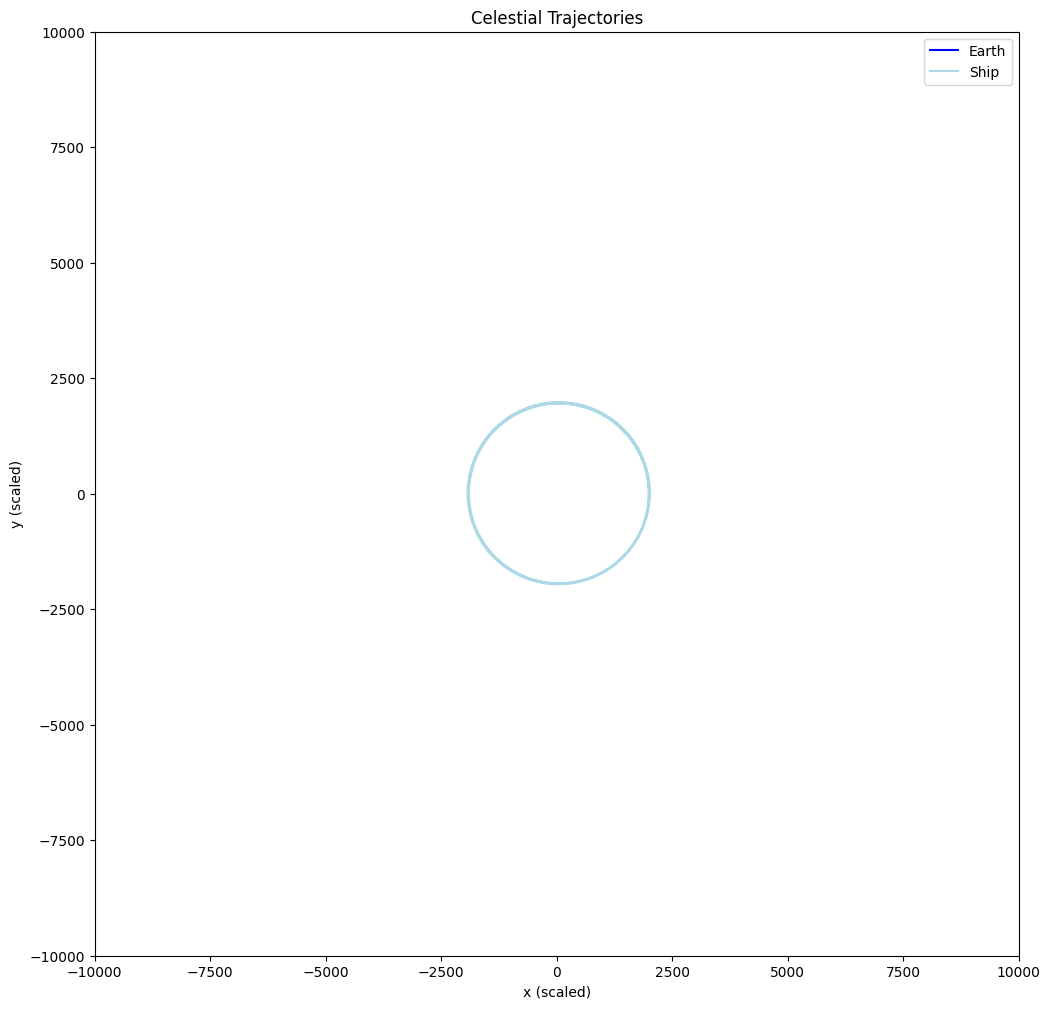

Episode  900 | Return:  2.115e+00 | Loss:  4.119e+00


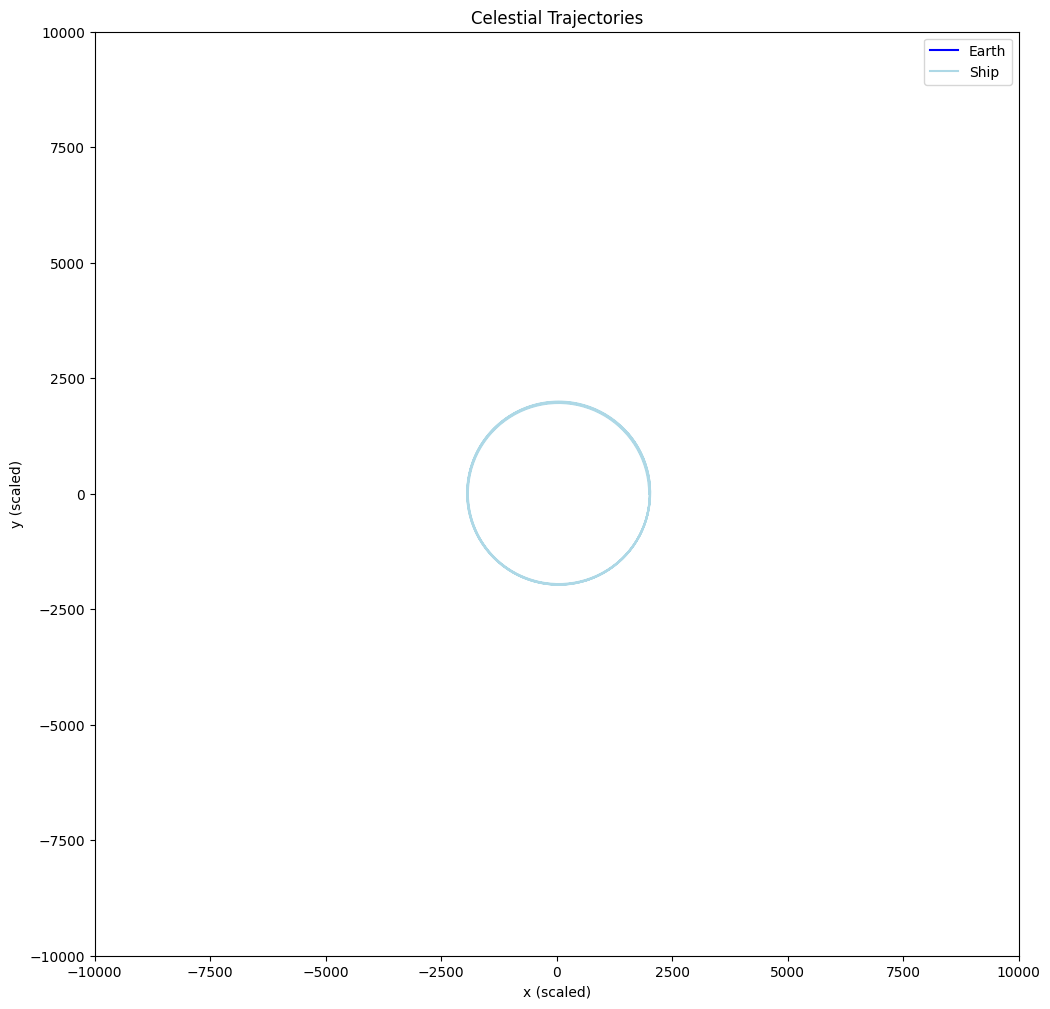

Episode  910 | Return:  2.116e+00 | Loss:  7.183e+00


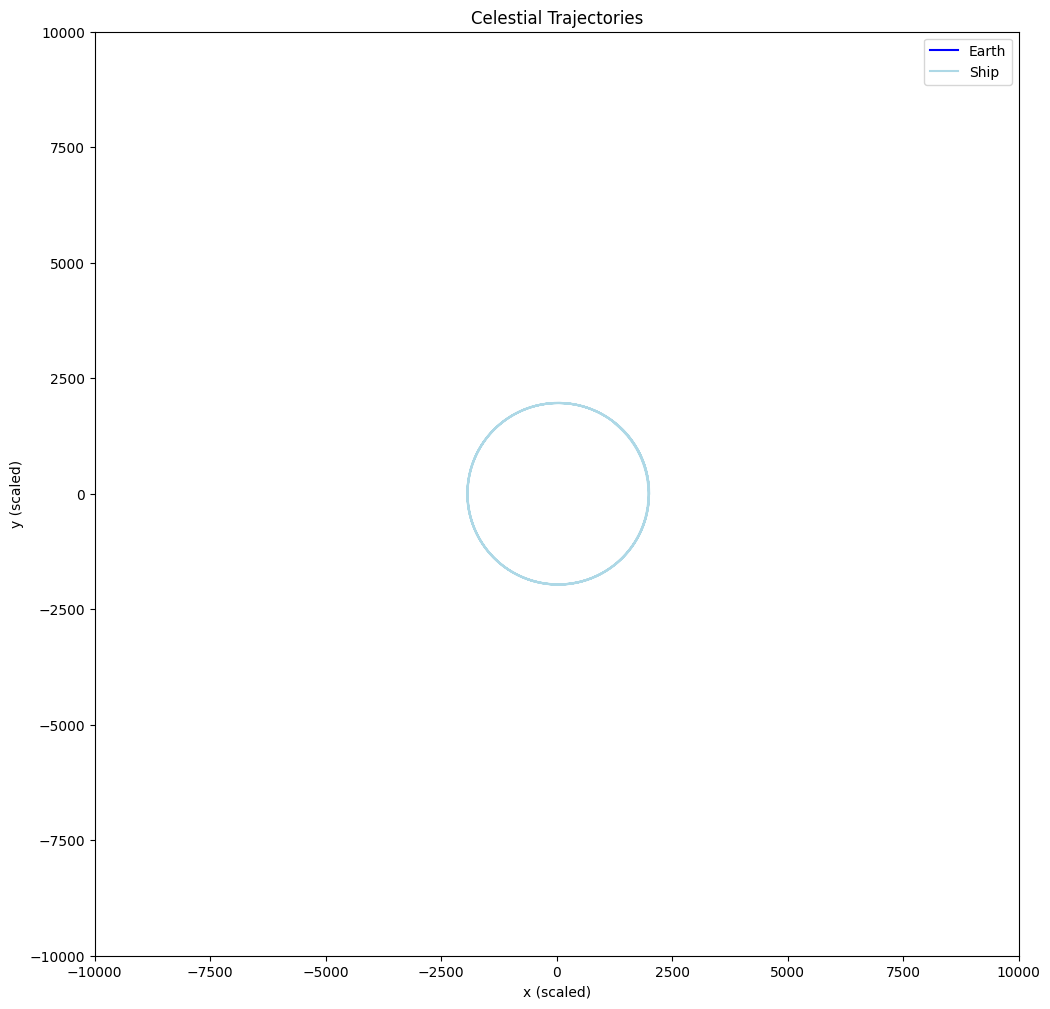

Episode  920 | Return:  2.115e+00 | Loss:  8.120e+00


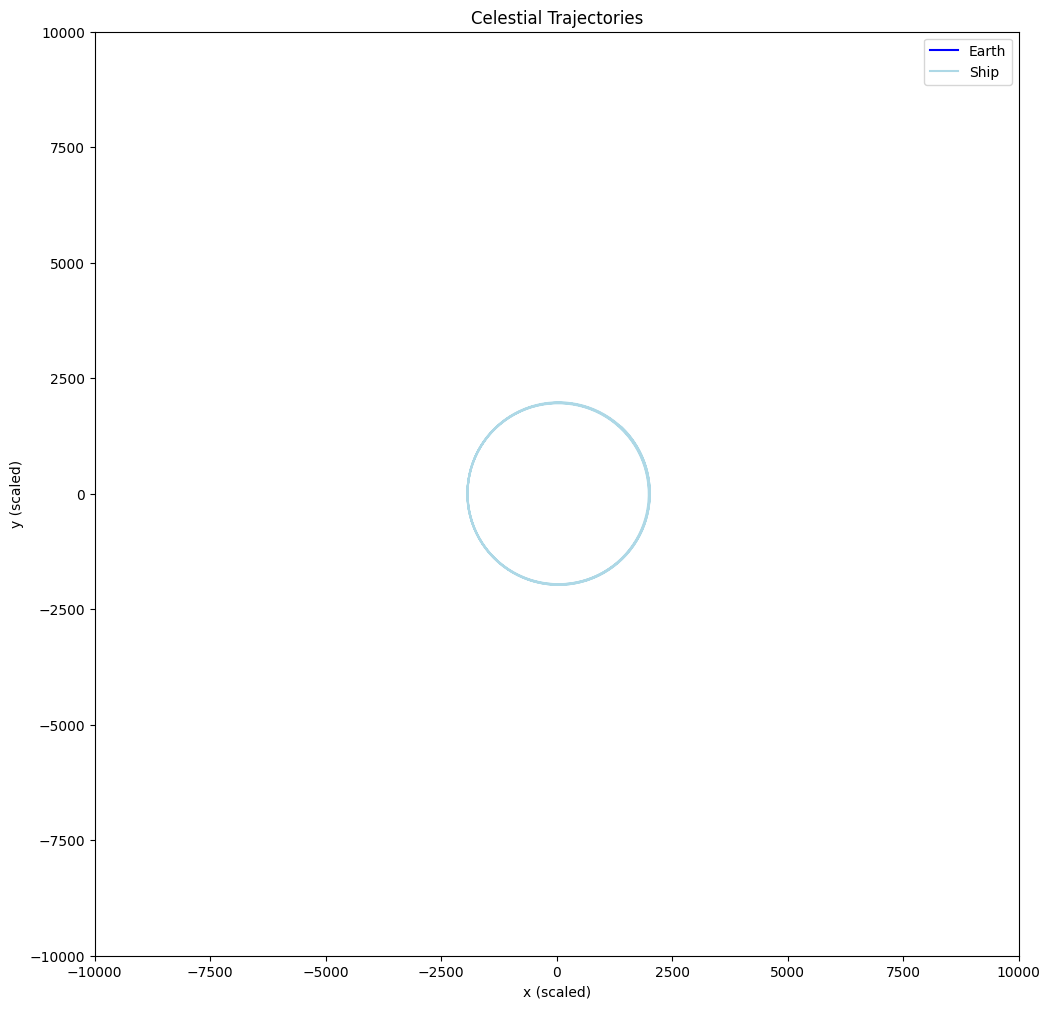

Episode  930 | Return:  2.116e+00 | Loss:  5.054e+00


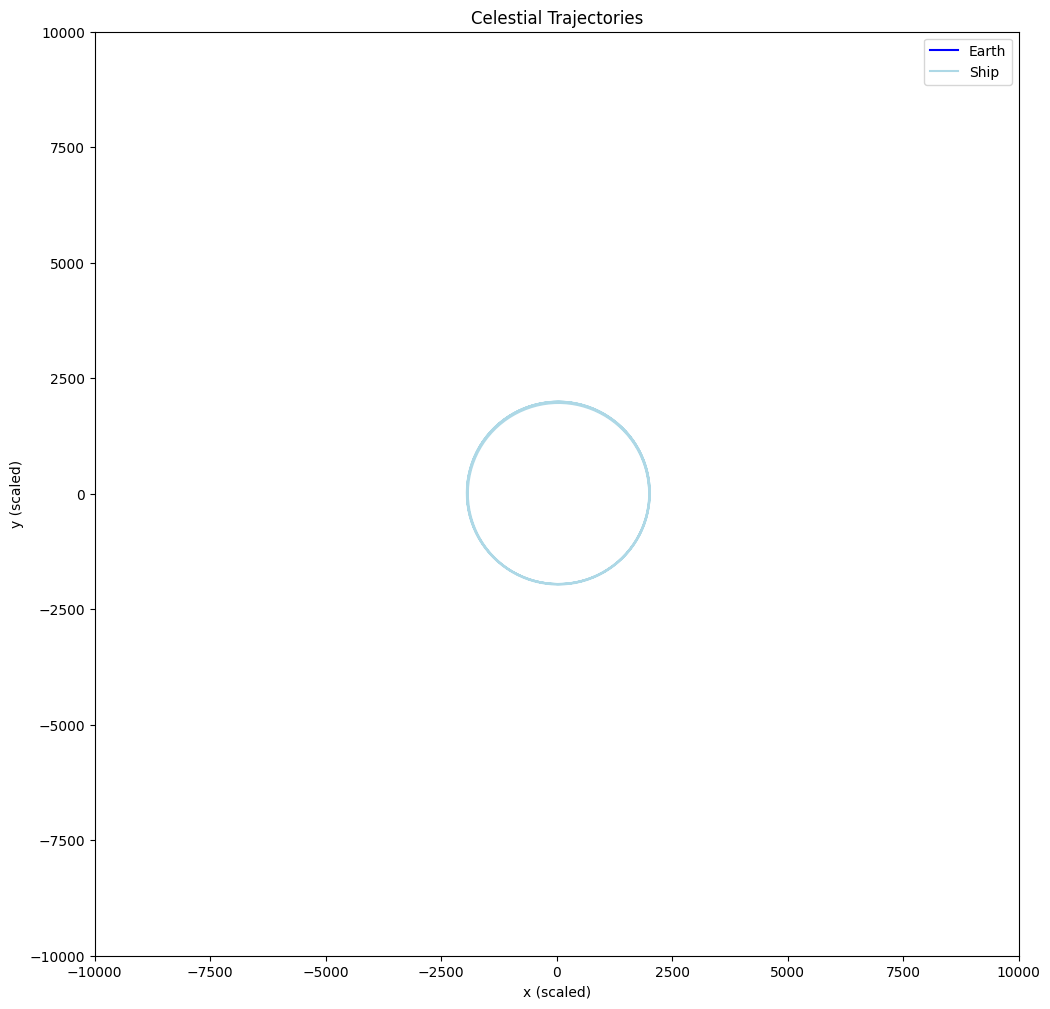

Episode  940 | Return:  2.115e+00 | Loss: -7.041e+01


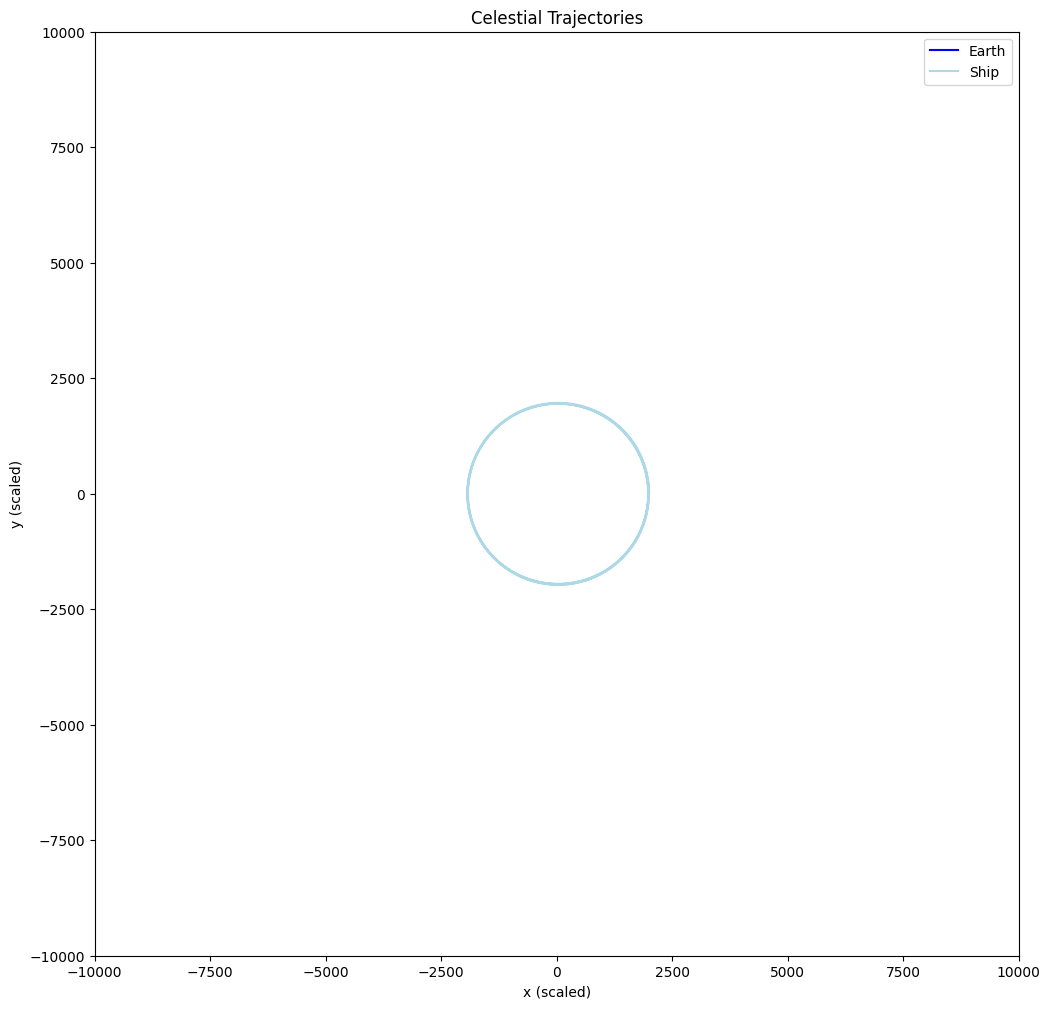

In [ ]:
ship = SimpleImpulseShip(ship_index=ship_index, mass=mass,thrust=thrust, actions=actions, safety_radius=safety_radius, escape_dist=escape_dist, escape_vel=escape_vel, target_dist=target_dist, target_vel=target_vel, reference_point_index=reference_point_index, reward_coef=reward_coef)

env = SolarSystemEnv(GravityForce, VelocityVerlet, bodies, ship=ship, dt=dt)

obs0 = env.reset()
obs_dim = obs0.shape[0]

agent = MonteCarloAgent(obs_dim, n_actions)

#lp = LineProfiler()
#lp.add_function(MonteCarloAgent.run_episode)
#lp.add_function(MonteCarloAgent.update_policy)

agent = MonteCarloAgent(obs_dim, n_actions)

#lp_wrapper = lp(train_mc)
#lp_wrapper(env, agent, n_episodes=10, max_steps=10000, log_every=20, log_states=False, log_n_entries=400)

#lp.print_stats()
states = train_mc(env, agent, n_episodes=n_episodes, max_steps=max_steps, log_every=10, log_states=True, log_n_entries=400)
#%lprun -f MonteCarloAgent.run_episode -f MonteCarloAgent.update_policy train_mc(env, agent, n_episodes=1, max_steps=1000, log_every=20, log_states=False, log_n_entries=400)

In [1]:
centre_body="Earth"
scale=1.0/1e3
xlim=(-1e4, 1e4)
ylim=(-1e4, 1e4)
xlabel="x [km]"
ylabel="y [km]"

for states_dict in states: 
    plot_static_trajectories(states=states_dict, body_names=bodies[3], colors=bodies[4], scale=scale, centre_body=centre_body, xlim=xlim, ylim=ylim, xlabel=xlabel, ylabel=ylabel)

NameError: name 'states' is not defined

In [2]:
save_states("Training_mc_02.json", states)

NameError: name 'save_states' is not defined

In [ ]:
#anim = visualize_trajectories(states=states, body_names=bodies[3], colors=bodies[4], interval=20, scale=scale, centre_body=centre_body, xlim=xlim, ylim=ylim, save_path="mcrl.gif")
#HTML(anim.to_jshtml())